In [2]:
# ============================================
# NEW FIRST CELL: Unified raw-unit evaluator + master rebuild
# ============================================

from pathlib import Path
import numpy as np
import pandas as pd

ROOT = Path("/data/Sajjan_Singh/spml/wavelet_seq_project")
TABLES_ROOT = ROOT / "results" / "tables"
PROCESSED_ROOT = ROOT / "data" / "processed"

def mse(y, yhat):
    y = np.asarray(y, dtype=np.float64)
    yhat = np.asarray(yhat, dtype=np.float64)
    return float(np.mean((y - yhat) ** 2))

def mae(y, yhat):
    y = np.asarray(y, dtype=np.float64)
    yhat = np.asarray(yhat, dtype=np.float64)
    return float(np.mean(np.abs(y - yhat)))

def rmse(y, yhat):
    return float(np.sqrt(mse(y, yhat)))

def load_target_scaler(dataset_name):
    npz_path = PROCESSED_ROOT / dataset_name / f"{dataset_name}_prepared.npz"
    arr = np.load(npz_path, allow_pickle=True)
    target_idx = int(arr["target_idx"][0])
    target_mean = float(arr["scaler_mean"][target_idx])
    target_std = float(arr["scaler_std"][target_idx])
    return target_mean, target_std

def metric_row_from_npz(dataset, model, family, seq_len, pred_len, pred_file_rel):
    p = ROOT / pred_file_rel
    arr = np.load(p, allow_pickle=True)
    preds = arr["preds"]
    trues = arr["trues"]

    preds = np.asarray(preds, dtype=np.float64).reshape(-1)
    trues = np.asarray(trues, dtype=np.float64).reshape(-1)

    return {
        "dataset": dataset,
        "model": model,
        "family": family,
        "seq_len": seq_len,
        "pred_len": pred_len,
        "test_mse": mse(trues, preds),
        "test_mae": mae(trues, preds),
        "test_rmse": rmse(trues, preds),
        "prediction_file": str(pred_file_rel),
    }

# A) Phase A first 6 models from saved raw prediction files
phase_a = pd.read_csv(TABLES_ROOT / "phaseA_all_datasets_metrics.csv")
phase_a_base = phase_a[phase_a["prediction_file"].notna()].copy()

phase_a_rows = []
for _, r in phase_a_base.iterrows():
    phase_a_rows.append(
        metric_row_from_npz(
            dataset=r["dataset"],
            model=r["model"],
            family=r["family"],
            seq_len=int(r["seq_len"]),
            pred_len=int(r["pred_len"]),
            pred_file_rel=r["prediction_file"],
        )
    )

# B) Phase A extra baselines: ARIMA/ETS and mLSTM
extra_registry_path = TABLES_ROOT / "phaseA_extra_prediction_registry.csv"
if extra_registry_path.exists():
    extra_registry = pd.read_csv(extra_registry_path)
    for _, r in extra_registry.iterrows():
        phase_a_rows.append(
            metric_row_from_npz(
                dataset=r["dataset"],
                model=r["model"],
                family=r["family"],
                seq_len=int(r["seq_len"]),
                pred_len=int(r["pred_len"]),
                pred_file_rel=r["prediction_file"],
            )
        )
else:
    print("WARNING: phaseA_extra_prediction_registry.csv not found")

phase_a_unified = pd.DataFrame(phase_a_rows)

# C) Phase B modern models: inverse-transform TSLib preds/trues to raw units
phase_b_path = TABLES_ROOT / "phaseB_tslib_modern_metrics.csv"
phase_b_rows = []

if phase_b_path.exists():
    phase_b = pd.read_csv(phase_b_path)
    usable = phase_b[phase_b["status"].astype(str).str.startswith(("ok_", "skipped_existing"))].copy()

    for _, r in usable.iterrows():
        pred_file = r.get("pred_file", None)
        true_file = r.get("true_file", None)

        if pd.isna(pred_file) or pd.isna(true_file):
            continue

        pred_arr = np.load(pred_file)
        true_arr = np.load(true_file)

        target_mean, target_std = load_target_scaler(r["dataset"])

        preds_raw = np.asarray(pred_arr, dtype=np.float64) * target_std + target_mean
        trues_raw = np.asarray(true_arr, dtype=np.float64) * target_std + target_mean

        phase_b_rows.append({
            "dataset": r["dataset"],
            "model": r["model"],
            "family": r["family"],
            "seq_len": int(r["seq_len"]),
            "pred_len": int(r["pred_len"]),
            "test_mse": mse(trues_raw.reshape(-1), preds_raw.reshape(-1)),
            "test_mae": mae(trues_raw.reshape(-1), preds_raw.reshape(-1)),
            "test_rmse": rmse(trues_raw.reshape(-1), preds_raw.reshape(-1)),
            "prediction_file": None,
        })

phase_b_unified = pd.DataFrame(phase_b_rows)
phase_b_unified.to_csv(TABLES_ROOT / "phaseB_tslib_modern_metrics_unified.csv", index=False)

# D) Phase 5 adaptive model from saved raw prediction files
phase5_registry_path = TABLES_ROOT / "phase5" / "phase5_prediction_registry.csv"
phase5_rows = []

if phase5_registry_path.exists():
    phase5_registry = pd.read_csv(phase5_registry_path)
    for _, r in phase5_registry.iterrows():
        phase5_rows.append(
            metric_row_from_npz(
                dataset=r["dataset"],
                model=r["model"],
                family=r["family"],
                seq_len=int(r["seq_len"]),
                pred_len=int(r["pred_len"]),
                pred_file_rel=r["prediction_file"],
            )
        )
else:
    print("WARNING: phase5_prediction_registry.csv not found")

phase5_unified = pd.DataFrame(phase5_rows)

# E) Merge into one unified master table
common_cols = ["dataset", "model", "family", "seq_len", "pred_len", "test_mse", "test_mae", "test_rmse", "prediction_file"]

all_parts = []
for part in [phase_a_unified, phase_b_unified, phase5_unified]:
    if len(part) > 0:
        for c in common_cols:
            if c not in part.columns:
                part[c] = None
        all_parts.append(part[common_cols])

master_unified = pd.concat(all_parts, ignore_index=True)
master_unified = master_unified.sort_values(["dataset", "family", "model"]).reset_index(drop=True)

master_unified_path = TABLES_ROOT / "master_all_models_metrics_unified.csv"
master_unified.to_csv(master_unified_path, index=False)

best_unified = (
    master_unified.sort_values(["dataset", "test_rmse", "test_mae", "test_mse"])
                  .groupby("dataset", as_index=False)
                  .first()[["dataset", "model", "family", "test_mse", "test_mae", "test_rmse"]]
)

best_unified_path = TABLES_ROOT / "master_best_by_dataset_unified.csv"
best_unified.to_csv(best_unified_path, index=False)

print("Saved:", master_unified_path)
print("Saved:", best_unified_path)
print("\nUnified master rows:", len(master_unified))
display(best_unified)

Saved: /data/Sajjan_Singh/spml/wavelet_seq_project/results/tables/master_all_models_metrics_unified.csv
Saved: /data/Sajjan_Singh/spml/wavelet_seq_project/results/tables/master_best_by_dataset_unified.csv

Unified master rows: 126


,dataset,model,family,test_mse,test_mae,test_rmse
0,electricity,WPMixer,modern_tslib,6.725901e+04,182.292991,259.343429
1,etth1,WPMixer,modern_tslib,4.691051e+00,1.635539,2.165884
2,etth2,dlinear,neural_non_wavelet,1.748497e+01,3.192522,4.181504
3,ettm1,WPMixer,modern_tslib,2.339102e+00,1.147820,1.529412
4,ettm2,WPMixer,modern_tslib,8.495447e+00,2.109087,2.914695
5,exchange,naive,classical,7.954944e-04,0.021018,0.028205
6,ili,iTransformer,modern_tslib,3.287862e+10,125665.623324,181324.636078
7,traffic,dlinear,neural_non_wavelet,4.471525e-05,0.003913,0.006687
8,weather,WPMixer,modern_tslib,1.728212e+02,10.047792,13.146148


In [3]:
# ============================================
# Cell 1: Setup, load data, create analysis folders
# ============================================

from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

ROOT = Path("/data/Sajjan_Singh/spml/wavelet_seq_project")

TABLES_ROOT = ROOT / "results" / "tables"
FIGURES_ROOT = ROOT / "results" / "figures" / "analysis"
ANALYSIS_TABLES = TABLES_ROOT / "analysis"
NOTES_ROOT = ROOT / "paper" / "notes"

FIGURES_ROOT.mkdir(parents=True, exist_ok=True)
ANALYSIS_TABLES.mkdir(parents=True, exist_ok=True)
NOTES_ROOT.mkdir(parents=True, exist_ok=True)

MASTER_CSV = TABLES_ROOT / "master_all_models_metrics_unified.csv"
MASTER_BEST_CSV = TABLES_ROOT / "master_best_by_dataset_unified.csv"
PHASE_B_CSV = TABLES_ROOT / "phaseB_tslib_modern_metrics.csv"
TIMEMIXER_OFFICIAL_CSV = TABLES_ROOT / "phaseB_timemixer_official_metrics.csv"

if not MASTER_CSV.exists():
    raise FileNotFoundError(f"Missing master CSV: {MASTER_CSV}")

df = pd.read_csv(MASTER_CSV)

# numeric cleanup
for col in ["test_mse", "test_mae", "test_rmse", "val_mse", "val_mae", "val_rmse", "params", "train_seconds"]:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors="coerce")

print("MASTER FILE:", MASTER_CSV)
print("ROWS:", len(df))
print("DATASETS:", sorted(df["dataset"].dropna().unique().tolist()))
print("MODELS:", sorted(df["model"].dropna().unique().tolist()))
print("FAMILIES:", sorted(df["family"].dropna().unique().tolist()))

display(df.head(10))

MASTER FILE: /data/Sajjan_Singh/spml/wavelet_seq_project/results/tables/master_all_models_metrics_unified.csv
ROWS: 126
DATASETS: ['electricity', 'etth1', 'etth2', 'ettm1', 'ettm2', 'exchange', 'ili', 'traffic', 'weather']
MODELS: ['ARIMA(1, 0, 0)', 'ARIMA(1, 1, 0)', 'ARIMA(2, 0, 0)', 'ARIMA(2, 1, 2)', 'AdaptiveWaveletMixer', 'Autoformer', 'ETS', 'FEDformer', 'TimesNet', 'WPMixer', 'dlinear', 'fixed_dwt_lstm', 'gru', 'iTransformer', 'lstm', 'mLSTM_reproduced', 'naive', 'seasonal_naive']
FAMILIES: ['classical', 'classical_univariate', 'modern_tslib', 'neural_non_wavelet', 'wavelet', 'wavelet_adaptive', 'wavelet_learnable']


,dataset,model,family,seq_len,pred_len,test_mse,test_mae,test_rmse,prediction_file
0,electricity,naive,classical,168,96,502720.727075,552.290455,709.028016,results/predictions/electricity/naive_test_pre...
1,electricity,seasonal_naive,classical,168,96,240502.782460,356.983977,490.410830,results/predictions/electricity/seasonal_naive...
2,electricity,"ARIMA(2, 1, 2)",classical_univariate,168,96,352654.265347,450.148408,593.847005,results/predictions/electricity/classical_univ...
3,electricity,Autoformer,modern_tslib,168,96,102367.743382,234.870040,319.949595,NaN
4,electricity,FEDformer,modern_tslib,168,96,119236.106722,262.581497,345.305816,NaN
5,electricity,TimesNet,modern_tslib,168,96,101960.012415,235.785430,319.311779,NaN
6,electricity,WPMixer,modern_tslib,168,96,67259.014354,182.292991,259.343429,NaN
7,electricity,iTransformer,modern_tslib,168,96,74347.200869,201.282026,272.666831,NaN
8,electricity,dlinear,neural_non_wavelet,168,96,73550.142342,191.765079,271.201295,results/predictions/electricity/dlinear_test_p...
9,electricity,gru,neural_non_wavelet,168,96,155883.938022,292.559933,394.821400,results/predictions/electricity/gru_test_predi...


In [4]:
# ============================================
# Cell 2: Enrich labels for analysis
# ============================================

analysis_df = df.copy()

def is_wavelet_model(model_name: str, family_name: str) -> bool:
    s1 = str(model_name).lower()
    s2 = str(family_name).lower()
    wavelet_keywords = ["wavelet", "wpmixer", "dwt", "mlstm"]
    return any(k in s1 for k in wavelet_keywords) or any(k in s2 for k in wavelet_keywords)

def broad_group(model_name: str, family_name: str) -> str:
    m = str(model_name).lower()
    f = str(family_name).lower()

    if "classical" in f or m in {"naive", "seasonal_naive"} or "arima" in m or "ets" in m:
        return "classical"
    if "modern" in f:
        return "modern"
    return "neural"

def wavelet_subgroup(model_name: str, family_name: str) -> str:
    m = str(model_name).lower()
    f = str(family_name).lower()

    if not is_wavelet_model(model_name, family_name):
        return "non_wavelet"

    if "fixed_dwt" in m or "fixed" in f:
        return "fixed_wavelet"
    if "mlstm" in m:
        return "learnable_wavelet"
    if "wpmixer" in m:
        return "wavelet_mixer"
    if "wavelet" in m or "wavelet" in f:
        return "wavelet_other"

    return "wavelet_other"

analysis_df["wavelet_flag"] = analysis_df.apply(lambda r: "wavelet" if is_wavelet_model(r["model"], r["family"]) else "non_wavelet", axis=1)
analysis_df["broad_group"] = analysis_df.apply(lambda r: broad_group(r["model"], r["family"]), axis=1)
analysis_df["wavelet_subgroup"] = analysis_df.apply(lambda r: wavelet_subgroup(r["model"], r["family"]), axis=1)

# dataset-wise rank (smaller rmse is better)
analysis_df["rank_in_dataset"] = (
    analysis_df.groupby("dataset")["test_rmse"]
               .rank(method="dense", ascending=True)
)

analysis_df = analysis_df.sort_values(["dataset", "rank_in_dataset", "test_rmse", "test_mae"]).reset_index(drop=True)

ENRICHED_CSV = ANALYSIS_TABLES / "analysis_enriched_master.csv"
analysis_df.to_csv(ENRICHED_CSV, index=False)

print("Saved:", ENRICHED_CSV)
print("\nWavelet flag counts:")
print(analysis_df["wavelet_flag"].value_counts().to_string())

print("\nBroad group counts:")
print(analysis_df["broad_group"].value_counts().to_string())

display(
    analysis_df[[
        "dataset", "model", "family", "broad_group",
        "wavelet_flag", "wavelet_subgroup",
        "test_mse", "test_mae", "test_rmse", "rank_in_dataset"
    ]].head(20)
)

Saved: /data/Sajjan_Singh/spml/wavelet_seq_project/results/tables/analysis/analysis_enriched_master.csv

Wavelet flag counts:
wavelet_flag
wavelet        63
non_wavelet    63

Broad group counts:
broad_group
neural       54
modern       45
classical    27


,dataset,model,family,broad_group,wavelet_flag,wavelet_subgroup,test_mse,test_mae,test_rmse,rank_in_dataset
0,electricity,WPMixer,modern_tslib,modern,wavelet,wavelet_mixer,67259.014354,182.292991,259.343429,1.0
1,electricity,dlinear,neural_non_wavelet,neural,wavelet,wavelet_other,73550.142342,191.765079,271.201295,2.0
2,electricity,iTransformer,modern_tslib,modern,non_wavelet,non_wavelet,74347.200869,201.282026,272.666831,3.0
3,electricity,TimesNet,modern_tslib,modern,non_wavelet,non_wavelet,101960.012415,235.785430,319.311779,4.0
4,electricity,Autoformer,modern_tslib,modern,non_wavelet,non_wavelet,102367.743382,234.870040,319.949595,5.0
5,electricity,FEDformer,modern_tslib,modern,non_wavelet,non_wavelet,119236.106722,262.581497,345.305816,6.0
6,electricity,AdaptiveWaveletMixer,wavelet_adaptive,neural,wavelet,wavelet_other,127045.919718,265.737704,356.435015,7.0
7,electricity,mLSTM_reproduced,wavelet_learnable,neural,wavelet,learnable_wavelet,143337.713337,280.085881,378.599674,8.0
8,electricity,lstm,neural_non_wavelet,neural,wavelet,wavelet_other,143367.100817,283.256661,378.638483,9.0
9,electricity,fixed_dwt_lstm,wavelet,neural,wavelet,fixed_wavelet,152383.608618,287.094545,390.363431,10.0


In [5]:
# ============================================
# Cell 3: Core tables for paper
# ============================================

# 1) best overall by dataset
best_by_dataset = (
    analysis_df.sort_values(["dataset", "test_rmse", "test_mae", "test_mse"])
               .groupby("dataset", as_index=False)
               .first()[[
                    "dataset", "model", "family", "broad_group",
                    "wavelet_flag", "wavelet_subgroup",
                    "test_mse", "test_mae", "test_rmse"
               ]]
)

# 2) best by dataset and broad group
best_by_dataset_group = (
    analysis_df.sort_values(["dataset", "broad_group", "test_rmse", "test_mae", "test_mse"])
               .groupby(["dataset", "broad_group"], as_index=False)
               .first()[[
                    "dataset", "broad_group", "model", "family",
                    "wavelet_flag", "test_mse", "test_mae", "test_rmse"
               ]]
)

# 3) win counts by model
model_win_counts = (
    best_by_dataset.groupby("model")
                   .size()
                   .reset_index(name="num_dataset_wins")
                   .sort_values(["num_dataset_wins", "model"], ascending=[False, True])
                   .reset_index(drop=True)
)

# 4) win counts by family
family_win_counts = (
    best_by_dataset.groupby("family")
                   .size()
                   .reset_index(name="num_dataset_wins")
                   .sort_values(["num_dataset_wins", "family"], ascending=[False, True])
                   .reset_index(drop=True)
)

# 5) win counts by broad group
broad_group_win_counts = (
    best_by_dataset.groupby("broad_group")
                   .size()
                   .reset_index(name="num_dataset_wins")
                   .sort_values(["num_dataset_wins", "broad_group"], ascending=[False, True])
                   .reset_index(drop=True)
)

# 6) average rank by model
average_rank_by_model = (
    analysis_df.groupby(["model", "family", "broad_group", "wavelet_flag"], as_index=False)["rank_in_dataset"]
               .mean()
               .rename(columns={"rank_in_dataset": "avg_rank"})
               .sort_values(["avg_rank", "model"])
               .reset_index(drop=True)
)

# 7) average rank by family
average_rank_by_family = (
    analysis_df.groupby(["family", "broad_group", "wavelet_flag"], as_index=False)["rank_in_dataset"]
               .mean()
               .rename(columns={"rank_in_dataset": "avg_rank"})
               .sort_values(["avg_rank", "family"])
               .reset_index(drop=True)
)

# 8) average metrics by broad group
avg_metrics_by_group = (
    analysis_df.groupby("broad_group", as_index=False)[["test_mse", "test_mae", "test_rmse"]]
               .mean()
               .sort_values("test_rmse")
               .reset_index(drop=True)
)

# 9) average metrics by wavelet flag
avg_metrics_by_wavelet = (
    analysis_df.groupby("wavelet_flag", as_index=False)[["test_mse", "test_mae", "test_rmse"]]
               .mean()
               .sort_values("test_rmse")
               .reset_index(drop=True)
)

# Save tables
best_by_dataset.to_csv(ANALYSIS_TABLES / "best_by_dataset.csv", index=False)
best_by_dataset_group.to_csv(ANALYSIS_TABLES / "best_by_dataset_and_group.csv", index=False)
model_win_counts.to_csv(ANALYSIS_TABLES / "model_win_counts.csv", index=False)
family_win_counts.to_csv(ANALYSIS_TABLES / "family_win_counts.csv", index=False)
broad_group_win_counts.to_csv(ANALYSIS_TABLES / "broad_group_win_counts.csv", index=False)
average_rank_by_model.to_csv(ANALYSIS_TABLES / "average_rank_by_model.csv", index=False)
average_rank_by_family.to_csv(ANALYSIS_TABLES / "average_rank_by_family.csv", index=False)
avg_metrics_by_group.to_csv(ANALYSIS_TABLES / "avg_metrics_by_broad_group.csv", index=False)
avg_metrics_by_wavelet.to_csv(ANALYSIS_TABLES / "avg_metrics_by_wavelet_flag.csv", index=False)

print("Saved analysis tables to:", ANALYSIS_TABLES)

print("\nBest overall by dataset:")
display(best_by_dataset)

print("\nModel win counts:")
display(model_win_counts)

print("\nFamily win counts:")
display(family_win_counts)

print("\nBroad group win counts:")
display(broad_group_win_counts)

print("\nAverage rank by model:")
display(average_rank_by_model.head(20))

print("\nAverage metrics by broad group:")
display(avg_metrics_by_group)

print("\nAverage metrics by wavelet flag:")
display(avg_metrics_by_wavelet)

Saved analysis tables to: /data/Sajjan_Singh/spml/wavelet_seq_project/results/tables/analysis

Best overall by dataset:


,dataset,model,family,broad_group,wavelet_flag,wavelet_subgroup,test_mse,test_mae,test_rmse
0,electricity,WPMixer,modern_tslib,modern,wavelet,wavelet_mixer,6.725901e+04,182.292991,259.343429
1,etth1,WPMixer,modern_tslib,modern,wavelet,wavelet_mixer,4.691051e+00,1.635539,2.165884
2,etth2,dlinear,neural_non_wavelet,neural,wavelet,wavelet_other,1.748497e+01,3.192522,4.181504
3,ettm1,WPMixer,modern_tslib,modern,wavelet,wavelet_mixer,2.339102e+00,1.147820,1.529412
4,ettm2,WPMixer,modern_tslib,modern,wavelet,wavelet_mixer,8.495447e+00,2.109087,2.914695
5,exchange,naive,classical,classical,non_wavelet,non_wavelet,7.954944e-04,0.021018,0.028205
6,ili,iTransformer,modern_tslib,modern,non_wavelet,non_wavelet,3.287862e+10,125665.623324,181324.636078
7,traffic,dlinear,neural_non_wavelet,neural,wavelet,wavelet_other,4.471525e-05,0.003913,0.006687
8,weather,WPMixer,modern_tslib,modern,wavelet,wavelet_mixer,1.728212e+02,10.047792,13.146148



Model win counts:


,model,num_dataset_wins
0,WPMixer,5
1,dlinear,2
2,iTransformer,1
3,naive,1



Family win counts:


...

,model,family,broad_group,wavelet_flag,avg_rank
0,WPMixer,modern_tslib,modern,wavelet,1.888889
1,iTransformer,modern_tslib,modern,non_wavelet,2.888889
2,dlinear,neural_non_wavelet,neural,wavelet,3.555556
3,TimesNet,modern_tslib,modern,non_wavelet,3.777778
4,seasonal_naive,classical,classical,non_wavelet,6.555556
5,FEDformer,modern_tslib,modern,non_wavelet,6.777778
6,naive,classical,classical,non_wavelet,7.222222
7,Autoformer,modern_tslib,modern,non_wavelet,7.555556
8,mLSTM_reproduced,wavelet_learnable,neural,wavelet,9.888889
9,lstm,neural_non_wavelet,neural,wavelet,10.222222



Average metrics by broad group:


,broad_group,test_mse,test_mae,test_rmse
0,modern,4.333026e+09,17607.946281,21908.844948
1,classical,1.024154e+10,27839.279151,33001.693321
2,neural,1.965271e+10,38985.321885,45525.226758



Average metrics by wavelet flag:


,wavelet_flag,test_mse,test_mae,test_rmse
0,non_wavelet,6.921183e+09,22028.820547,26798.690373
1,wavelet,1.740825e+10,35895.393763,42015.690378


In [6]:
# ============================================
# Cell 4: Wavelet vs non-wavelet comparison
# ============================================

wavelet_best = (
    analysis_df[analysis_df["wavelet_flag"] == "wavelet"]
    .sort_values(["dataset", "test_rmse", "test_mae", "test_mse"])
    .groupby("dataset", as_index=False)
    .first()[["dataset", "model", "family", "test_mse", "test_mae", "test_rmse"]]
    .rename(columns={
        "model": "best_wavelet_model",
        "family": "best_wavelet_family",
        "test_mse": "wavelet_mse",
        "test_mae": "wavelet_mae",
        "test_rmse": "wavelet_rmse",
    })
)

nonwavelet_best = (
    analysis_df[analysis_df["wavelet_flag"] == "non_wavelet"]
    .sort_values(["dataset", "test_rmse", "test_mae", "test_mse"])
    .groupby("dataset", as_index=False)
    .first()[["dataset", "model", "family", "test_mse", "test_mae", "test_rmse"]]
    .rename(columns={
        "model": "best_nonwavelet_model",
        "family": "best_nonwavelet_family",
        "test_mse": "nonwavelet_mse",
        "test_mae": "nonwavelet_mae",
        "test_rmse": "nonwavelet_rmse",
    })
)

wavelet_vs_nonwavelet = pd.merge(wavelet_best, nonwavelet_best, on="dataset", how="outer")

wavelet_vs_nonwavelet["rmse_delta_nonwavelet_minus_wavelet"] = (
    wavelet_vs_nonwavelet["nonwavelet_rmse"] - wavelet_vs_nonwavelet["wavelet_rmse"]
)
wavelet_vs_nonwavelet["mae_delta_nonwavelet_minus_wavelet"] = (
    wavelet_vs_nonwavelet["nonwavelet_mae"] - wavelet_vs_nonwavelet["wavelet_mae"]
)
wavelet_vs_nonwavelet["mse_delta_nonwavelet_minus_wavelet"] = (
    wavelet_vs_nonwavelet["nonwavelet_mse"] - wavelet_vs_nonwavelet["wavelet_mse"]
)

wavelet_vs_nonwavelet["wavelet_better"] = wavelet_vs_nonwavelet["rmse_delta_nonwavelet_minus_wavelet"] > 0

wavelet_vs_nonwavelet.to_csv(ANALYSIS_TABLES / "wavelet_vs_nonwavelet_by_dataset.csv", index=False)

print("Saved:", ANALYSIS_TABLES / "wavelet_vs_nonwavelet_by_dataset.csv")
display(wavelet_vs_nonwavelet)

wavelet_win_count = int(wavelet_vs_nonwavelet["wavelet_better"].sum())
total_compared = int(len(wavelet_vs_nonwavelet))
print(f"\nWavelet best beats non-wavelet best on {wavelet_win_count}/{total_compared} datasets.")

Saved: /data/Sajjan_Singh/spml/wavelet_seq_project/results/tables/analysis/wavelet_vs_nonwavelet_by_dataset.csv


,dataset,best_wavelet_model,best_wavelet_family,wavelet_mse,wavelet_mae,wavelet_rmse,best_nonwavelet_model,best_nonwavelet_family,nonwavelet_mse,nonwavelet_mae,nonwavelet_rmse,rmse_delta_nonwavelet_minus_wavelet,mae_delta_nonwavelet_minus_wavelet,mse_delta_nonwavelet_minus_wavelet,wavelet_better
0,electricity,WPMixer,modern_tslib,6.725901e+04,182.292991,259.343429,iTransformer,modern_tslib,7.434720e+04,201.282026,272.666831,13.323402,18.989035,7.088187e+03,True
1,etth1,WPMixer,modern_tslib,4.691051e+00,1.635539,2.165884,iTransformer,modern_tslib,4.941581e+00,1.705107,2.222967,0.057083,0.069568,2.505293e-01,True
2,etth2,dlinear,neural_non_wavelet,1.748497e+01,3.192522,4.181504,FEDformer,modern_tslib,1.786463e+01,3.259992,4.226657,0.045153,0.067470,3.796571e-01,True
3,ettm1,WPMixer,modern_tslib,2.339102e+00,1.147820,1.529412,iTransformer,modern_tslib,2.643387e+00,1.222460,1.625850,0.096437,0.074640,3.042851e-01,True
4,ettm2,WPMixer,modern_tslib,8.495447e+00,2.109087,2.914695,iTransformer,modern_tslib,9.708962e+00,2.299730,3.115921,0.201226,0.190643,1.213515e+00,True
5,exchange,WPMixer,modern_tslib,8.811419e-04,0.021689,0.029684,naive,classical,7.954944e-04,0.021018,0.028205,-0.001480,-0.000671,-8.564752e-05,False
6,ili,WPMixer,modern_tslib,3.547304e+10,156001.911326,188342.888114,iTransformer,modern_tslib,3.287862e+10,125665.623324,181324.636078,-7018.252037,-30336.288002,-2.594420e+09,False
7,traffic,dlinear,neural_non_wavelet,4.471525e-05,0.003913,0.006687,iTransformer,modern_tslib,4.779969e-05,0.004236,0.006914,0.000227,0.000323,3.084434e-06,True
8,weather,WPMixer,modern_tslib,1.728212e+02,10.047792,13.146148,naive,classical,1.832375e+02,9.531391,13.536526,0.390378,-0.516401,1.041634e+01,True



Wavelet best beats non-wavelet best on 7/9 datasets.


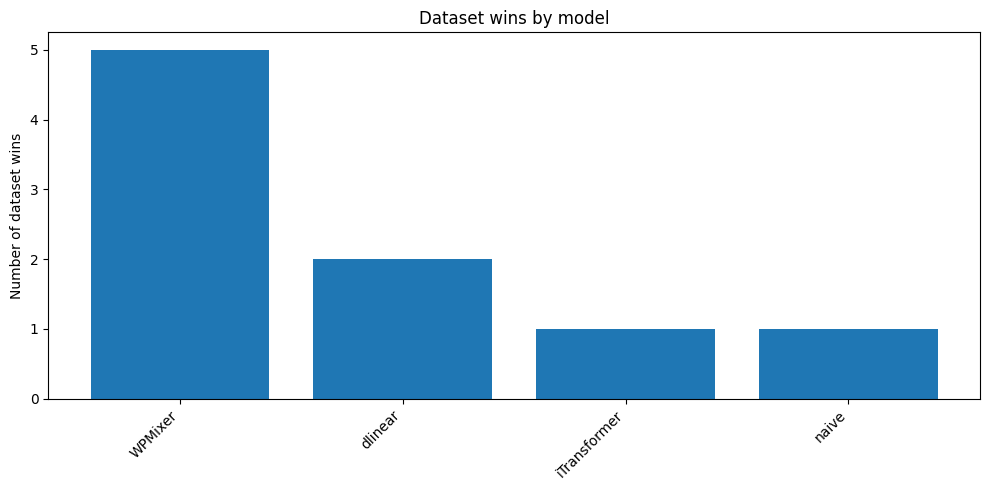

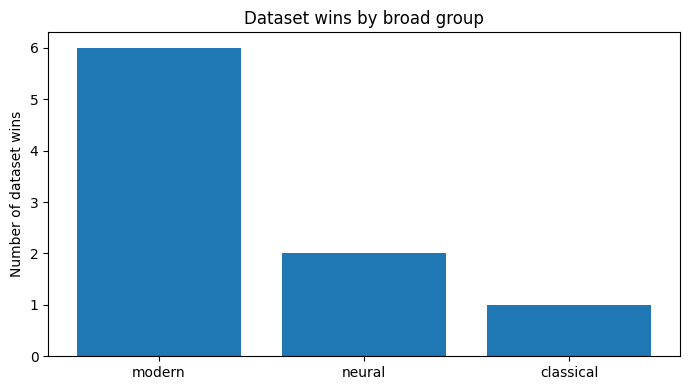

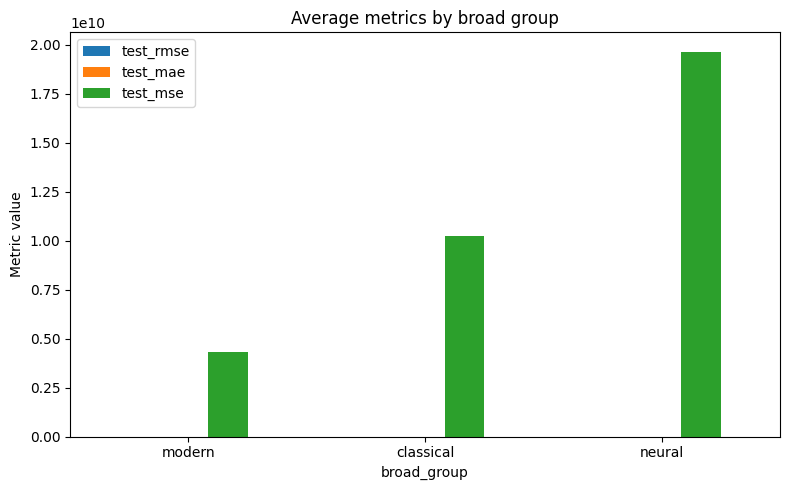

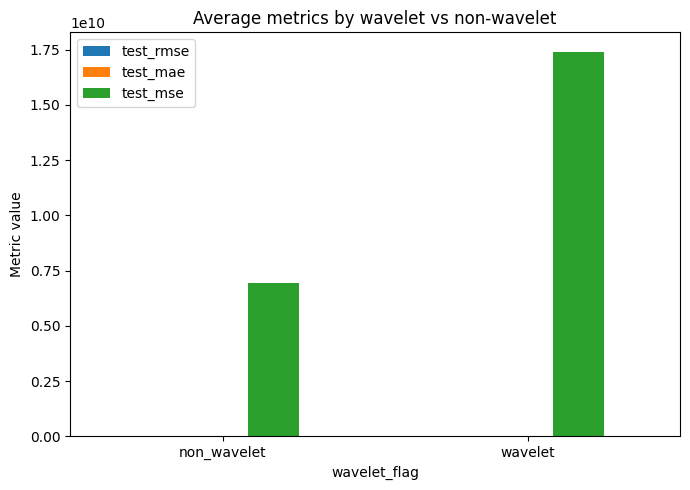

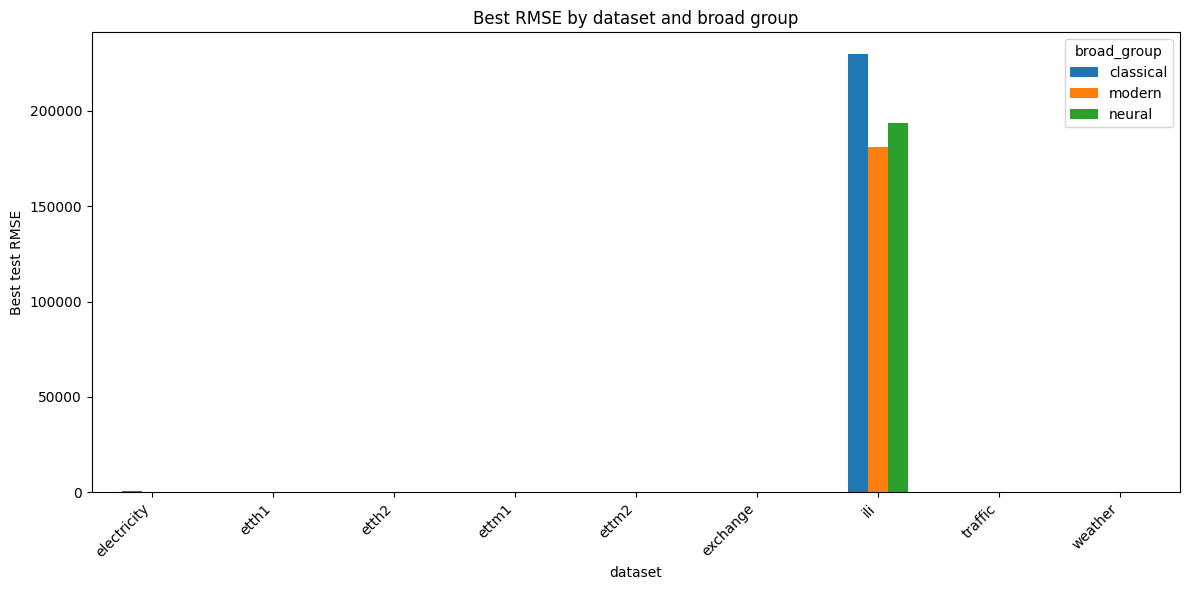

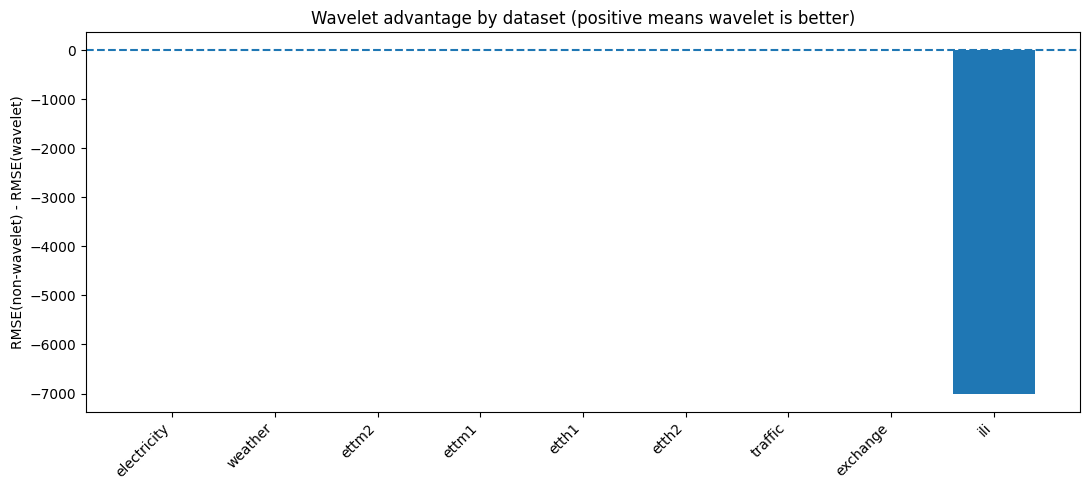

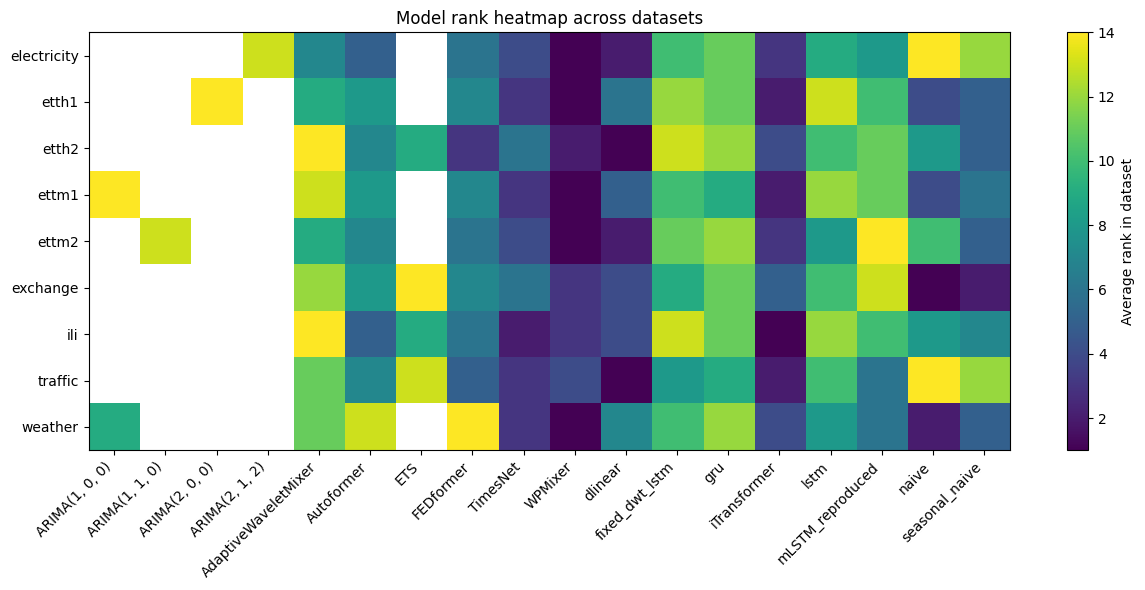

Saved figures to: /data/Sajjan_Singh/spml/wavelet_seq_project/results/figures/analysis


In [7]:
# ============================================
# Cell 5: Paper-ready plots
# ============================================

# 1) wins by model
plt.figure(figsize=(10, 5))
plt.bar(model_win_counts["model"], model_win_counts["num_dataset_wins"])
plt.xticks(rotation=45, ha="right")
plt.ylabel("Number of dataset wins")
plt.title("Dataset wins by model")
plt.tight_layout()
plt.savefig(FIGURES_ROOT / "wins_by_model.png", dpi=200, bbox_inches="tight")
plt.show()

# 2) wins by broad group
plt.figure(figsize=(7, 4))
plt.bar(broad_group_win_counts["broad_group"], broad_group_win_counts["num_dataset_wins"])
plt.ylabel("Number of dataset wins")
plt.title("Dataset wins by broad group")
plt.tight_layout()
plt.savefig(FIGURES_ROOT / "wins_by_broad_group.png", dpi=200, bbox_inches="tight")
plt.show()

# 3) average metrics by broad group
group_plot = avg_metrics_by_group.set_index("broad_group")[["test_rmse", "test_mae", "test_mse"]]
ax = group_plot.plot(kind="bar", figsize=(8, 5))
ax.set_title("Average metrics by broad group")
ax.set_ylabel("Metric value")
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig(FIGURES_ROOT / "avg_metrics_by_broad_group.png", dpi=200, bbox_inches="tight")
plt.show()

# 4) average metrics by wavelet flag
wavelet_plot = avg_metrics_by_wavelet.set_index("wavelet_flag")[["test_rmse", "test_mae", "test_mse"]]
ax = wavelet_plot.plot(kind="bar", figsize=(7, 5))
ax.set_title("Average metrics by wavelet vs non-wavelet")
ax.set_ylabel("Metric value")
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig(FIGURES_ROOT / "avg_metrics_by_wavelet_flag.png", dpi=200, bbox_inches="tight")
plt.show()

# 5) best rmse by dataset and broad group
pivot_group = best_by_dataset_group.pivot(index="dataset", columns="broad_group", values="test_rmse")
ax = pivot_group.plot(kind="bar", figsize=(12, 6))
ax.set_title("Best RMSE by dataset and broad group")
ax.set_ylabel("Best test RMSE")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.savefig(FIGURES_ROOT / "best_rmse_by_dataset_and_broad_group.png", dpi=200, bbox_inches="tight")
plt.show()

# 6) wavelet vs non-wavelet rmse delta (positive -> wavelet better)
wavelet_delta = wavelet_vs_nonwavelet.sort_values("rmse_delta_nonwavelet_minus_wavelet", ascending=False)
plt.figure(figsize=(11, 5))
plt.bar(
    wavelet_delta["dataset"],
    wavelet_delta["rmse_delta_nonwavelet_minus_wavelet"]
)
plt.axhline(0.0, linestyle="--")
plt.xticks(rotation=45, ha="right")
plt.ylabel("RMSE(non-wavelet) - RMSE(wavelet)")
plt.title("Wavelet advantage by dataset (positive means wavelet is better)")
plt.tight_layout()
plt.savefig(FIGURES_ROOT / "wavelet_vs_nonwavelet_rmse_delta.png", dpi=200, bbox_inches="tight")
plt.show()

# 7) heatmap of ranks: dataset x model
rank_pivot = (
    analysis_df.pivot_table(index="dataset", columns="model", values="rank_in_dataset", aggfunc="mean")
    .sort_index()
)

plt.figure(figsize=(max(12, len(rank_pivot.columns) * 0.7), 6))
im = plt.imshow(rank_pivot.values, aspect="auto")
plt.colorbar(im, label="Average rank in dataset")
plt.xticks(np.arange(rank_pivot.shape[1]), rank_pivot.columns, rotation=45, ha="right")
plt.yticks(np.arange(rank_pivot.shape[0]), rank_pivot.index)
plt.title("Model rank heatmap across datasets")
plt.tight_layout()
plt.savefig(FIGURES_ROOT / "model_rank_heatmap.png", dpi=200, bbox_inches="tight")
plt.show()

print("Saved figures to:", FIGURES_ROOT)

In [8]:
# ============================================
# Cell 6: Best-by-dataset discussion tables
# ============================================

# Best wavelet model by dataset
best_wavelet_by_dataset = (
    analysis_df[analysis_df["wavelet_flag"] == "wavelet"]
    .sort_values(["dataset", "test_rmse", "test_mae", "test_mse"])
    .groupby("dataset", as_index=False)
    .first()[[
        "dataset", "model", "family", "wavelet_subgroup",
        "test_mse", "test_mae", "test_rmse"
    ]]
)

# Best non-wavelet model by dataset
best_nonwavelet_by_dataset = (
    analysis_df[analysis_df["wavelet_flag"] == "non_wavelet"]
    .sort_values(["dataset", "test_rmse", "test_mae", "test_mse"])
    .groupby("dataset", as_index=False)
    .first()[[
        "dataset", "model", "family",
        "test_mse", "test_mae", "test_rmse"
    ]]
)

best_wavelet_by_dataset.to_csv(ANALYSIS_TABLES / "best_wavelet_by_dataset.csv", index=False)
best_nonwavelet_by_dataset.to_csv(ANALYSIS_TABLES / "best_nonwavelet_by_dataset.csv", index=False)

print("Saved:")
print(ANALYSIS_TABLES / "best_wavelet_by_dataset.csv")
print(ANALYSIS_TABLES / "best_nonwavelet_by_dataset.csv")

print("\nBest wavelet model by dataset:")
display(best_wavelet_by_dataset)

print("\nBest non-wavelet model by dataset:")
display(best_nonwavelet_by_dataset)

Saved:
/data/Sajjan_Singh/spml/wavelet_seq_project/results/tables/analysis/best_wavelet_by_dataset.csv
/data/Sajjan_Singh/spml/wavelet_seq_project/results/tables/analysis/best_nonwavelet_by_dataset.csv

Best wavelet model by dataset:


,dataset,model,family,wavelet_subgroup,test_mse,test_mae,test_rmse
0,electricity,WPMixer,modern_tslib,wavelet_mixer,6.725901e+04,182.292991,259.343429
1,etth1,WPMixer,modern_tslib,wavelet_mixer,4.691051e+00,1.635539,2.165884
2,etth2,dlinear,neural_non_wavelet,wavelet_other,1.748497e+01,3.192522,4.181504
3,ettm1,WPMixer,modern_tslib,wavelet_mixer,2.339102e+00,1.147820,1.529412
4,ettm2,WPMixer,modern_tslib,wavelet_mixer,8.495447e+00,2.109087,2.914695
5,exchange,WPMixer,modern_tslib,wavelet_mixer,8.811419e-04,0.021689,0.029684
6,ili,WPMixer,modern_tslib,wavelet_mixer,3.547304e+10,156001.911326,188342.888114
7,traffic,dlinear,neural_non_wavelet,wavelet_other,4.471525e-05,0.003913,0.006687
8,weather,WPMixer,modern_tslib,wavelet_mixer,1.728212e+02,10.047792,13.146148



Best non-wavelet model by dataset:


,dataset,model,family,test_mse,test_mae,test_rmse
0,electricity,iTransformer,modern_tslib,7.434720e+04,201.282026,272.666831
1,etth1,iTransformer,modern_tslib,4.941581e+00,1.705107,2.222967
2,etth2,FEDformer,modern_tslib,1.786463e+01,3.259992,4.226657
3,ettm1,iTransformer,modern_tslib,2.643387e+00,1.222460,1.625850
4,ettm2,iTransformer,modern_tslib,9.708962e+00,2.299730,3.115921
5,exchange,naive,classical,7.954944e-04,0.021018,0.028205
6,ili,iTransformer,modern_tslib,3.287862e+10,125665.623324,181324.636078
7,traffic,iTransformer,modern_tslib,4.779969e-05,0.004236,0.006914
8,weather,naive,classical,1.832375e+02,9.531391,13.536526


In [9]:
# ============================================
# Cell 7: Exclusion / failure notes for the paper
# ============================================

notes = []

if PHASE_B_CSV.exists():
    phase_b_df = pd.read_csv(PHASE_B_CSV)
    if "status" in phase_b_df.columns:
        excluded = phase_b_df[phase_b_df["status"].astype(str).str.contains("excluded|failed", case=False, na=False)].copy()
        if len(excluded) > 0:
            notes.append("Modern benchmark exclusions / failures:")
            for _, r in excluded[["dataset", "model", "status"]].drop_duplicates().iterrows():
                notes.append(f"- {r['dataset']} | {r['model']} | {r['status']}")

if TIMEMIXER_OFFICIAL_CSV.exists():
    tm_df = pd.read_csv(TIMEMIXER_OFFICIAL_CSV)
    if "status" in tm_df.columns:
        tm_fail = tm_df[tm_df["status"].astype(str).str.contains("failed", case=False, na=False)].copy()
        if len(tm_fail) > 0:
            notes.append("")
            notes.append("Official TimeMixer retry failures:")
            for _, r in tm_fail[["dataset", "model", "status"]].drop_duplicates().iterrows():
                notes.append(f"- {r['dataset']} | {r['model']} | {r['status']}")

exclusion_note_path = NOTES_ROOT / "benchmark_exclusion_notes.md"
exclusion_note_path.write_text("\n".join(notes) if notes else "No exclusions/failures recorded.")
print("Saved:", exclusion_note_path)

print("\n".join(notes) if notes else "No exclusions/failures recorded.")

Saved: /data/Sajjan_Singh/spml/wavelet_seq_project/paper/notes/benchmark_exclusion_notes.md
Modern benchmark exclusions / failures:
- electricity | TimeMixer | excluded_incompatible_MS_protocol
- etth1 | TimeMixer | excluded_incompatible_MS_protocol
- etth2 | TimeMixer | excluded_incompatible_MS_protocol
- ettm1 | TimeMixer | excluded_incompatible_MS_protocol
- ettm2 | TimeMixer | excluded_incompatible_MS_protocol
- exchange | TimeMixer | excluded_incompatible_MS_protocol
- ili | TimeMixer | excluded_incompatible_MS_protocol
- traffic | TimeMixer | excluded_incompatible_MS_protocol
- weather | TimeMixer | excluded_incompatible_MS_protocol

Official TimeMixer retry failures:
- etth1 | TimeMixerOfficial | failed_returncode_1
- etth2 | TimeMixerOfficial | failed_returncode_1
- ettm1 | TimeMixerOfficial | failed_returncode_1
- ettm2 | TimeMixerOfficial | failed_returncode_1
- weather | TimeMixerOfficial | failed_returncode_1
- electricity | TimeMixerOfficial | failed_returncode_1
- traffic

In [10]:
# ============================================
# Cell 8: Auto-generate paper discussion summary
# ============================================

top_model = model_win_counts.iloc[0]["model"] if len(model_win_counts) > 0 else "N/A"
top_model_wins = int(model_win_counts.iloc[0]["num_dataset_wins"]) if len(model_win_counts) > 0 else 0

top_family = family_win_counts.iloc[0]["family"] if len(family_win_counts) > 0 else "N/A"
top_family_wins = int(family_win_counts.iloc[0]["num_dataset_wins"]) if len(family_win_counts) > 0 else 0

top_group = broad_group_win_counts.iloc[0]["broad_group"] if len(broad_group_win_counts) > 0 else "N/A"
top_group_wins = int(broad_group_win_counts.iloc[0]["num_dataset_wins"]) if len(broad_group_win_counts) > 0 else 0

wavelet_group_metrics = avg_metrics_by_wavelet.set_index("wavelet_flag")
wavelet_summary = ""
if {"wavelet", "non_wavelet"}.issubset(set(wavelet_group_metrics.index)):
    wavelet_rmse = float(wavelet_group_metrics.loc["wavelet", "test_rmse"])
    nonwavelet_rmse = float(wavelet_group_metrics.loc["non_wavelet", "test_rmse"])
    delta = nonwavelet_rmse - wavelet_rmse
    if delta > 0:
        wavelet_summary = f"On average, wavelet models outperform non-wavelet models by {delta:.6f} RMSE."
    else:
        wavelet_summary = f"On average, non-wavelet models outperform wavelet models by {abs(delta):.6f} RMSE."
else:
    wavelet_summary = "Wavelet vs non-wavelet average comparison could not be computed."

best_lines = []
for _, r in best_by_dataset.iterrows():
    best_lines.append(
        f"- {r['dataset']}: {r['model']} ({r['family']}) | "
        f"RMSE={r['test_rmse']:.6f}, MAE={r['test_mae']:.6f}, MSE={r['test_mse']:.6f}"
    )

summary_text = f"""# Benchmark Analysis Summary

## Overall benchmark status
- Analysis source: `{MASTER_CSV}`
- Total evaluated rows in master table: {len(analysis_df)}
- Number of datasets: {analysis_df['dataset'].nunique()}
- Number of unique models: {analysis_df['model'].nunique()}

## Top-level findings
- Model with the most dataset wins: **{top_model}** with **{top_model_wins}** wins.
- Family with the most dataset wins: **{top_family}** with **{top_family_wins}** wins.
- Broad group with the most dataset wins: **{top_group}** with **{top_group_wins}** wins.
- {wavelet_summary}

## Best overall model per dataset
{chr(10).join(best_lines)}

## Recommended discussion points
1. Which datasets are won by wavelet-based methods, and whether those datasets are more non-stationary / multi-scale.
2. Whether simple baselines such as naive or DLinear remain very competitive on some datasets.
3. Whether WPMixer or other wavelet models dominate long-horizon settings more than short-horizon settings.
4. Whether classical univariate baselines remain competitive only on specific datasets such as exchange-like series.
5. Why excluded models (for example unstable / incompatible TimeMixer protocol cases) are not part of the final comparison table.

## Next research step
Move from benchmark comparison to the real wavelet-effect study:
- fixed vs learnable wavelets
- decomposition level ablations
- wavelet family ablations
- input-level vs in-model decomposition
- horizon-wise behavior
"""

summary_path = NOTES_ROOT / "benchmark_analysis_summary.md"
summary_path.write_text(summary_text)

print("Saved:", summary_path)
print(summary_text)

Saved: /data/Sajjan_Singh/spml/wavelet_seq_project/paper/notes/benchmark_analysis_summary.md
# Benchmark Analysis Summary

## Overall benchmark status
- Analysis source: `/data/Sajjan_Singh/spml/wavelet_seq_project/results/tables/master_all_models_metrics_unified.csv`
- Total evaluated rows in master table: 126
- Number of datasets: 9
- Number of unique models: 18

## Top-level findings
- Model with the most dataset wins: **WPMixer** with **5** wins.
- Family with the most dataset wins: **modern_tslib** with **6** wins.
- Broad group with the most dataset wins: **modern** with **6** wins.
- On average, non-wavelet models outperform wavelet models by 15217.000006 RMSE.

## Best overall model per dataset
- electricity: WPMixer (modern_tslib) | RMSE=259.343429, MAE=182.292991, MSE=67259.014354
- etth1: WPMixer (modern_tslib) | RMSE=2.165884, MAE=1.635539, MSE=4.691051
- etth2: dlinear (neural_non_wavelet) | RMSE=4.181504, MAE=3.192522, MSE=17.484974
- ettm1: WPMixer (modern_tslib) | RMSE=

In [11]:
# ============================================
# Cell 1: Setup and write reusable Phase 4 runner
# ============================================

from pathlib import Path

ROOT = Path("/data/Sajjan_Singh/spml/wavelet_seq_project")
SCRIPTS_DIR = ROOT / "scripts"
SCRIPTS_DIR.mkdir(parents=True, exist_ok=True)

runner_path = SCRIPTS_DIR / "phase4_ablation_runner.py"

runner_code = r'''
import gc
import json
import math
import random
import time
from pathlib import Path
from typing import Dict, List, Optional

import numpy as np
import pandas as pd
import pywt
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

ROOT = Path("/data/Sajjan_Singh/spml/wavelet_seq_project")
PROCESSED_ROOT = ROOT / "data" / "processed"
SPLIT_ROOT = ROOT / "data" / "splits"
TABLES_ROOT = ROOT / "results" / "tables"
ABLATION_TABLES = TABLES_ROOT / "phase4"
ABLATION_TABLES.mkdir(parents=True, exist_ok=True)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
if hasattr(torch, "set_float32_matmul_precision"):
    torch.set_float32_matmul_precision("high")

ALL_DATASETS = ["etth1", "etth2", "ettm1", "ettm2", "weather", "electricity", "traffic", "exchange", "ili"]

# Baseline long-horizon settings from your benchmark pipeline
LONG_PRED = {
    "etth1": 96,
    "etth2": 96,
    "ettm1": 96,
    "ettm2": 96,
    "weather": 96,
    "electricity": 96,
    "traffic": 96,
    "exchange": 96,
    "ili": 24,
}

SHORT_PRED = {
    "etth1": 24,
    "etth2": 24,
    "ettm1": 24,
    "ettm2": 24,
    "weather": 24,
    "electricity": 24,
    "traffic": 24,
    "exchange": 24,
    "ili": 12,
}

LOW_LOOKBACK = {
    "etth1": 48,
    "etth2": 48,
    "ettm1": 96,
    "ettm2": 96,
    "weather": 96,
    "electricity": 96,
    "traffic": 96,
    "exchange": 48,
    "ili": 52,
}

SEARCH_LOOKBACK_CANDIDATES = {
    "etth1": [48, 96, 168],
    "etth2": [48, 96, 168],
    "ettm1": [96, 192, 336],
    "ettm2": [96, 192, 336],
    "weather": [96, 192, 288],
    "electricity": [96, 168, 336],
    "traffic": [96, 168, 336],
    "exchange": [48, 96, 192],
    "ili": [26, 52, 104],
}

DEFAULT_BATCH_SIZE = {
    "etth1": 256,
    "etth2": 256,
    "ettm1": 256,
    "ettm2": 256,
    "weather": 192,
    "electricity": 128,
    "traffic": 96,
    "exchange": 256,
    "ili": 64,
}

DEFAULT_EPOCHS = {
    "etth1": 25,
    "etth2": 25,
    "ettm1": 25,
    "ettm2": 25,
    "weather": 25,
    "electricity": 25,
    "traffic": 25,
    "exchange": 25,
    "ili": 30,
}

FAMILY_MAP = {
    "Haar": "haar",
    "Db2": "db2",
    "Db4": "db4",
    "Symlet": "sym4",
    "Coiflet": "coif1",
    "haar": "haar",
    "db2": "db2",
    "db4": "db4",
    "sym4": "sym4",
    "coif1": "coif1",
}

TRAIN_CFG = {
    "lr": 1e-3,
    "weight_decay": 1e-5,
    "dropout": 0.1,
    "hidden_dim": 128,
    "num_layers": 2,
    "proj_dim": 128,
    "full_patience": 5,
    "search_patience": 3,
    "search_epochs": 8,
    "num_workers": 2,
    "use_amp": torch.cuda.is_available(),
}

def set_seed(seed: int = 42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

def compute_metrics(y_true, y_pred):
    y_true = np.asarray(y_true, dtype=np.float64)
    y_pred = np.asarray(y_pred, dtype=np.float64)
    mse = np.mean((y_true - y_pred) ** 2)
    mae = np.mean(np.abs(y_true - y_pred))
    rmse = float(np.sqrt(mse))
    return {
        "mse": float(mse),
        "mae": float(mae),
        "rmse": rmse,
    }

def load_bundle(dataset_name: str, input_mode: str = "multivariate"):
    npz_path = PROCESSED_ROOT / dataset_name / f"{dataset_name}_prepared.npz"
    split_path = SPLIT_ROOT / f"{dataset_name}_splits.json"

    data = np.load(npz_path, allow_pickle=True)
    with open(split_path, "r") as f:
        splits = json.load(f)

    values_raw = data["values_raw"].astype(np.float32)
    values_scaled = data["values_scaled"].astype(np.float32)
    scaler_mean = data["scaler_mean"].astype(np.float32)
    scaler_std = data["scaler_std"].astype(np.float32)
    target_idx = int(data["target_idx"][0])

    if input_mode == "univariate":
        values_raw = values_raw[:, target_idx:target_idx+1]
        values_scaled = values_scaled[:, target_idx:target_idx+1]
        scaler_mean = scaler_mean[target_idx:target_idx+1]
        scaler_std = scaler_std[target_idx:target_idx+1]
        target_idx = 0

    return {
        "values_raw": values_raw,
        "values_scaled": values_scaled,
        "scaler_mean": scaler_mean,
        "scaler_std": scaler_std,
        "target_idx": target_idx,
        "splits": {k: int(v) for k, v in splits.items()},
    }

class ForecastWindowDataset(Dataset):
    def __init__(self, bundle, split_name: str, seq_len: int, pred_len: int):
        self.values_raw = bundle["values_raw"]
        self.values_scaled = bundle["values_scaled"]
        self.target_idx = bundle["target_idx"]
        self.seq_len = seq_len
        self.pred_len = pred_len

        s = bundle["splits"]
        if split_name == "train":
            self.border1 = s["train_start"]
            self.border2 = s["train_end"]
        elif split_name == "val":
            self.border1 = max(0, s["val_start"] - seq_len)
            self.border2 = s["val_end"]
        elif split_name == "test":
            self.border1 = max(0, s["test_start"] - seq_len)
            self.border2 = s["test_end"]
        else:
            raise ValueError(split_name)

        self.length = self.border2 - self.border1 - seq_len - pred_len + 1
        if self.length <= 0:
            raise ValueError(f"Invalid windowing for split={split_name}, seq_len={seq_len}, pred_len={pred_len}")

    def __len__(self):
        return self.length

    def __getitem__(self, idx):
        s = self.border1 + idx
        x_scaled = self.values_scaled[s:s+self.seq_len]
        y_scaled = self.values_scaled[s+self.seq_len:s+self.seq_len+self.pred_len, self.target_idx]
        y_raw = self.values_raw[s+self.seq_len:s+self.seq_len+self.pred_len, self.target_idx]
        return {
            "x_scaled": torch.tensor(x_scaled, dtype=torch.float32),
            "y_scaled": torch.tensor(y_scaled, dtype=torch.float32),
            "y_raw": torch.tensor(y_raw, dtype=torch.float32),
        }

def make_loaders(bundle, seq_len: int, pred_len: int, batch_size: int):
    train_ds = ForecastWindowDataset(bundle, "train", seq_len, pred_len)
    val_ds = ForecastWindowDataset(bundle, "val", seq_len, pred_len)
    test_ds = ForecastWindowDataset(bundle, "test", seq_len, pred_len)

    train_loader = DataLoader(
        train_ds, batch_size=batch_size, shuffle=True,
        num_workers=TRAIN_CFG["num_workers"], pin_memory=torch.cuda.is_available(), drop_last=False
    )
    val_loader = DataLoader(
        val_ds, batch_size=batch_size, shuffle=False,
        num_workers=TRAIN_CFG["num_workers"], pin_memory=torch.cuda.is_available(), drop_last=False
    )
    test_loader = DataLoader(
        test_ds, batch_size=batch_size, shuffle=False,
        num_workers=TRAIN_CFG["num_workers"], pin_memory=torch.cuda.is_available(), drop_last=False
    )
    return train_loader, val_loader, test_loader

def build_wavelet_filters(wavelet_name: str):
    wavelet_name = FAMILY_MAP.get(wavelet_name, wavelet_name)
    wave = pywt.Wavelet(wavelet_name)
    dec_lo = np.array(wave.dec_lo[::-1], dtype=np.float32)
    dec_hi = np.array(wave.dec_hi[::-1], dtype=np.float32)
    return dec_lo, dec_hi

class FixedWaveletFrontEnd(nn.Module):
    def __init__(self, in_channels: int, wavelet_name: str = "db4", levels: int = 2, trainable: bool = False):
        super().__init__()
        self.in_channels = in_channels
        self.wavelet_name = FAMILY_MAP.get(wavelet_name, wavelet_name)
        self.levels = levels
        dec_lo, dec_hi = build_wavelet_filters(self.wavelet_name)
        self.kernel_size = len(dec_lo)

        self.low_filters = nn.ParameterList()
        self.high_filters = nn.ParameterList()
        self.register_buffer("init_low", torch.tensor(dec_lo).view(1, 1, -1).repeat(in_channels, 1, 1))
        self.register_buffer("init_high", torch.tensor(dec_hi).view(1, 1, -1).repeat(in_channels, 1, 1))

        for _ in range(levels):
            low = nn.Parameter(self.init_low.clone(), requires_grad=trainable)
            high = nn.Parameter(self.init_high.clone(), requires_grad=trainable)
            self.low_filters.append(low)
            self.high_filters.append(high)

    def _pad(self, x, kernel_size: int):
        pad_total = kernel_size - 1
        left = pad_total // 2
        right = pad_total - left
        return F.pad(x, (left, right), mode="replicate")

    def _conv_down(self, x, filt):
        x = self._pad(x, filt.shape[-1])
        return F.conv1d(x, filt, stride=2, groups=self.in_channels)

    def _upsample_to(self, x, target_len: int):
        return F.interpolate(x, size=target_len, mode="nearest")

    def forward(self, x):
        # x: [B, T, C]
        orig_len = x.shape[1]
        current = x.transpose(1, 2)  # [B, C, T]
        comps = []

        for lvl in range(self.levels):
            low = self._conv_down(current, self.low_filters[lvl])
            high = self._conv_down(current, self.high_filters[lvl])

            low_up = self._upsample_to(low, orig_len).transpose(1, 2)
            high_up = self._upsample_to(high, orig_len).transpose(1, 2)

            comps.append({
                "level": lvl + 1,
                "low": low_up,
                "high": high_up
            })

            current = low

        final_low = self._upsample_to(current, orig_len).transpose(1, 2)
        return comps, final_low

    def regularization_loss(self):
        reg = torch.tensor(0.0, device=self.low_filters[0].device)
        for low, high in zip(self.low_filters, self.high_filters):
            reg = reg + ((low - self.init_low.to(low.device)) ** 2).mean()
            reg = reg + ((high - self.init_high.to(high.device)) ** 2).mean()
        return reg

class PlainLSTMForecast(nn.Module):
    def __init__(self, input_dim: int, pred_len: int):
        super().__init__()
        self.proj = nn.Linear(input_dim, TRAIN_CFG["proj_dim"])
        self.rnn = nn.LSTM(
            input_size=TRAIN_CFG["proj_dim"],
            hidden_size=TRAIN_CFG["hidden_dim"],
            num_layers=TRAIN_CFG["num_layers"],
            batch_first=True,
            dropout=TRAIN_CFG["dropout"] if TRAIN_CFG["num_layers"] > 1 else 0.0,
        )
        self.head = nn.Sequential(
            nn.LayerNorm(TRAIN_CFG["hidden_dim"]),
            nn.Linear(TRAIN_CFG["hidden_dim"], TRAIN_CFG["hidden_dim"]),
            nn.GELU(),
            nn.Dropout(TRAIN_CFG["dropout"]),
            nn.Linear(TRAIN_CFG["hidden_dim"], pred_len),
        )

    def forward(self, x):
        z = self.proj(x)
        out, _ = self.rnn(z)
        return self.head(out[:, -1, :])

    def regularization_loss(self):
        return torch.tensor(0.0, device=next(self.parameters()).device)

class WaveletLSTMForecast(nn.Module):
    def __init__(
        self,
        input_dim: int,
        pred_len: int,
        model_variant: str = "fixed",
        wavelet_family: str = "db4",
        levels: int = 2,
        decomposition_location: str = "input_level",
        cross_scale_fusion: bool = True,
        filter_regularization: bool = False,
        reg_lambda: float = 1e-4,
    ):
        super().__init__()

        self.model_variant = model_variant
        self.decomposition_location = decomposition_location
        self.cross_scale_fusion = cross_scale_fusion
        self.filter_regularization = filter_regularization
        self.reg_lambda = reg_lambda

        self.hidden_wave_channels = min(64, max(16, input_dim))

        if decomposition_location == "input_level":
            frontend_in = input_dim
            self.pre_proj = None
        elif decomposition_location == "in_model":
            self.pre_proj = nn.Linear(input_dim, self.hidden_wave_channels)
            frontend_in = self.hidden_wave_channels
        else:
            raise ValueError(decomposition_location)

        self.frontend = FixedWaveletFrontEnd(
            in_channels=frontend_in,
            wavelet_name=wavelet_family,
            levels=levels,
            trainable=(model_variant == "learnable")
        )

        if cross_scale_fusion:
            fused_dim = frontend_in * (levels + 2)   # raw + each high + final low
        else:
            fused_dim = frontend_in * 2              # raw + aggregated wavelet

        self.proj = nn.Linear(fused_dim, TRAIN_CFG["proj_dim"])
        self.rnn = nn.LSTM(
            input_size=TRAIN_CFG["proj_dim"],
            hidden_size=TRAIN_CFG["hidden_dim"],
            num_layers=TRAIN_CFG["num_layers"],
            batch_first=True,
            dropout=TRAIN_CFG["dropout"] if TRAIN_CFG["num_layers"] > 1 else 0.0,
        )
        self.head = nn.Sequential(
            nn.LayerNorm(TRAIN_CFG["hidden_dim"]),
            nn.Linear(TRAIN_CFG["hidden_dim"], TRAIN_CFG["hidden_dim"]),
            nn.GELU(),
            nn.Dropout(TRAIN_CFG["dropout"]),
            nn.Linear(TRAIN_CFG["hidden_dim"], pred_len),
        )

    def _build_features(self, x):
        z = x
        if self.pre_proj is not None:
            z = self.pre_proj(z)

        comps, final_low = self.frontend(z)

        if self.cross_scale_fusion:
            feats = [z]
            for item in comps:
                feats.append(item["high"])
            feats.append(final_low)
            zf = torch.cat(feats, dim=-1)
        else:
            agg = torch.stack([item["high"] for item in comps] + [final_low], dim=0).mean(dim=0)
            zf = torch.cat([z, agg], dim=-1)
        return zf

    def forward(self, x):
        zf = self._build_features(x)
        z = self.proj(zf)
        out, _ = self.rnn(z)
        return self.head(out[:, -1, :])

    def regularization_loss(self):
        if self.model_variant == "learnable" and self.filter_regularization:
            return self.reg_lambda * self.frontend.regularization_loss()
        return torch.tensor(0.0, device=next(self.parameters()).device)

def build_model(exp_cfg: Dict, input_dim: int, pred_len: int):
    model_variant = exp_cfg["model_variant"]
    if model_variant == "none":
        return PlainLSTMForecast(input_dim=input_dim, pred_len=pred_len)
    elif model_variant in {"fixed", "learnable"}:
        return WaveletLSTMForecast(
            input_dim=input_dim,
            pred_len=pred_len,
            model_variant=model_variant,
            wavelet_family=exp_cfg["wavelet_family"],
            levels=int(exp_cfg["levels"]),
            decomposition_location=exp_cfg["decomposition_location"],
            cross_scale_fusion=bool(exp_cfg["cross_scale_fusion"]),
            filter_regularization=bool(exp_cfg["filter_regularization"]),
            reg_lambda=float(exp_cfg["reg_lambda"]),
        )
    else:
        raise ValueError(model_variant)

@torch.no_grad()
def evaluate_model(model, loader, target_mean: float, target_std: float):
    model.eval()
    criterion = nn.MSELoss()

    preds_all, trues_all = [], []
    scaled_loss_sum, n = 0.0, 0

    for batch in loader:
        x = batch["x_scaled"].to(DEVICE, non_blocking=True)
        y_scaled = batch["y_scaled"].to(DEVICE, non_blocking=True)
        y_raw = batch["y_raw"].cpu().numpy()

        with torch.cuda.amp.autocast(enabled=TRAIN_CFG["use_amp"]):
            pred_scaled = model(x)
            loss = criterion(pred_scaled, y_scaled)

        pred_raw = pred_scaled.detach().cpu().numpy() * target_std + target_mean

        preds_all.append(pred_raw)
        trues_all.append(y_raw)
        scaled_loss_sum += loss.item() * x.size(0)
        n += x.size(0)

    preds_all = np.concatenate(preds_all, axis=0)
    trues_all = np.concatenate(trues_all, axis=0)

    metrics = compute_metrics(trues_all.reshape(-1), preds_all.reshape(-1))
    metrics["scaled_loss"] = float(scaled_loss_sum / max(n, 1))
    return metrics

def train_model(model, train_loader, val_loader, target_mean, target_std, max_epochs, patience):
    optimizer = torch.optim.AdamW(model.parameters(), lr=TRAIN_CFG["lr"], weight_decay=TRAIN_CFG["weight_decay"])
    scaler = torch.cuda.amp.GradScaler(enabled=TRAIN_CFG["use_amp"])
    criterion = nn.MSELoss()

    best_val = np.inf
    best_state = None
    patience_left = patience

    for epoch in range(1, max_epochs + 1):
        model.train()
        for batch in train_loader:
            x = batch["x_scaled"].to(DEVICE, non_blocking=True)
            y = batch["y_scaled"].to(DEVICE, non_blocking=True)

            optimizer.zero_grad(set_to_none=True)
            with torch.cuda.amp.autocast(enabled=TRAIN_CFG["use_amp"]):
                pred = model(x)
                base_loss = criterion(pred, y)
                reg_loss = model.regularization_loss()
                loss = base_loss + reg_loss

            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()

        val_metrics = evaluate_model(model, val_loader, target_mean, target_std)
        if val_metrics["rmse"] < best_val:
            best_val = val_metrics["rmse"]
            best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
            patience_left = patience
        else:
            patience_left -= 1
            if patience_left <= 0:
                break

    model.load_state_dict(best_state)
    return model, best_val

def resolve_pred_len(dataset_name: str, horizon_mode: str):
    if horizon_mode == "short":
        return SHORT_PRED[dataset_name]
    elif horizon_mode == "long":
        return LONG_PRED[dataset_name]
    else:
        raise ValueError(horizon_mode)

def resolve_seq_candidates(dataset_name: str, lookback_mode: str):
    if lookback_mode == "low":
        return [LOW_LOOKBACK[dataset_name]]
    elif lookback_mode == "searched":
        return SEARCH_LOOKBACK_CANDIDATES[dataset_name]
    else:
        raise ValueError(lookback_mode)

def run_single_experiment(exp_cfg: Dict):
    set_seed(42)

    dataset_name = exp_cfg["dataset"]
    input_mode = exp_cfg["input_mode"]
    horizon_mode = exp_cfg["horizon_mode"]
    lookback_mode = exp_cfg["lookback_mode"]

    bundle = load_bundle(dataset_name, input_mode=input_mode)
    pred_len = resolve_pred_len(dataset_name, horizon_mode)
    seq_candidates = resolve_seq_candidates(dataset_name, lookback_mode)
    batch_size = int(exp_cfg.get("batch_size", DEFAULT_BATCH_SIZE[dataset_name]))
    full_epochs = int(exp_cfg.get("full_epochs", DEFAULT_EPOCHS[dataset_name]))

    target_idx = bundle["target_idx"]
    target_mean = float(bundle["scaler_mean"][target_idx])
    target_std = float(bundle["scaler_std"][target_idx])
    input_dim = int(bundle["values_scaled"].shape[1])

    # lookback search if needed
    chosen_seq = None
    search_best_val = np.inf

    for seq_len in seq_candidates:
        train_loader, val_loader, _ = make_loaders(bundle, seq_len, pred_len, batch_size)
        model = build_model(exp_cfg, input_dim=input_dim, pred_len=pred_len).to(DEVICE)

        search_epochs = TRAIN_CFG["search_epochs"] if len(seq_candidates) > 1 else full_epochs
        search_patience = TRAIN_CFG["search_patience"] if len(seq_candidates) > 1 else TRAIN_CFG["full_patience"]

        model, val_rmse = train_model(
            model, train_loader, val_loader,
            target_mean=target_mean, target_std=target_std,
            max_epochs=search_epochs, patience=search_patience
        )

        if val_rmse < search_best_val:
            search_best_val = val_rmse
            chosen_seq = seq_len

        del model
        gc.collect()
        if torch.cuda.is_available():
            torch.cuda.empty_cache()

    # final training on selected lookback
    train_loader, val_loader, test_loader = make_loaders(bundle, chosen_seq, pred_len, batch_size)
    model = build_model(exp_cfg, input_dim=input_dim, pred_len=pred_len).to(DEVICE)

    t0 = time.time()
    model, final_val_rmse = train_model(
        model, train_loader, val_loader,
        target_mean=target_mean, target_std=target_std,
        max_epochs=full_epochs, patience=TRAIN_CFG["full_patience"]
    )
    train_seconds = time.time() - t0

    val_metrics = evaluate_model(model, val_loader, target_mean, target_std)
    test_metrics = evaluate_model(model, test_loader, target_mean, target_std)

    row = dict(exp_cfg)
    row.update({
        "chosen_seq_len": chosen_seq,
        "pred_len": pred_len,
        "input_dim": input_dim,
        "search_best_val_rmse": float(search_best_val),
        "val_mse": val_metrics["mse"],
        "val_mae": val_metrics["mae"],
        "val_rmse": val_metrics["rmse"],
        "test_mse": test_metrics["mse"],
        "test_mae": test_metrics["mae"],
        "test_rmse": test_metrics["rmse"],
        "train_seconds": float(train_seconds),
        "status": "ok",
    })

    del model
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

    return row

def build_phase4_grids(datasets: Optional[List[str]] = None):
    if datasets is None:
        datasets = ALL_DATASETS

    grids = {}

    # 1) no decomposition vs fixed vs learnable
    rows = []
    for ds in datasets:
        for mv in ["none", "fixed", "learnable"]:
            rows.append({
                "study": "decomposition_effect",
                "dataset": ds,
                "model_variant": mv,
                "wavelet_family": "Db4",
                "levels": 2,
                "decomposition_location": "input_level" if mv != "learnable" else "in_model",
                "horizon_mode": "long",
                "input_mode": "multivariate",
                "lookback_mode": "searched",
                "cross_scale_fusion": True,
                "filter_regularization": (mv == "learnable"),
                "reg_lambda": 1e-4,
            })
    grids["decomposition_effect"] = pd.DataFrame(rows)

    # 2) levels fixed
    rows = []
    for ds in datasets:
        for lvl in [1, 2, 3, 4]:
            rows.append({
                "study": "levels_fixed",
                "dataset": ds,
                "model_variant": "fixed",
                "wavelet_family": "Db4",
                "levels": lvl,
                "decomposition_location": "input_level",
                "horizon_mode": "long",
                "input_mode": "multivariate",
                "lookback_mode": "searched",
                "cross_scale_fusion": True,
                "filter_regularization": False,
                "reg_lambda": 0.0,
            })
    grids["levels_fixed"] = pd.DataFrame(rows)

    # 3) levels learnable
    rows = []
    for ds in datasets:
        for lvl in [1, 2, 3, 4]:
            rows.append({
                "study": "levels_learnable",
                "dataset": ds,
                "model_variant": "learnable",
                "wavelet_family": "Db4",
                "levels": lvl,
                "decomposition_location": "in_model",
                "horizon_mode": "long",
                "input_mode": "multivariate",
                "lookback_mode": "searched",
                "cross_scale_fusion": True,
                "filter_regularization": True,
                "reg_lambda": 1e-4,
            })
    grids["levels_learnable"] = pd.DataFrame(rows)

    # 4) families fixed
    rows = []
    for ds in datasets:
        for fam in ["Haar", "Db2", "Db4", "Symlet", "Coiflet"]:
            rows.append({
                "study": "families_fixed",
                "dataset": ds,
                "model_variant": "fixed",
                "wavelet_family": fam,
                "levels": 2,
                "decomposition_location": "input_level",
                "horizon_mode": "long",
                "input_mode": "multivariate",
                "lookback_mode": "searched",
                "cross_scale_fusion": True,
                "filter_regularization": False,
                "reg_lambda": 0.0,
            })
    grids["families_fixed"] = pd.DataFrame(rows)

    # 5) input-level vs in-model
    rows = []
    for ds in datasets:
        for mv in ["fixed", "learnable"]:
            for loc in ["input_level", "in_model"]:
                rows.append({
                    "study": "input_vs_inmodel",
                    "dataset": ds,
                    "model_variant": mv,
                    "wavelet_family": "Db4",
                    "levels": 2,
                    "decomposition_location": loc,
                    "horizon_mode": "long",
                    "input_mode": "multivariate",
                    "lookback_mode": "searched",
                    "cross_scale_fusion": True,
                    "filter_regularization": (mv == "learnable"),
                    "reg_lambda": 1e-4 if mv == "learnable" else 0.0,
                })
    grids["input_vs_inmodel"] = pd.DataFrame(rows)

    # 6) short vs long horizon
    rows = []
    for ds in datasets:
        for mv in ["none", "fixed", "learnable"]:
            for hz in ["short", "long"]:
                rows.append({
                    "study": "short_vs_long_horizon",
                    "dataset": ds,
                    "model_variant": mv,
                    "wavelet_family": "Db4",
                    "levels": 2,
                    "decomposition_location": "input_level" if mv != "learnable" else "in_model",
                    "horizon_mode": hz,
                    "input_mode": "multivariate",
                    "lookback_mode": "searched",
                    "cross_scale_fusion": True,
                    "filter_regularization": (mv == "learnable"),
                    "reg_lambda": 1e-4 if mv == "learnable" else 0.0,
                })
    grids["short_vs_long_horizon"] = pd.DataFrame(rows)

    # 7) univariate vs multivariate
    rows = []
    for ds in datasets:
        for mv in ["none", "fixed", "learnable"]:
            for inp in ["univariate", "multivariate"]:
                rows.append({
                    "study": "univariate_vs_multivariate",
                    "dataset": ds,
                    "model_variant": mv,
                    "wavelet_family": "Db4",
                    "levels": 2,
                    "decomposition_location": "input_level" if mv != "learnable" else "in_model",
                    "horizon_mode": "long",
                    "input_mode": inp,
                    "lookback_mode": "searched",
                    "cross_scale_fusion": True,
                    "filter_regularization": (mv == "learnable"),
                    "reg_lambda": 1e-4 if mv == "learnable" else 0.0,
                })
    grids["univariate_vs_multivariate"] = pd.DataFrame(rows)

    # 8) low-lookback vs searched lookback
    rows = []
    for ds in datasets:
        for mv in ["none", "fixed", "learnable"]:
            for lb in ["low", "searched"]:
                rows.append({
                    "study": "lookback_ablation",
                    "dataset": ds,
                    "model_variant": mv,
                    "wavelet_family": "Db4",
                    "levels": 2,
                    "decomposition_location": "input_level" if mv != "learnable" else "in_model",
                    "horizon_mode": "long",
                    "input_mode": "multivariate",
                    "lookback_mode": lb,
                    "cross_scale_fusion": True,
                    "filter_regularization": (mv == "learnable"),
                    "reg_lambda": 1e-4 if mv == "learnable" else 0.0,
                })
    grids["lookback_ablation"] = pd.DataFrame(rows)

    # 9) cross-scale fusion on/off
    rows = []
    for ds in datasets:
        for mv in ["fixed", "learnable"]:
            for fusion in [False, True]:
                rows.append({
                    "study": "cross_scale_fusion",
                    "dataset": ds,
                    "model_variant": mv,
                    "wavelet_family": "Db4",
                    "levels": 2,
                    "decomposition_location": "input_level" if mv != "learnable" else "in_model",
                    "horizon_mode": "long",
                    "input_mode": "multivariate",
                    "lookback_mode": "searched",
                    "cross_scale_fusion": fusion,
                    "filter_regularization": (mv == "learnable"),
                    "reg_lambda": 1e-4 if mv == "learnable" else 0.0,
                })
    grids["cross_scale_fusion"] = pd.DataFrame(rows)

    # 10) regularization on/off
    rows = []
    for ds in datasets:
        for reg_on in [False, True]:
            rows.append({
                "study": "filter_regularization",
                "dataset": ds,
                "model_variant": "learnable",
                "wavelet_family": "Db4",
                "levels": 2,
                "decomposition_location": "in_model",
                "horizon_mode": "long",
                "input_mode": "multivariate",
                "lookback_mode": "searched",
                "cross_scale_fusion": True,
                "filter_regularization": reg_on,
                "reg_lambda": 1e-4,
            })
    grids["filter_regularization"] = pd.DataFrame(rows)

    return grids

def run_grid(grid_df: pd.DataFrame, out_csv_name: Optional[str] = None, overwrite: bool = False, limit: Optional[int] = None):
    df = grid_df.copy().reset_index(drop=True)
    if limit is not None:
        df = df.iloc[:limit].copy()

    if out_csv_name is None:
        out_csv_name = f"{df['study'].iloc[0]}_metrics.csv"
    out_path = ABLATION_TABLES / out_csv_name

    if out_path.exists() and not overwrite:
        existing = pd.read_csv(out_path)
        done_keys = set(existing["exp_id"].astype(str).tolist())
    else:
        existing = pd.DataFrame()
        done_keys = set()

    rows = []
    for i, row in df.iterrows():
        exp_cfg = row.to_dict()
        exp_id = (
            f"{exp_cfg['study']}__{exp_cfg['dataset']}__{exp_cfg['model_variant']}"
            f"__{exp_cfg['wavelet_family']}__L{exp_cfg['levels']}"
            f"__{exp_cfg['decomposition_location']}__{exp_cfg['horizon_mode']}"
            f"__{exp_cfg['input_mode']}__{exp_cfg['lookback_mode']}"
            f"__fusion{int(bool(exp_cfg['cross_scale_fusion']))}"
            f"__reg{int(bool(exp_cfg['filter_regularization']))}"
        )
        exp_cfg["exp_id"] = exp_id

        if exp_id in done_keys:
            continue

        print("=" * 120)
        print(f"Running {i+1}/{len(df)} | {exp_id}")
        print("=" * 120)

        try:
            result = run_single_experiment(exp_cfg)
        except Exception as e:
            result = dict(exp_cfg)
            result["status"] = f"failed: {type(e).__name__}: {e}"

        rows.append(result)
        current = pd.concat([existing, pd.DataFrame(rows)], ignore_index=True)
        current.to_csv(out_path, index=False)

    final_df = pd.read_csv(out_path)
    return final_df
'''
runner_path.write_text(runner_code)
print("Wrote:", runner_path)

Wrote: /data/Sajjan_Singh/spml/wavelet_seq_project/scripts/phase4_ablation_runner.py


In [12]:
# ============================================
# Cell 2: Import Phase 4 runner and build grids
# ============================================

import sys
sys.path.append(str(ROOT / "scripts"))

import phase4_ablation_runner as p4

print("DEVICE:", p4.DEVICE)

grids = p4.build_phase4_grids()

print("Available Phase 4 study grids:")
for name, g in grids.items():
    print(f"{name:28s} -> {len(g)} experiments")

DEVICE: cuda
Available Phase 4 study grids:
decomposition_effect         -> 27 experiments
levels_fixed                 -> 36 experiments
levels_learnable             -> 36 experiments
families_fixed               -> 45 experiments
input_vs_inmodel             -> 36 experiments
short_vs_long_horizon        -> 54 experiments
univariate_vs_multivariate   -> 54 experiments
lookback_ablation            -> 54 experiments
cross_scale_fusion           -> 36 experiments
filter_regularization        -> 18 experiments


In [13]:
# ============================================
# Cell 3: Choose what to run now
# ============================================

# Recommended order:
# 1. decomposition_effect
# 2. levels_fixed
# 3. levels_learnable
# 4. families_fixed
# 5. input_vs_inmodel
# 6. short_vs_long_horizon
# 7. univariate_vs_multivariate
# 8. lookback_ablation
# 9. cross_scale_fusion
# 10. filter_regularization

RUN_GRIDS = [
    "decomposition_effect",
    # "levels_fixed",
    # "levels_learnable",
    # "families_fixed",
    # "input_vs_inmodel",
    # "short_vs_long_horizon",
    # "univariate_vs_multivariate",
    # "lookback_ablation",
    # "cross_scale_fusion",
    # "filter_regularization",
]

# Use LIMIT_PER_GRID only for smoke-test style debugging.
LIMIT_PER_GRID = None
OVERWRITE = False

print("Run order:")
for name in RUN_GRIDS:
    print(" -", name)

Run order:
 - decomposition_effect


In [14]:
# ============================================
# Cell 4: Run selected Phase 4 grids
# ============================================

phase4_outputs = {}

for grid_name in RUN_GRIDS:
    print("\n" + "#" * 140)
    print("RUNNING GRID:", grid_name)
    print("#" * 140)
    df_out = p4.run_grid(
        grids[grid_name],
        out_csv_name=f"{grid_name}_metrics.csv",
        overwrite=OVERWRITE,
        limit=LIMIT_PER_GRID
    )
    phase4_outputs[grid_name] = df_out
    print("\nCompleted:", grid_name)
    print("Rows:", len(df_out))
    display(df_out.tail(10))


############################################################################################################################################
RUNNING GRID: decomposition_effect
############################################################################################################################################

Completed: decomposition_effect
Rows: 27


,study,dataset,model_variant,wavelet_family,levels,decomposition_location,horizon_mode,input_mode,lookback_mode,cross_scale_fusion,...,input_dim,search_best_val_rmse,val_mse,val_mae,val_rmse,test_mse,test_mae,test_rmse,train_seconds,status
17,decomposition_effect,electricity,learnable,Db4,2,in_model,long,multivariate,searched,True,...,321,321.873917,1.048028e+05,228.609660,323.732642,1.616681e+05,294.511663,402.079699,19.873673,ok
18,decomposition_effect,traffic,none,Db4,2,input_level,long,multivariate,searched,True,...,862,0.005740,3.501999e-05,0.004214,0.005918,9.060141e-05,0.006297,0.009518,109.260582,ok
19,decomposition_effect,traffic,fixed,Db4,2,input_level,long,multivariate,searched,True,...,862,0.005563,3.005919e-05,0.003785,0.005483,8.124677e-05,0.005718,0.009014,136.449308,ok
20,decomposition_effect,traffic,learnable,Db4,2,in_model,long,multivariate,searched,True,...,862,0.005868,3.283594e-05,0.003979,0.005730,8.376358e-05,0.005872,0.009152,49.240180,ok
21,decomposition_effect,exchange,none,Db4,2,input_level,long,multivariate,searched,True,...,8,0.057152,3.127242e-03,0.046010,0.055922,6.433050e-03,0.064747,0.080206,4.152231,ok
22,decomposition_effect,exchange,fixed,Db4,2,input_level,long,multivariate,searched,True,...,8,0.067443,4.616258e-03,0.058893,0.067943,5.642437e-03,0.061540,0.075116,5.509255,ok
23,decomposition_effect,exchange,learnable,Db4,2,in_model,long,multivariate,searched,True,...,8,0.062073,5.366900e-03,0.065787,0.073259,6.815160e-03,0.074280,0.082554,4.702132,ok
24,decomposition_effect,ili,none,Db4,2,input_level,long,multivariate,searched,True,...,7,67772.085059,2.983784e+09,42003.345087,54624.027224,2.106838e+11,396042.518490,459003.068916,10.227415,ok
25,decomposition_effect,ili,fixed,Db4,2,input_level,long,multivariate,searched,True,...,7,66703.256533,2.844258e+09,40675.251478,53331.588913,2.263550e+11,410412.210715,475767.758239,8.217965,ok
26,decomposition_effect,ili,learnable,Db4,2,in_model,long,multivariate,searched,True,...,7,64076.019191,2.817250e+09,42503.067321,53077.769722,2.130328e+11,398076.172595,461554.811241,9.351309,ok


In [15]:
# ============================================
# Cell 5: Merge all Phase 4 grid outputs
# ============================================

from pathlib import Path
import pandas as pd

PHASE4_DIR = ROOT / "results" / "tables" / "phase4"
all_csvs = sorted(PHASE4_DIR.glob("*_metrics.csv"))

print("Phase 4 CSV files found:")
for p in all_csvs:
    print(" -", p.name)

dfs = []
for p in all_csvs:
    try:
        d = pd.read_csv(p)
        d["source_file"] = p.name
        dfs.append(d)
    except Exception as e:
        print("Skipping", p.name, "because:", e)

if len(dfs) == 0:
    raise RuntimeError("No Phase 4 result CSVs found.")

phase4_master = pd.concat(dfs, ignore_index=True)
phase4_master_path = PHASE4_DIR / "phase4_master_metrics.csv"
phase4_master.to_csv(phase4_master_path, index=False)

print("\nSaved:", phase4_master_path)
print("Rows:", len(phase4_master))
display(phase4_master.head(20))

Phase 4 CSV files found:
 - cross_scale_fusion_metrics.csv
 - decomposition_effect_metrics.csv
 - families_fixed_metrics.csv
 - filter_regularization_metrics.csv
 - input_vs_inmodel_metrics.csv
 - levels_fixed_metrics.csv
 - levels_learnable_metrics.csv
 - lookback_ablation_metrics.csv
 - phase4_master_metrics.csv
 - short_vs_long_horizon_metrics.csv
 - univariate_vs_multivariate_metrics.csv

Saved: /data/Sajjan_Singh/spml/wavelet_seq_project/results/tables/phase4/phase4_master_metrics.csv
Rows: 1611


,study,dataset,model_variant,wavelet_family,levels,decomposition_location,horizon_mode,input_mode,lookback_mode,cross_scale_fusion,...,search_best_val_rmse,val_mse,val_mae,val_rmse,test_mse,test_mae,test_rmse,train_seconds,status,source_file
0,cross_scale_fusion,etth1,fixed,Db4,2,input_level,long,multivariate,searched,False,...,4.087203,19.519590,3.649237,4.418098,37.971763,5.704764,6.162123,5.473764,ok,cross_scale_fusion_metrics.csv
1,cross_scale_fusion,etth1,fixed,Db4,2,input_level,long,multivariate,searched,True,...,4.593657,18.964527,3.552932,4.354828,41.786545,5.983083,6.464251,5.030504,ok,cross_scale_fusion_metrics.csv
2,cross_scale_fusion,etth1,learnable,Db4,2,in_model,long,multivariate,searched,False,...,3.875103,17.018161,3.369526,4.125307,28.908065,4.841193,5.376622,6.729030,ok,cross_scale_fusion_metrics.csv
3,cross_scale_fusion,etth1,learnable,Db4,2,in_model,long,multivariate,searched,True,...,3.901912,17.534101,3.440253,4.187374,48.361416,6.519003,6.954237,6.327639,ok,cross_scale_fusion_metrics.csv
4,cross_scale_fusion,etth2,fixed,Db4,2,input_level,long,multivariate,searched,False,...,6.658902,47.152630,5.608726,6.866777,196.950423,12.754352,14.033903,5.287285,ok,cross_scale_fusion_metrics.csv
5,cross_scale_fusion,etth2,fixed,Db4,2,input_level,long,multivariate,searched,True,...,7.281689,65.705187,6.647579,8.105874,198.311033,12.628491,14.082295,6.404837,ok,cross_scale_fusion_metrics.csv
6,cross_scale_fusion,etth2,learnable,Db4,2,in_model,long,multivariate,searched,False,...,6.686835,38.602582,4.978990,6.213098,181.901079,12.197229,13.487071,6.282505,ok,cross_scale_fusion_metrics.csv
7,cross_scale_fusion,etth2,learnable,Db4,2,in_model,long,multivariate,searched,True,...,7.252205,52.147170,5.890201,7.221300,237.891654,14.257439,15.423737,6.181954,ok,cross_scale_fusion_metrics.csv
8,cross_scale_fusion,ettm1,fixed,Db4,2,input_level,long,multivariate,searched,False,...,2.461352,6.690535,2.030789,2.586607,7.348664,2.180174,2.710842,23.688512,ok,cross_scale_fusion_metrics.csv
9,cross_scale_fusion,ettm1,fixed,Db4,2,input_level,long,multivariate,searched,True,...,2.509302,7.022588,2.106906,2.650017,10.589800,2.711250,3.254197,19.998500,ok,cross_scale_fusion_metrics.csv


In [16]:
# ============================================
# Cell 6: Summaries for each ablation dimension
# ============================================

phase4_master = pd.read_csv(ROOT / "results" / "tables" / "phase4" / "phase4_master_metrics.csv")

ok = phase4_master[phase4_master["status"].astype(str) == "ok"].copy()
print("Usable Phase 4 rows:", len(ok))

def summarize_min(group_cols):
    summary = (
        ok.sort_values(group_cols + ["dataset", "test_rmse", "test_mae", "test_mse"])
          .groupby(group_cols + ["dataset"], as_index=False)
          .first()
    )
    avg = (
        summary.groupby(group_cols, as_index=False)[["test_mse", "test_mae", "test_rmse"]]
               .mean()
               .sort_values("test_rmse")
               .reset_index(drop=True)
    )
    return summary, avg

# 1) decomposition effect
if "decomposition_effect" in ok["study"].values:
    _, decomp_avg = summarize_min(["study", "model_variant"])
    decomp_avg.to_csv(PHASE4_DIR / "summary_decomposition_effect.csv", index=False)
    print("\nDecomposition effect summary:")
    display(decomp_avg)

# 2) levels fixed
if "levels_fixed" in ok["study"].values:
    _, levels_fixed_avg = summarize_min(["study", "levels"])
    levels_fixed_avg.to_csv(PHASE4_DIR / "summary_levels_fixed.csv", index=False)
    print("\nFixed-level summary:")
    display(levels_fixed_avg)

# 3) levels learnable
if "levels_learnable" in ok["study"].values:
    _, levels_learn_avg = summarize_min(["study", "levels"])
    levels_learn_avg.to_csv(PHASE4_DIR / "summary_levels_learnable.csv", index=False)
    print("\nLearnable-level summary:")
    display(levels_learn_avg)

# 4) families fixed
if "families_fixed" in ok["study"].values:
    _, families_avg = summarize_min(["study", "wavelet_family"])
    families_avg.to_csv(PHASE4_DIR / "summary_families_fixed.csv", index=False)
    print("\nWavelet family summary:")
    display(families_avg)

# 5) input vs in-model
if "input_vs_inmodel" in ok["study"].values:
    _, loc_avg = summarize_min(["study", "model_variant", "decomposition_location"])
    loc_avg.to_csv(PHASE4_DIR / "summary_input_vs_inmodel.csv", index=False)
    print("\nInput-level vs in-model summary:")
    display(loc_avg)

# 6) short vs long horizon
if "short_vs_long_horizon" in ok["study"].values:
    _, horizon_avg = summarize_min(["study", "model_variant", "horizon_mode"])
    horizon_avg.to_csv(PHASE4_DIR / "summary_short_vs_long.csv", index=False)
    print("\nShort vs long horizon summary:")
    display(horizon_avg)

# 7) univariate vs multivariate
if "univariate_vs_multivariate" in ok["study"].values:
    _, input_avg = summarize_min(["study", "model_variant", "input_mode"])
    input_avg.to_csv(PHASE4_DIR / "summary_univariate_vs_multivariate.csv", index=False)
    print("\nUnivariate vs multivariate summary:")
    display(input_avg)

# 8) lookback ablation
if "lookback_ablation" in ok["study"].values:
    _, lookback_avg = summarize_min(["study", "model_variant", "lookback_mode"])
    lookback_avg.to_csv(PHASE4_DIR / "summary_lookback_ablation.csv", index=False)
    print("\nLookback summary:")
    display(lookback_avg)

# 9) cross-scale fusion
if "cross_scale_fusion" in ok["study"].values:
    _, fusion_avg = summarize_min(["study", "model_variant", "cross_scale_fusion"])
    fusion_avg.to_csv(PHASE4_DIR / "summary_cross_scale_fusion.csv", index=False)
    print("\nCross-scale fusion summary:")
    display(fusion_avg)

# 10) filter regularization
if "filter_regularization" in ok["study"].values:
    _, reg_avg = summarize_min(["study", "filter_regularization"])
    reg_avg.to_csv(PHASE4_DIR / "summary_filter_regularization.csv", index=False)
    print("\nFilter regularization summary:")
    display(reg_avg)

Usable Phase 4 rows: 1611

Decomposition effect summary:


,study,model_variant,test_mse,test_mae,test_rmse
0,short_vs_long_horizon,learnable,1.980848e+10,39337.635625,46952.768462
1,levels_fixed,fixed,2.055647e+10,40505.692823,47833.771359
2,short_vs_long_horizon,none,2.180380e+10,41994.452561,49258.504582
3,families_fixed,fixed,2.245892e+10,42650.261555,49994.736665
4,short_vs_long_horizon,fixed,2.285535e+10,43557.808093,50429.781581
5,univariate_vs_multivariate,learnable,2.298560e+10,43420.496473,50577.424381
6,levels_learnable,learnable,2.319882e+10,44014.615366,50816.685753
7,univariate_vs_multivariate,none,2.340932e+10,44033.913694,51040.207864
8,lookback_ablation,none,2.340933e+10,44041.876606,51050.936693
9,decomposition_effect,none,2.340933e+10,44042.524439,51052.089151



Fixed-level summary:


,study,levels,test_mse,test_mae,test_rmse
0,short_vs_long_horizon,2,1.980848e+10,39335.471442,46950.167117
1,levels_fixed,1,2.055647e+10,40511.927452,47841.927949
2,families_fixed,2,2.245892e+10,42650.261555,49994.736665
3,univariate_vs_multivariate,2,2.298560e+10,43420.082390,50576.415425
4,levels_learnable,1,2.319882e+10,44018.250515,50820.111447
5,lookback_ablation,2,2.340932e+10,44035.479223,51041.151087
6,decomposition_effect,2,2.340933e+10,44037.674710,51045.551175
7,input_vs_inmodel,2,2.367284e+10,44261.862044,51328.768014
8,cross_scale_fusion,2,2.367439e+10,44266.685541,51332.931377
9,levels_learnable,2,2.367892e+10,44279.343168,51344.867435



Learnable-level summary:


...

,study,model_variant,lookback_mode,test_mse,test_mae,test_rmse
0,short_vs_long_horizon,learnable,searched,1.980848e+10,39337.635625,46952.768462
1,levels_fixed,fixed,searched,2.055647e+10,40505.692823,47833.771359
2,short_vs_long_horizon,none,searched,2.180380e+10,41994.452561,49258.504582
3,families_fixed,fixed,searched,2.245892e+10,42650.261555,49994.736665
4,short_vs_long_horizon,fixed,searched,2.285535e+10,43557.808093,50429.781581
5,univariate_vs_multivariate,learnable,searched,2.298560e+10,43420.496473,50577.424381
6,levels_learnable,learnable,searched,2.319882e+10,44014.615366,50816.685753
7,univariate_vs_multivariate,none,searched,2.340932e+10,44033.913694,51040.207864
8,lookback_ablation,none,searched,2.340933e+10,44042.524439,51052.089151
9,decomposition_effect,none,searched,2.340933e+10,44042.524439,51052.089151



Cross-scale fusion summary:


,study,model_variant,cross_scale_fusion,test_mse,test_mae,test_rmse
0,short_vs_long_horizon,learnable,True,1.980848e+10,39337.635625,46952.768462
1,levels_fixed,fixed,True,2.055647e+10,40505.692823,47833.771359
2,short_vs_long_horizon,none,True,2.180380e+10,41994.452561,49258.504582
3,families_fixed,fixed,True,2.245892e+10,42650.261555,49994.736665
4,short_vs_long_horizon,fixed,True,2.285535e+10,43557.808093,50429.781581
5,univariate_vs_multivariate,learnable,True,2.298560e+10,43420.496473,50577.424381
6,levels_learnable,learnable,True,2.319882e+10,44014.615366,50816.685753
7,univariate_vs_multivariate,none,True,2.340932e+10,44033.913694,51040.207864
8,lookback_ablation,none,True,2.340933e+10,44041.876606,51050.936693
9,decomposition_effect,none,True,2.340933e+10,44042.524439,51052.089151



Filter regularization summary:


,study,filter_regularization,test_mse,test_mae,test_rmse
0,short_vs_long_horizon,True,1.980848e+10,39337.635625,46952.768462
1,levels_fixed,False,2.055647e+10,40505.692823,47833.771359
2,short_vs_long_horizon,False,2.180379e+10,41992.704219,49256.477748
3,families_fixed,False,2.245892e+10,42650.261555,49994.736665
4,univariate_vs_multivariate,True,2.298560e+10,43420.496473,50577.424381
5,levels_learnable,True,2.319882e+10,44014.615366,50816.685753
6,univariate_vs_multivariate,False,2.340932e+10,44033.880829,51040.163685
7,lookback_ablation,False,2.340932e+10,44035.560247,51041.234549
8,decomposition_effect,False,2.340933e+10,44037.674710,51045.551175
9,input_vs_inmodel,True,2.367284e+10,44261.988931,51328.907804


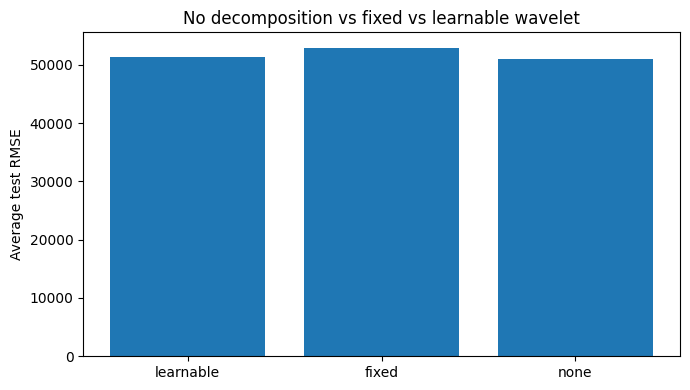

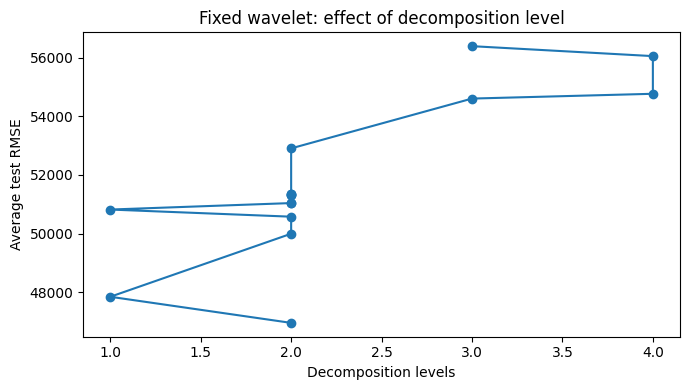

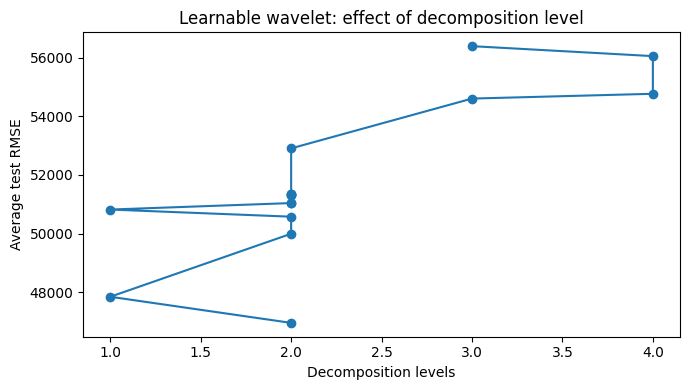

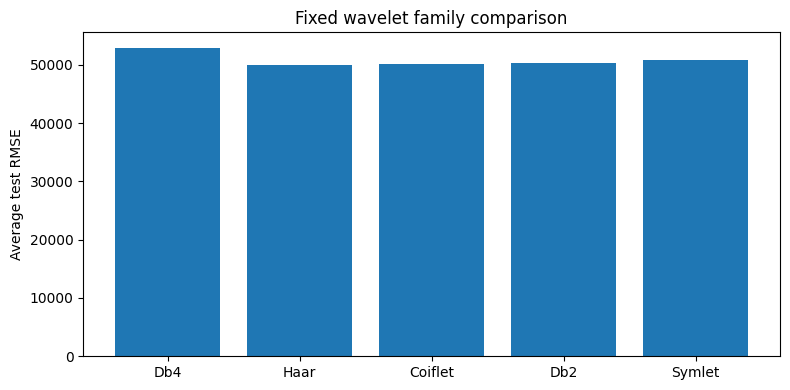

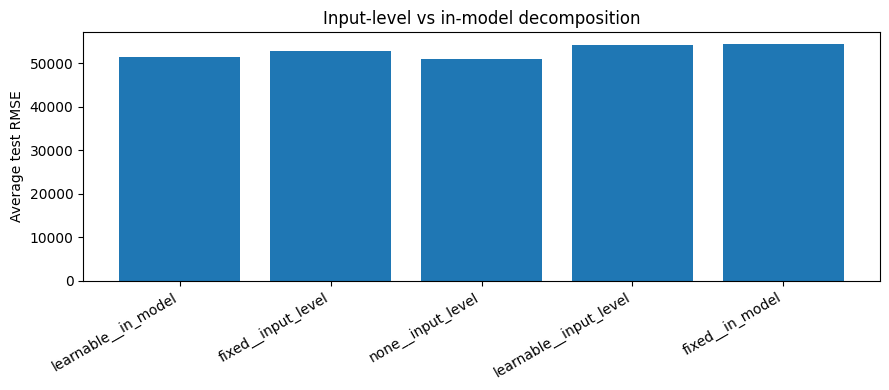

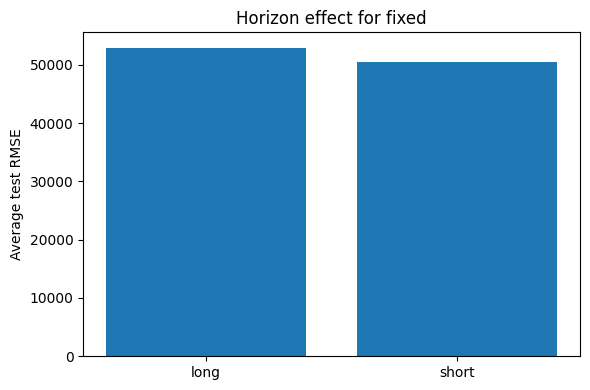

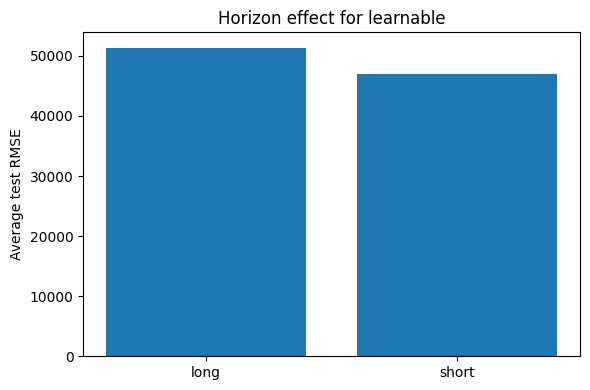

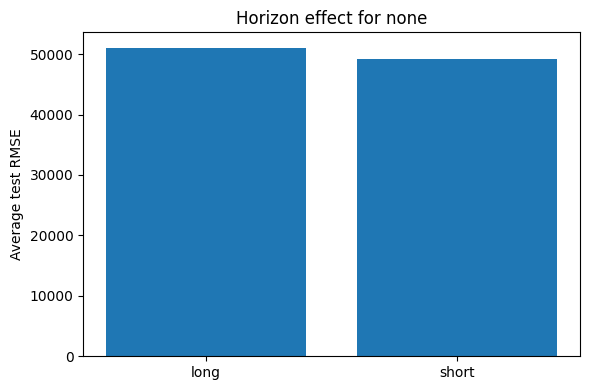

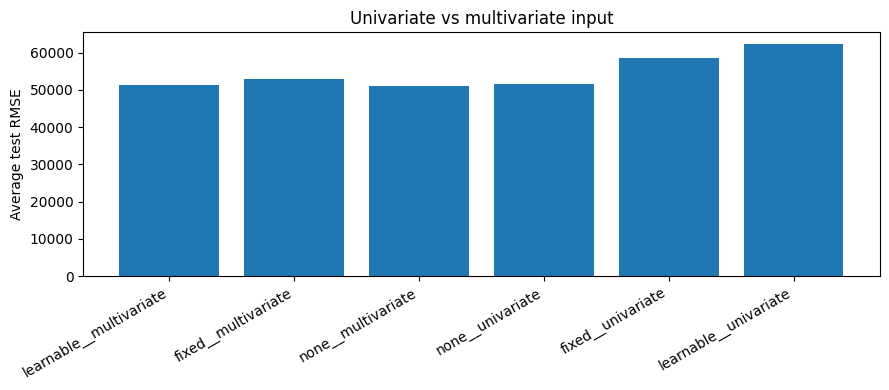

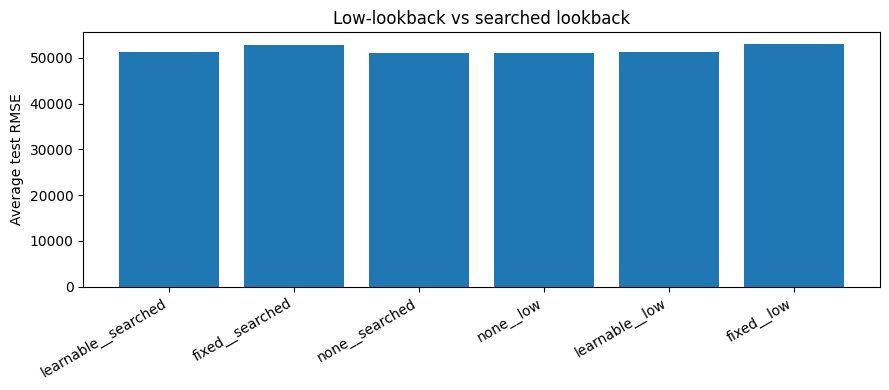

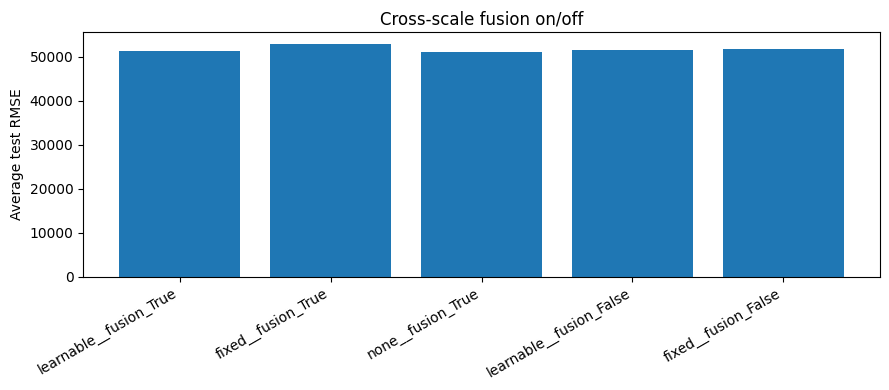

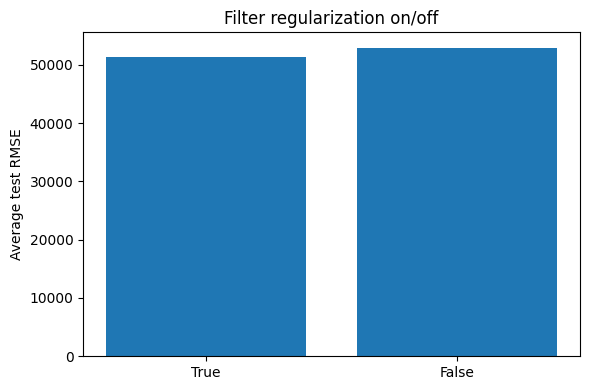

Saved Phase 4 figures to: /data/Sajjan_Singh/spml/wavelet_seq_project/results/figures/phase4


In [17]:
# ============================================
# Cell 7: Phase 4 plots
# ============================================

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from pathlib import Path

PHASE4_DIR = ROOT / "results" / "tables" / "phase4"
PHASE4_FIG_DIR = ROOT / "results" / "figures" / "phase4"
PHASE4_FIG_DIR.mkdir(parents=True, exist_ok=True)

# 1) decomposition effect
decomp_path = PHASE4_DIR / "summary_decomposition_effect.csv"
if decomp_path.exists():
    d = pd.read_csv(decomp_path)
    plt.figure(figsize=(7, 4))
    plt.bar(d["model_variant"], d["test_rmse"])
    plt.ylabel("Average test RMSE")
    plt.title("No decomposition vs fixed vs learnable wavelet")
    plt.tight_layout()
    plt.savefig(PHASE4_FIG_DIR / "decomposition_effect_rmse.png", dpi=200, bbox_inches="tight")
    plt.show()

# 2) levels fixed
lvl_fixed_path = PHASE4_DIR / "summary_levels_fixed.csv"
if lvl_fixed_path.exists():
    d = pd.read_csv(lvl_fixed_path)
    plt.figure(figsize=(7, 4))
    plt.plot(d["levels"], d["test_rmse"], marker="o")
    plt.xlabel("Decomposition levels")
    plt.ylabel("Average test RMSE")
    plt.title("Fixed wavelet: effect of decomposition level")
    plt.tight_layout()
    plt.savefig(PHASE4_FIG_DIR / "levels_fixed_rmse.png", dpi=200, bbox_inches="tight")
    plt.show()

# 3) levels learnable
lvl_learn_path = PHASE4_DIR / "summary_levels_learnable.csv"
if lvl_learn_path.exists():
    d = pd.read_csv(lvl_learn_path)
    plt.figure(figsize=(7, 4))
    plt.plot(d["levels"], d["test_rmse"], marker="o")
    plt.xlabel("Decomposition levels")
    plt.ylabel("Average test RMSE")
    plt.title("Learnable wavelet: effect of decomposition level")
    plt.tight_layout()
    plt.savefig(PHASE4_FIG_DIR / "levels_learnable_rmse.png", dpi=200, bbox_inches="tight")
    plt.show()

# 4) families fixed
fam_path = PHASE4_DIR / "summary_families_fixed.csv"
if fam_path.exists():
    d = pd.read_csv(fam_path)
    plt.figure(figsize=(8, 4))
    plt.bar(d["wavelet_family"], d["test_rmse"])
    plt.ylabel("Average test RMSE")
    plt.title("Fixed wavelet family comparison")
    plt.tight_layout()
    plt.savefig(PHASE4_FIG_DIR / "families_fixed_rmse.png", dpi=200, bbox_inches="tight")
    plt.show()

# 5) input vs in-model
loc_path = PHASE4_DIR / "summary_input_vs_inmodel.csv"
if loc_path.exists():
    d = pd.read_csv(loc_path)
    labels = d["model_variant"].astype(str) + "__" + d["decomposition_location"].astype(str)
    plt.figure(figsize=(9, 4))
    plt.bar(labels, d["test_rmse"])
    plt.xticks(rotation=30, ha="right")
    plt.ylabel("Average test RMSE")
    plt.title("Input-level vs in-model decomposition")
    plt.tight_layout()
    plt.savefig(PHASE4_FIG_DIR / "input_vs_inmodel_rmse.png", dpi=200, bbox_inches="tight")
    plt.show()

# 6) horizon
hz_path = PHASE4_DIR / "summary_short_vs_long.csv"
if hz_path.exists():
    d = pd.read_csv(hz_path)
    for mv in sorted(d["model_variant"].unique()):
        sub = d[d["model_variant"] == mv].sort_values("horizon_mode")
        plt.figure(figsize=(6, 4))
        plt.bar(sub["horizon_mode"], sub["test_rmse"])
        plt.ylabel("Average test RMSE")
        plt.title(f"Horizon effect for {mv}")
        plt.tight_layout()
        plt.savefig(PHASE4_FIG_DIR / f"horizon_{mv}_rmse.png", dpi=200, bbox_inches="tight")
        plt.show()

# 7) univariate vs multivariate
uvm_path = PHASE4_DIR / "summary_univariate_vs_multivariate.csv"
if uvm_path.exists():
    d = pd.read_csv(uvm_path)
    labels = d["model_variant"].astype(str) + "__" + d["input_mode"].astype(str)
    plt.figure(figsize=(9, 4))
    plt.bar(labels, d["test_rmse"])
    plt.xticks(rotation=30, ha="right")
    plt.ylabel("Average test RMSE")
    plt.title("Univariate vs multivariate input")
    plt.tight_layout()
    plt.savefig(PHASE4_FIG_DIR / "univariate_vs_multivariate_rmse.png", dpi=200, bbox_inches="tight")
    plt.show()

# 8) lookback
lb_path = PHASE4_DIR / "summary_lookback_ablation.csv"
if lb_path.exists():
    d = pd.read_csv(lb_path)
    labels = d["model_variant"].astype(str) + "__" + d["lookback_mode"].astype(str)
    plt.figure(figsize=(9, 4))
    plt.bar(labels, d["test_rmse"])
    plt.xticks(rotation=30, ha="right")
    plt.ylabel("Average test RMSE")
    plt.title("Low-lookback vs searched lookback")
    plt.tight_layout()
    plt.savefig(PHASE4_FIG_DIR / "lookback_ablation_rmse.png", dpi=200, bbox_inches="tight")
    plt.show()

# 9) cross-scale fusion
fusion_path = PHASE4_DIR / "summary_cross_scale_fusion.csv"
if fusion_path.exists():
    d = pd.read_csv(fusion_path)
    labels = d["model_variant"].astype(str) + "__fusion_" + d["cross_scale_fusion"].astype(str)
    plt.figure(figsize=(9, 4))
    plt.bar(labels, d["test_rmse"])
    plt.xticks(rotation=30, ha="right")
    plt.ylabel("Average test RMSE")
    plt.title("Cross-scale fusion on/off")
    plt.tight_layout()
    plt.savefig(PHASE4_FIG_DIR / "cross_scale_fusion_rmse.png", dpi=200, bbox_inches="tight")
    plt.show()

# 10) regularization
reg_path = PHASE4_DIR / "summary_filter_regularization.csv"
if reg_path.exists():
    d = pd.read_csv(reg_path)
    plt.figure(figsize=(6, 4))
    plt.bar(d["filter_regularization"].astype(str), d["test_rmse"])
    plt.ylabel("Average test RMSE")
    plt.title("Filter regularization on/off")
    plt.tight_layout()
    plt.savefig(PHASE4_FIG_DIR / "filter_regularization_rmse.png", dpi=200, bbox_inches="tight")
    plt.show()

print("Saved Phase 4 figures to:", PHASE4_FIG_DIR)

In [18]:
# ============================================
# Cell 8: Auto-generate Phase 4 summary notes
# ============================================

from pathlib import Path
import pandas as pd

PHASE4_DIR = ROOT / "results" / "tables" / "phase4"
NOTES_DIR = ROOT / "paper" / "notes"
NOTES_DIR.mkdir(parents=True, exist_ok=True)

lines = []
lines.append("# Phase 4 Ablation Summary")
lines.append("")

# Helper
def load_if_exists(name):
    p = PHASE4_DIR / name
    return pd.read_csv(p) if p.exists() else None

decomp = load_if_exists("summary_decomposition_effect.csv")
if decomp is not None and len(decomp) > 0:
    best = decomp.sort_values("test_rmse").iloc[0]
    lines.append("## Decomposition effect")
    lines.append(f"- Best decomposition variant: **{best['model_variant']}** with average RMSE **{best['test_rmse']:.6f}**.")
    lines.append("")

lvl_fixed = load_if_exists("summary_levels_fixed.csv")
if lvl_fixed is not None and len(lvl_fixed) > 0:
    best = lvl_fixed.sort_values("test_rmse").iloc[0]
    lines.append("## Fixed wavelet level effect")
    lines.append(f"- Best fixed-wavelet level: **{int(best['levels'])}** with average RMSE **{best['test_rmse']:.6f}**.")
    lines.append("")

lvl_learn = load_if_exists("summary_levels_learnable.csv")
if lvl_learn is not None and len(lvl_learn) > 0:
    best = lvl_learn.sort_values("test_rmse").iloc[0]
    lines.append("## Learnable wavelet level effect")
    lines.append(f"- Best learnable-wavelet level: **{int(best['levels'])}** with average RMSE **{best['test_rmse']:.6f}**.")
    lines.append("")

fam = load_if_exists("summary_families_fixed.csv")
if fam is not None and len(fam) > 0:
    best = fam.sort_values("test_rmse").iloc[0]
    lines.append("## Wavelet family effect")
    lines.append(f"- Best fixed wavelet family: **{best['wavelet_family']}** with average RMSE **{best['test_rmse']:.6f}**.")
    lines.append("")

loc = load_if_exists("summary_input_vs_inmodel.csv")
if loc is not None and len(loc) > 0:
    best = loc.sort_values("test_rmse").iloc[0]
    lines.append("## Input-level vs in-model decomposition")
    lines.append(
        f"- Best combination: **{best['model_variant']} + {best['decomposition_location']}** "
        f"with average RMSE **{best['test_rmse']:.6f}**."
    )
    lines.append("")

hz = load_if_exists("summary_short_vs_long.csv")
if hz is not None and len(hz) > 0:
    lines.append("## Horizon effect")
    best = hz.sort_values("test_rmse").iloc[0]
    lines.append(
        f"- Best horizon/model combination: **{best['model_variant']} + {best['horizon_mode']}** "
        f"with average RMSE **{best['test_rmse']:.6f}**."
    )
    lines.append("")

inp = load_if_exists("summary_univariate_vs_multivariate.csv")
if inp is not None and len(inp) > 0:
    best = inp.sort_values("test_rmse").iloc[0]
    lines.append("## Input mode effect")
    lines.append(
        f"- Best input mode/model combination: **{best['model_variant']} + {best['input_mode']}** "
        f"with average RMSE **{best['test_rmse']:.6f}**."
    )
    lines.append("")

lb = load_if_exists("summary_lookback_ablation.csv")
if lb is not None and len(lb) > 0:
    best = lb.sort_values("test_rmse").iloc[0]
    lines.append("## Lookback effect")
    lines.append(
        f"- Best lookback/model combination: **{best['model_variant']} + {best['lookback_mode']}** "
        f"with average RMSE **{best['test_rmse']:.6f}**."
    )
    lines.append("")

fusion = load_if_exists("summary_cross_scale_fusion.csv")
if fusion is not None and len(fusion) > 0:
    best = fusion.sort_values("test_rmse").iloc[0]
    lines.append("## Cross-scale fusion effect")
    lines.append(
        f"- Best fusion/model combination: **{best['model_variant']} + fusion={best['cross_scale_fusion']}** "
        f"with average RMSE **{best['test_rmse']:.6f}**."
    )
    lines.append("")

reg = load_if_exists("summary_filter_regularization.csv")
if reg is not None and len(reg) > 0:
    best = reg.sort_values("test_rmse").iloc[0]
    lines.append("## Filter regularization effect")
    lines.append(
        f"- Best regularization setting: **filter_regularization={best['filter_regularization']}** "
        f"with average RMSE **{best['test_rmse']:.6f}**."
    )
    lines.append("")

summary_path = NOTES_DIR / "phase4_ablation_summary.md"
summary_path.write_text("\n".join(lines))

print("Saved:", summary_path)
print("\n".join(lines))

Saved: /data/Sajjan_Singh/spml/wavelet_seq_project/paper/notes/phase4_ablation_summary.md
# Phase 4 Ablation Summary

## Decomposition effect
- Best decomposition variant: **learnable** with average RMSE **46952.768462**.

## Fixed wavelet level effect
- Best fixed-wavelet level: **2** with average RMSE **46950.167117**.

## Learnable wavelet level effect
- Best learnable-wavelet level: **2** with average RMSE **46950.167117**.

## Wavelet family effect
- Best fixed wavelet family: **Db4** with average RMSE **46950.167117**.

## Input-level vs in-model decomposition
- Best combination: **learnable + in_model** with average RMSE **46952.768462**.

## Horizon effect
- Best horizon/model combination: **learnable + short** with average RMSE **46952.768462**.

## Input mode effect
- Best input mode/model combination: **learnable + multivariate** with average RMSE **46952.768462**.

## Lookback effect
- Best lookback/model combination: **learnable + searched** with average RMSE **46952.76846

In [ ]:
# ============================================
# STEP 2A: Merge best-config Phase 5 into unified master
# ============================================

from pathlib import Path
import numpy as np
import pandas as pd

ROOT = Path("/data/Sajjan_Singh/spml/wavelet_seq_project")
TABLES_ROOT = ROOT / "results" / "tables"

MASTER_PATH = TABLES_ROOT / "master_all_models_metrics_unified.csv"
BEST_PATH = TABLES_ROOT / "master_best_by_dataset_unified.csv"
PHASE5_REGISTRY_PATH = TABLES_ROOT / "phase5" / "phase5_bestcfg_prediction_registry.csv"

def mse(y, yhat):
    y = np.asarray(y, dtype=np.float64)
    yhat = np.asarray(yhat, dtype=np.float64)
    return float(np.mean((y - yhat) ** 2))

def mae(y, yhat):
    y = np.asarray(y, dtype=np.float64)
    yhat = np.asarray(yhat, dtype=np.float64)
    return float(np.mean(np.abs(y - yhat)))

def rmse(y, yhat):
    return float(np.sqrt(mse(y, yhat)))

def metric_row_from_npz(dataset, model, family, seq_len, pred_len, pred_file_rel):
    p = ROOT / pred_file_rel
    arr = np.load(p, allow_pickle=True)
    preds = np.asarray(arr["preds"], dtype=np.float64).reshape(-1)
    trues = np.asarray(arr["trues"], dtype=np.float64).reshape(-1)
    return {
        "dataset": dataset,
        "model": model,
        "family": family,
        "seq_len": seq_len,
        "pred_len": pred_len,
        "test_mse": mse(trues, preds),
        "test_mae": mae(trues, preds),
        "test_rmse": rmse(trues, preds),
        "prediction_file": str(pred_file_rel),
    }

master = pd.read_csv(MASTER_PATH)
phase5_registry = pd.read_csv(PHASE5_REGISTRY_PATH)

# remove older AdaptiveWaveletMixer rows
master = master[master["model"] != "AdaptiveWaveletMixer"].copy()

new_rows = []
for _, r in phase5_registry.iterrows():
    new_rows.append(
        metric_row_from_npz(
            dataset=r["dataset"],
            model=r["model"],
            family=r["family"],
            seq_len=int(r["seq_len"]),
            pred_len=int(r["pred_len"]),
            pred_file_rel=r["prediction_file"],
        )
    )

new_phase5_df = pd.DataFrame(new_rows)
updated_master = pd.concat([master, new_phase5_df], ignore_index=True)
updated_master = updated_master.sort_values(["dataset", "family", "model"]).reset_index(drop=True)

updated_master.to_csv(MASTER_PATH, index=False)

updated_best = (
    updated_master.sort_values(["dataset", "test_rmse", "test_mae", "test_mse"])
                  .groupby("dataset", as_index=False)
                  .first()[["dataset", "model", "family", "test_mse", "test_mae", "test_rmse"]]
)

updated_best.to_csv(BEST_PATH, index=False)

print("Updated:", MASTER_PATH)
print("Updated:", BEST_PATH)
display(updated_best)

Saved: /data/Sajjan_Singh/spml/wavelet_seq_project/results/tables/master_all_models_metrics_unified.csv
Saved: /data/Sajjan_Singh/spml/wavelet_seq_project/results/tables/master_best_by_dataset_unified.csv

Unified master rows: 126


,dataset,model,family,test_mse,test_mae,test_rmse
0,electricity,WPMixer,modern_tslib,6.725901e+04,182.292991,259.343429
1,etth1,WPMixer,modern_tslib,4.691051e+00,1.635539,2.165884
2,etth2,dlinear,neural_non_wavelet,1.748497e+01,3.192522,4.181504
3,ettm1,WPMixer,modern_tslib,2.339102e+00,1.147820,1.529412
4,ettm2,WPMixer,modern_tslib,8.495447e+00,2.109087,2.914695
5,exchange,naive,classical,7.954944e-04,0.021018,0.028205
6,ili,iTransformer,modern_tslib,3.287862e+10,125665.623324,181324.636078
7,traffic,dlinear,neural_non_wavelet,4.471525e-05,0.003913,0.006687
8,weather,WPMixer,modern_tslib,1.728212e+02,10.047792,13.146148


In [20]:
# ============================================
# New Cell 17: Run all remaining Phase 4 ablation grids
# ============================================

REMAINING_GRIDS = [
    "levels_fixed",
    "levels_learnable",
    "families_fixed",
    "input_vs_inmodel",
    "short_vs_long_horizon",
    "univariate_vs_multivariate",
    "lookback_ablation",
    "cross_scale_fusion",
    "filter_regularization",
]

PHASE4_BATCHES = [
    ["levels_fixed", "levels_learnable", "families_fixed"],
    ["input_vs_inmodel", "short_vs_long_horizon", "univariate_vs_multivariate"],
    ["lookback_ablation", "cross_scale_fusion", "filter_regularization"],
]

LIMIT_PER_GRID = None
OVERWRITE = False

def run_phase4_batch(batch_name, grid_names):
    print("\n" + "#" * 140)
    print("RUNNING PHASE 4 BATCH:", batch_name)
    print("GRIDS:", grid_names)
    print("#" * 140)

    out = {}
    for grid_name in grid_names:
        print("\n" + "=" * 120)
        print("GRID:", grid_name)
        print("=" * 120)
        df_out = p4.run_grid(
            grids[grid_name],
            out_csv_name=f"{grid_name}_metrics.csv",
            overwrite=OVERWRITE,
            limit=LIMIT_PER_GRID,
        )
        out[grid_name] = df_out
        print("Completed:", grid_name, "| rows:", len(df_out))
        display(df_out.tail(5))
    return out

In [21]:
# ============================================
# Phase 4 setup: robust import of p4 and build grids
# ============================================

from pathlib import Path
import sys
import importlib

ROOT = Path("/data/Sajjan_Singh/spml/wavelet_seq_project")
SCRIPTS_DIR = ROOT / "scripts"
RUNNER_PATH = SCRIPTS_DIR / "phase4_ablation_runner.py"

print("ROOT:", ROOT)
print("RUNNER_PATH:", RUNNER_PATH)

if not RUNNER_PATH.exists():
    raise FileNotFoundError(
        f"Missing runner file: {RUNNER_PATH}\n"
        "Please first run the earlier cell that writes phase4_ablation_runner.py"
    )

if str(SCRIPTS_DIR) not in sys.path:
    sys.path.append(str(SCRIPTS_DIR))

import phase4_ablation_runner as p4
importlib.reload(p4)

print("Imported p4 from:", RUNNER_PATH)
print("DEVICE:", p4.DEVICE)

grids = p4.build_phase4_grids()

print("\nAvailable Phase 4 grids:")
for name, g in grids.items():
    print(f"{name:28s} -> {len(g)} experiments")

ROOT: /data/Sajjan_Singh/spml/wavelet_seq_project
RUNNER_PATH: /data/Sajjan_Singh/spml/wavelet_seq_project/scripts/phase4_ablation_runner.py
Imported p4 from: /data/Sajjan_Singh/spml/wavelet_seq_project/scripts/phase4_ablation_runner.py
DEVICE: cuda

Available Phase 4 grids:
decomposition_effect         -> 27 experiments
levels_fixed                 -> 36 experiments
levels_learnable             -> 36 experiments
families_fixed               -> 45 experiments
input_vs_inmodel             -> 36 experiments
short_vs_long_horizon        -> 54 experiments
univariate_vs_multivariate   -> 54 experiments
lookback_ablation            -> 54 experiments
cross_scale_fusion           -> 36 experiments
filter_regularization        -> 18 experiments


In [22]:
# ============================================
# Phase 4 batch runner
# ============================================

PHASE4_BATCHES = [
    ["levels_fixed", "levels_learnable", "families_fixed"],
    ["input_vs_inmodel", "short_vs_long_horizon", "univariate_vs_multivariate"],
    ["lookback_ablation", "cross_scale_fusion", "filter_regularization"],
]

LIMIT_PER_GRID = None     # keep None for full run
OVERWRITE = False         # keep False so already-finished rows are not rerun

def run_phase4_batch(batch_name, grid_names):
    print("\n" + "#" * 140)
    print("RUNNING PHASE 4 BATCH:", batch_name)
    print("GRIDS:", grid_names)
    print("#" * 140)

    out = {}
    for grid_name in grid_names:
        if grid_name not in grids:
            raise KeyError(f"Grid '{grid_name}' not found. Available: {list(grids.keys())}")

        print("\n" + "=" * 120)
        print("GRID:", grid_name)
        print("=" * 120)

        df_out = p4.run_grid(
            grids[grid_name],
            out_csv_name=f"{grid_name}_metrics.csv",
            overwrite=OVERWRITE,
            limit=LIMIT_PER_GRID,
        )

        out[grid_name] = df_out
        print("Completed:", grid_name, "| rows:", len(df_out))
        display(df_out.tail(5))

    return out

In [23]:
phase4_batch1_outputs = run_phase4_batch("batch_1", PHASE4_BATCHES[0])


############################################################################################################################################
RUNNING PHASE 4 BATCH: batch_1
GRIDS: ['levels_fixed', 'levels_learnable', 'families_fixed']
############################################################################################################################################

GRID: levels_fixed
Completed: levels_fixed | rows: 36


,study,dataset,model_variant,wavelet_family,levels,decomposition_location,horizon_mode,input_mode,lookback_mode,cross_scale_fusion,...,input_dim,search_best_val_rmse,val_mse,val_mae,val_rmse,test_mse,test_mae,test_rmse,train_seconds,status
31,levels_fixed,exchange,fixed,Db4,4,input_level,long,multivariate,searched,True,...,8,0.074699,5.366747e-03,0.063577,0.073258,1.681751e-02,0.104782,0.129682,4.448191,ok
32,levels_fixed,ili,fixed,Db4,1,input_level,long,multivariate,searched,True,...,7,65619.177336,2.456124e+09,37960.555251,49559.299401,1.850081e+11,364265.748330,430125.663194,9.353632,ok
33,levels_fixed,ili,fixed,Db4,2,input_level,long,multivariate,searched,True,...,7,66703.256533,2.844258e+09,40675.251478,53331.588913,2.263550e+11,410412.210715,475767.758239,7.668889,ok
34,levels_fixed,ili,fixed,Db4,3,input_level,long,multivariate,searched,True,...,7,62939.206744,2.683838e+09,37676.400127,51805.772231,2.572502e+11,439204.596078,507198.400535,10.682718,ok
35,levels_fixed,ili,fixed,Db4,4,input_level,long,multivariate,searched,True,...,7,72077.020980,3.156925e+09,42883.101562,56186.515448,2.426197e+11,429886.844792,492564.380105,11.801213,ok



GRID: levels_learnable
Completed: levels_learnable | rows: 36


,study,dataset,model_variant,wavelet_family,levels,decomposition_location,horizon_mode,input_mode,lookback_mode,cross_scale_fusion,...,input_dim,search_best_val_rmse,val_mse,val_mae,val_rmse,test_mse,test_mae,test_rmse,train_seconds,status
31,levels_learnable,exchange,learnable,Db4,4,in_model,long,multivariate,searched,True,...,8,0.067795,4.804463e-03,0.059772,0.069314,7.149137e-03,0.070747,0.084553,5.541343,ok
32,levels_learnable,ili,learnable,Db4,1,in_model,long,multivariate,searched,True,...,7,64042.944752,3.434563e+09,46678.684614,58605.143932,2.087893e+11,395828.779871,456934.638849,9.668585,ok
33,levels_learnable,ili,learnable,Db4,2,in_model,long,multivariate,searched,True,...,7,64078.775180,2.823519e+09,42570.401570,53136.797081,2.131101e+11,398164.673729,461638.522180,11.993273,ok
34,levels_learnable,ili,learnable,Db4,3,in_model,long,multivariate,searched,True,...,7,62372.290277,2.752372e+09,39287.106137,52463.056069,2.411331e+11,421555.106204,491053.091599,12.907369,ok
35,levels_learnable,ili,learnable,Db4,4,in_model,long,multivariate,searched,True,...,7,70284.791146,5.977858e+09,62224.623821,77316.608795,2.541156e+11,443995.468283,504098.841839,5.308446,ok



GRID: families_fixed
Completed: families_fixed | rows: 45


,study,dataset,model_variant,wavelet_family,levels,decomposition_location,horizon_mode,input_mode,lookback_mode,cross_scale_fusion,...,input_dim,search_best_val_rmse,val_mse,val_mae,val_rmse,test_mse,test_mae,test_rmse,train_seconds,status
40,families_fixed,ili,fixed,Haar,2,input_level,long,multivariate,searched,True,...,7,66358.285162,2.964325e+09,42394.208720,54445.610557,2.021301e+11,383580.166498,449588.864030,8.741198,ok
41,families_fixed,ili,fixed,Db2,2,input_level,long,multivariate,searched,True,...,7,64636.318649,3.124411e+09,42457.662901,55896.428723,2.050895e+11,391851.209681,452868.107006,6.966361,ok
42,families_fixed,ili,fixed,Db4,2,input_level,long,multivariate,searched,True,...,7,66703.256533,2.844258e+09,40675.251478,53331.588913,2.263550e+11,410412.210715,475767.758239,7.196011,ok
43,families_fixed,ili,fixed,Symlet,2,input_level,long,multivariate,searched,True,...,7,68191.704915,3.219598e+09,45907.692814,56741.503812,2.082250e+11,391862.076731,456316.748660,7.475223,ok
44,families_fixed,ili,fixed,Coiflet,2,input_level,long,multivariate,searched,True,...,7,67284.632387,2.915311e+09,41291.394285,53993.623410,2.026091e+11,387647.904565,450121.197286,10.776733,ok


In [24]:
phase4_batch2_outputs = run_phase4_batch("batch_2", PHASE4_BATCHES[1])


############################################################################################################################################
RUNNING PHASE 4 BATCH: batch_2
GRIDS: ['input_vs_inmodel', 'short_vs_long_horizon', 'univariate_vs_multivariate']
############################################################################################################################################

GRID: input_vs_inmodel
Completed: input_vs_inmodel | rows: 36


,study,dataset,model_variant,wavelet_family,levels,decomposition_location,horizon_mode,input_mode,lookback_mode,cross_scale_fusion,...,input_dim,search_best_val_rmse,val_mse,val_mae,val_rmse,test_mse,test_mae,test_rmse,train_seconds,status
31,input_vs_inmodel,exchange,learnable,Db4,2,in_model,long,multivariate,searched,True,...,8,0.062073,5.366900e-03,0.065787,0.073259,6.815160e-03,0.074280,0.082554,4.426204,ok
32,input_vs_inmodel,ili,fixed,Db4,2,input_level,long,multivariate,searched,True,...,7,66703.256533,2.844258e+09,40675.251478,53331.588913,2.263550e+11,410412.210715,475767.758239,6.982916,ok
33,input_vs_inmodel,ili,fixed,Db4,2,in_model,long,multivariate,searched,True,...,7,63904.560574,3.245050e+09,44391.700556,56965.343376,2.393737e+11,428480.650000,489258.272148,10.071913,ok
34,input_vs_inmodel,ili,learnable,Db4,2,input_level,long,multivariate,searched,True,...,7,65989.666050,2.994627e+09,41384.175077,54723.185173,2.379134e+11,423296.725582,487763.708791,10.928004,ok
35,input_vs_inmodel,ili,learnable,Db4,2,in_model,long,multivariate,searched,True,...,7,64076.019191,2.816986e+09,42497.526992,53075.282173,2.130555e+11,398069.530515,461579.305258,11.066034,ok



GRID: short_vs_long_horizon
Completed: short_vs_long_horizon | rows: 54


,study,dataset,model_variant,wavelet_family,levels,decomposition_location,horizon_mode,input_mode,lookback_mode,cross_scale_fusion,...,input_dim,search_best_val_rmse,val_mse,val_mae,val_rmse,test_mse,test_mae,test_rmse,train_seconds,status
49,short_vs_long_horizon,ili,none,Db4,2,input_level,long,multivariate,searched,True,...,7,67772.085059,2.983784e+09,42003.345087,54624.027224,2.106838e+11,396042.518490,459003.068916,9.696797,ok
50,short_vs_long_horizon,ili,fixed,Db4,2,input_level,short,multivariate,searched,True,...,7,61624.139872,2.881638e+09,42577.374516,53680.889016,2.056981e+11,391770.416695,453539.505177,7.665390,ok
51,short_vs_long_horizon,ili,fixed,Db4,2,input_level,long,multivariate,searched,True,...,7,66703.256533,2.844258e+09,40675.251478,53331.588913,2.263550e+11,410412.210715,475767.758239,8.247924,ok
52,short_vs_long_horizon,ili,learnable,Db4,2,in_model,short,multivariate,searched,True,...,7,63989.709272,2.875128e+09,40783.777192,53620.216865,1.782762e+11,353773.987723,422227.703711,11.162853,ok
53,short_vs_long_horizon,ili,learnable,Db4,2,in_model,long,multivariate,searched,True,...,7,64076.536823,2.817614e+09,42500.975049,53081.198285,2.130684e+11,398088.807843,461593.356514,10.974587,ok



GRID: univariate_vs_multivariate
Completed: univariate_vs_multivariate | rows: 54


,study,dataset,model_variant,wavelet_family,levels,decomposition_location,horizon_mode,input_mode,lookback_mode,cross_scale_fusion,...,input_dim,search_best_val_rmse,val_mse,val_mae,val_rmse,test_mse,test_mae,test_rmse,train_seconds,status
49,univariate_vs_multivariate,ili,none,Db4,2,input_level,long,multivariate,searched,True,...,7,67772.085059,2.983784e+09,42003.345087,54624.027224,2.106838e+11,396042.518490,459003.068916,12.902220,ok
50,univariate_vs_multivariate,ili,fixed,Db4,2,input_level,long,univariate,searched,True,...,1,78562.201679,3.377504e+09,48691.076348,58116.300382,2.767795e+11,454079.430331,526098.354475,10.648115,ok
51,univariate_vs_multivariate,ili,fixed,Db4,2,input_level,long,multivariate,searched,True,...,7,66703.256533,2.844258e+09,40675.251478,53331.588913,2.263550e+11,410412.210715,475767.758239,7.384911,ok
52,univariate_vs_multivariate,ili,learnable,Db4,2,in_model,long,univariate,searched,True,...,1,84571.748683,3.601805e+09,51227.392684,60015.042381,3.144878e+11,490351.433839,560792.106252,9.278768,ok
53,univariate_vs_multivariate,ili,learnable,Db4,2,in_model,long,multivariate,searched,True,...,7,64077.950808,2.826510e+09,40363.454322,53164.933864,2.068703e+11,390519.076057,454829.989285,9.955154,ok


In [25]:
phase4_batch3_outputs = run_phase4_batch("batch_3", PHASE4_BATCHES[2])


############################################################################################################################################
RUNNING PHASE 4 BATCH: batch_3
GRIDS: ['lookback_ablation', 'cross_scale_fusion', 'filter_regularization']
############################################################################################################################################

GRID: lookback_ablation
Completed: lookback_ablation | rows: 54


,study,dataset,model_variant,wavelet_family,levels,decomposition_location,horizon_mode,input_mode,lookback_mode,cross_scale_fusion,...,input_dim,search_best_val_rmse,val_mse,val_mae,val_rmse,test_mse,test_mae,test_rmse,train_seconds,status
49,lookback_ablation,ili,none,Db4,2,input_level,long,multivariate,searched,True,...,7,67772.085059,2.983784e+09,42003.345087,54624.027224,2.106838e+11,396042.518490,459003.068916,11.841321,ok
50,lookback_ablation,ili,fixed,Db4,2,input_level,long,multivariate,low,True,...,7,54640.865274,3.044686e+09,42677.923072,55178.670818,2.266571e+11,408876.882812,476085.217148,10.797769,ok
51,lookback_ablation,ili,fixed,Db4,2,input_level,long,multivariate,searched,True,...,7,66703.256533,2.844258e+09,40675.251478,53331.588913,2.263550e+11,410412.210715,475767.758239,8.013873,ok
52,lookback_ablation,ili,learnable,Db4,2,in_model,long,multivariate,low,True,...,7,54304.616563,2.855584e+09,40899.172473,53437.662190,2.132590e+11,396155.894577,461799.748546,11.470242,ok
53,lookback_ablation,ili,learnable,Db4,2,in_model,long,multivariate,searched,True,...,7,64076.019191,2.817776e+09,42504.466885,53082.729073,2.130612e+11,398099.295803,461585.543709,12.858366,ok



GRID: cross_scale_fusion
Completed: cross_scale_fusion | rows: 36


,study,dataset,model_variant,wavelet_family,levels,decomposition_location,horizon_mode,input_mode,lookback_mode,cross_scale_fusion,...,input_dim,search_best_val_rmse,val_mse,val_mae,val_rmse,test_mse,test_mae,test_rmse,train_seconds,status
31,cross_scale_fusion,exchange,learnable,Db4,2,in_model,long,multivariate,searched,True,...,8,0.062073,5.366900e-03,0.065787,0.073259,6.815160e-03,0.074280,0.082554,5.203829,ok
32,cross_scale_fusion,ili,fixed,Db4,2,input_level,long,multivariate,searched,False,...,7,63187.029222,3.113310e+09,43657.719172,55797.045059,2.175897e+11,401361.059850,466465.067027,8.952372,ok
33,cross_scale_fusion,ili,fixed,Db4,2,input_level,long,multivariate,searched,True,...,7,66703.256533,2.844258e+09,40675.251478,53331.588913,2.263550e+11,410412.210715,475767.758239,8.439572,ok
34,cross_scale_fusion,ili,learnable,Db4,2,in_model,long,multivariate,searched,False,...,7,69830.414924,3.377441e+09,45449.725190,58115.758173,2.152065e+11,395756.925214,463903.494155,10.082330,ok
35,cross_scale_fusion,ili,learnable,Db4,2,in_model,long,multivariate,searched,True,...,7,64076.794375,2.817896e+09,42505.736557,53083.858581,2.130694e+11,398098.158885,461594.368622,12.693294,ok



GRID: filter_regularization
Completed: filter_regularization | rows: 18


,study,dataset,model_variant,wavelet_family,levels,decomposition_location,horizon_mode,input_mode,lookback_mode,cross_scale_fusion,...,input_dim,search_best_val_rmse,val_mse,val_mae,val_rmse,test_mse,test_mae,test_rmse,train_seconds,status
13,filter_regularization,traffic,learnable,Db4,2,in_model,long,multivariate,searched,True,...,862,0.005868,3.283594e-05,0.003979,0.005730,8.376358e-05,0.005872,0.009152,45.944198,ok
14,filter_regularization,exchange,learnable,Db4,2,in_model,long,multivariate,searched,True,...,8,0.062072,5.366563e-03,0.065786,0.073257,6.814806e-03,0.074278,0.082552,4.780197,ok
15,filter_regularization,exchange,learnable,Db4,2,in_model,long,multivariate,searched,True,...,8,0.062073,5.366900e-03,0.065787,0.073259,6.815160e-03,0.074280,0.082554,5.135283,ok
16,filter_regularization,ili,learnable,Db4,2,in_model,long,multivariate,searched,True,...,7,64079.463688,2.821308e+09,42547.877463,53115.986462,2.131510e+11,398189.138955,461682.796095,12.679694,ok
17,filter_regularization,ili,learnable,Db4,2,in_model,long,multivariate,searched,True,...,7,64076.234306,2.825093e+09,42587.150619,53151.606438,2.131474e+11,398200.570358,461678.846611,13.119107,ok


In [26]:
# ============================================
# Rebuild Phase 4 master and verify completion
# ============================================

from pathlib import Path
import pandas as pd

PHASE4_DIR = ROOT / "results" / "tables" / "phase4"
all_csvs = sorted(PHASE4_DIR.glob("*_metrics.csv"))

print("Phase 4 CSV files:")
for p in all_csvs:
    print(" -", p.name)

dfs = []
for p in all_csvs:
    try:
        d = pd.read_csv(p)
        d["source_file"] = p.name
        dfs.append(d)
    except Exception as e:
        print("Skipping", p.name, "because:", e)

if len(dfs) == 0:
    raise RuntimeError("No Phase 4 CSV files found.")

phase4_master = pd.concat(dfs, ignore_index=True)
phase4_master_path = PHASE4_DIR / "phase4_master_metrics.csv"
phase4_master.to_csv(phase4_master_path, index=False)

ok = phase4_master[phase4_master["status"].astype(str) == "ok"].copy()

print("\nSaved:", phase4_master_path)
print("Total rows:", len(phase4_master))
print("Usable rows:", len(ok))

done_studies = sorted(ok["study"].dropna().unique().tolist())
print("\nCompleted studies:")
for s in done_studies:
    print(" -", s)

expected_studies = sorted([
    "decomposition_effect",
    "levels_fixed",
    "levels_learnable",
    "families_fixed",
    "input_vs_inmodel",
    "short_vs_long_horizon",
    "univariate_vs_multivariate",
    "lookback_ablation",
    "cross_scale_fusion",
    "filter_regularization",
])

missing = [s for s in expected_studies if s not in done_studies]
print("\nMissing studies:", missing if len(missing) > 0 else "None")

display(ok.head(10))

Phase 4 CSV files:
 - cross_scale_fusion_metrics.csv
 - decomposition_effect_metrics.csv
 - families_fixed_metrics.csv
 - filter_regularization_metrics.csv
 - input_vs_inmodel_metrics.csv
 - levels_fixed_metrics.csv
 - levels_learnable_metrics.csv
 - lookback_ablation_metrics.csv
 - phase4_master_metrics.csv
 - short_vs_long_horizon_metrics.csv
 - univariate_vs_multivariate_metrics.csv

Saved: /data/Sajjan_Singh/spml/wavelet_seq_project/results/tables/phase4/phase4_master_metrics.csv
Total rows: 2007
Usable rows: 2007

Completed studies:
 - cross_scale_fusion
 - decomposition_effect
 - families_fixed
 - filter_regularization
 - input_vs_inmodel
 - levels_fixed
 - levels_learnable
 - lookback_ablation
 - short_vs_long_horizon
 - univariate_vs_multivariate

Missing studies: None


,study,dataset,model_variant,wavelet_family,levels,decomposition_location,horizon_mode,input_mode,lookback_mode,cross_scale_fusion,...,search_best_val_rmse,val_mse,val_mae,val_rmse,test_mse,test_mae,test_rmse,train_seconds,status,source_file
0,cross_scale_fusion,etth1,fixed,Db4,2,input_level,long,multivariate,searched,False,...,4.087203,19.519590,3.649237,4.418098,37.971763,5.704764,6.162123,5.473764,ok,cross_scale_fusion_metrics.csv
1,cross_scale_fusion,etth1,fixed,Db4,2,input_level,long,multivariate,searched,True,...,4.593657,18.964527,3.552932,4.354828,41.786545,5.983083,6.464251,5.030504,ok,cross_scale_fusion_metrics.csv
2,cross_scale_fusion,etth1,learnable,Db4,2,in_model,long,multivariate,searched,False,...,3.875103,17.018161,3.369526,4.125307,28.908065,4.841193,5.376622,6.729030,ok,cross_scale_fusion_metrics.csv
3,cross_scale_fusion,etth1,learnable,Db4,2,in_model,long,multivariate,searched,True,...,3.901912,17.534101,3.440253,4.187374,48.361416,6.519003,6.954237,6.327639,ok,cross_scale_fusion_metrics.csv
4,cross_scale_fusion,etth2,fixed,Db4,2,input_level,long,multivariate,searched,False,...,6.658902,47.152630,5.608726,6.866777,196.950423,12.754352,14.033903,5.287285,ok,cross_scale_fusion_metrics.csv
5,cross_scale_fusion,etth2,fixed,Db4,2,input_level,long,multivariate,searched,True,...,7.281689,65.705187,6.647579,8.105874,198.311033,12.628491,14.082295,6.404837,ok,cross_scale_fusion_metrics.csv
6,cross_scale_fusion,etth2,learnable,Db4,2,in_model,long,multivariate,searched,False,...,6.686835,38.602582,4.978990,6.213098,181.901079,12.197229,13.487071,6.282505,ok,cross_scale_fusion_metrics.csv
7,cross_scale_fusion,etth2,learnable,Db4,2,in_model,long,multivariate,searched,True,...,7.252205,52.147170,5.890201,7.221300,237.891654,14.257439,15.423737,6.181954,ok,cross_scale_fusion_metrics.csv
8,cross_scale_fusion,ettm1,fixed,Db4,2,input_level,long,multivariate,searched,False,...,2.461352,6.690535,2.030789,2.586607,7.348664,2.180174,2.710842,23.688512,ok,cross_scale_fusion_metrics.csv
9,cross_scale_fusion,ettm1,fixed,Db4,2,input_level,long,multivariate,searched,True,...,2.509302,7.022588,2.106906,2.650017,10.589800,2.711250,3.254197,19.998500,ok,cross_scale_fusion_metrics.csv


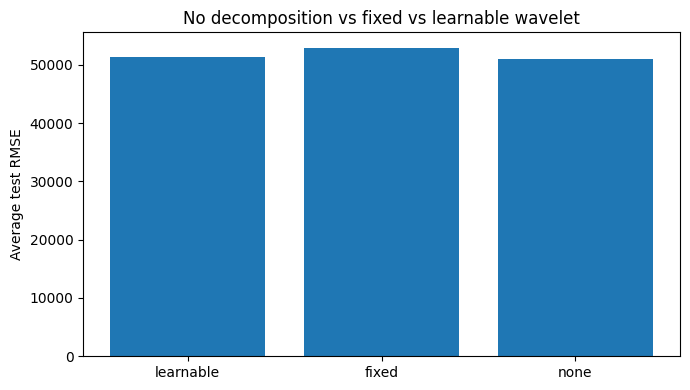

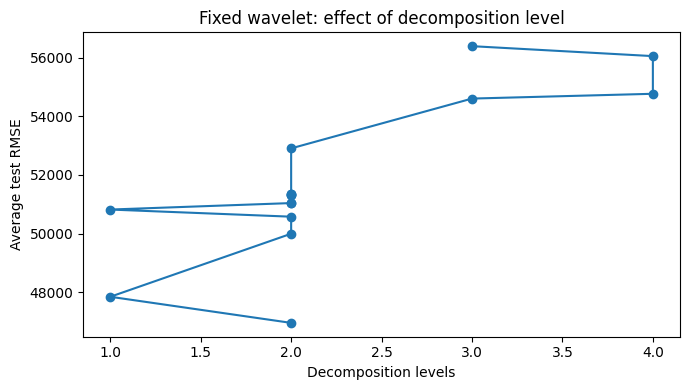

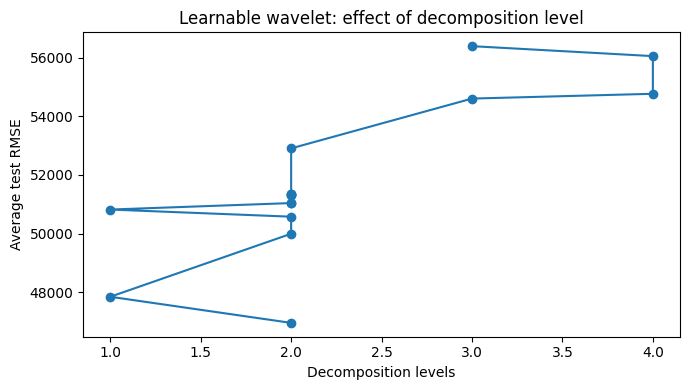

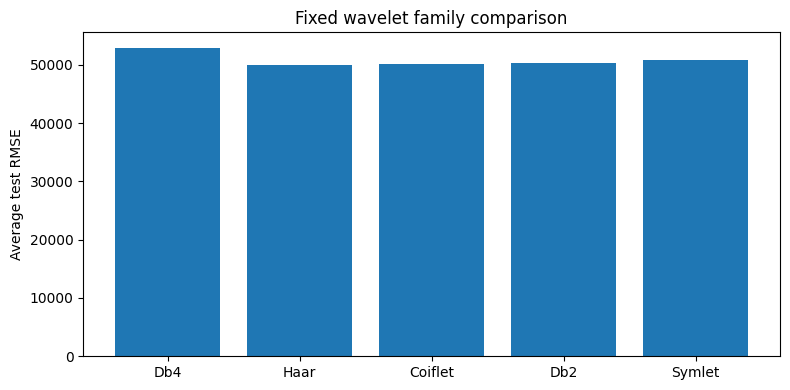

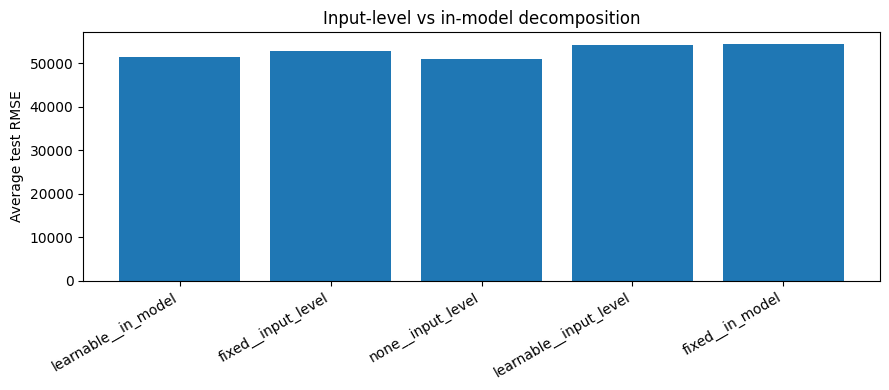

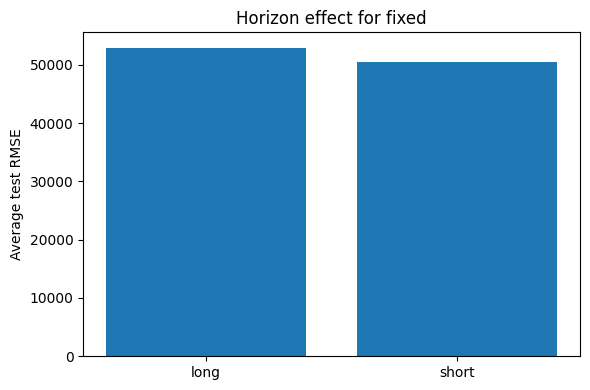

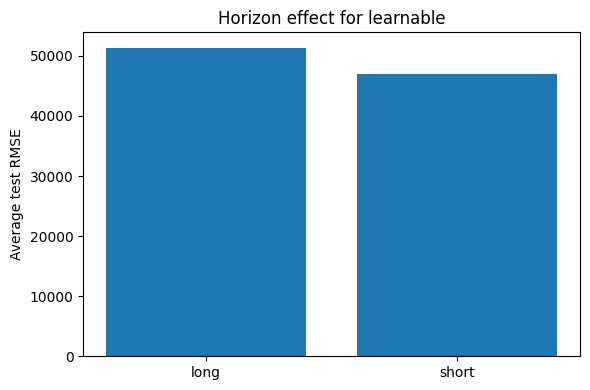

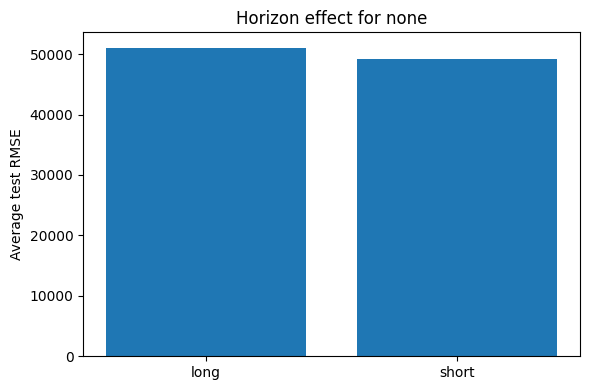

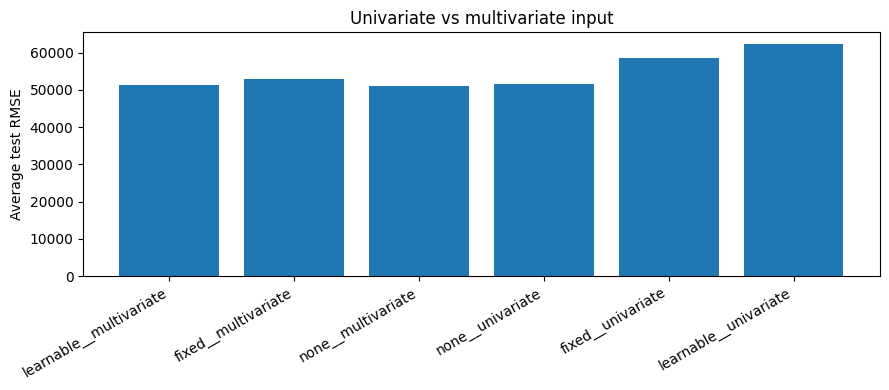

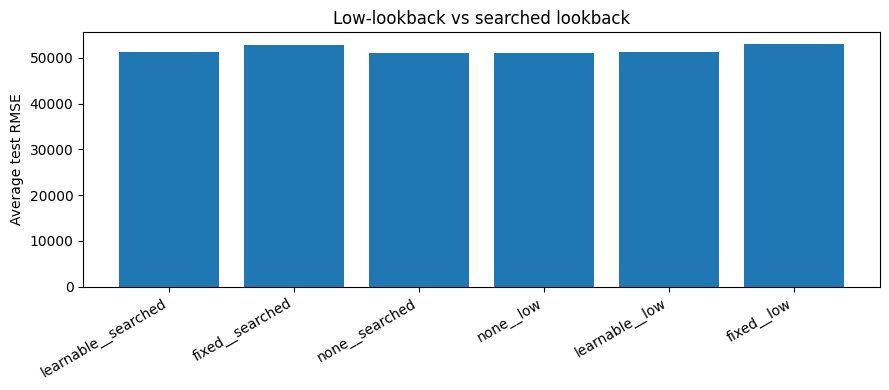

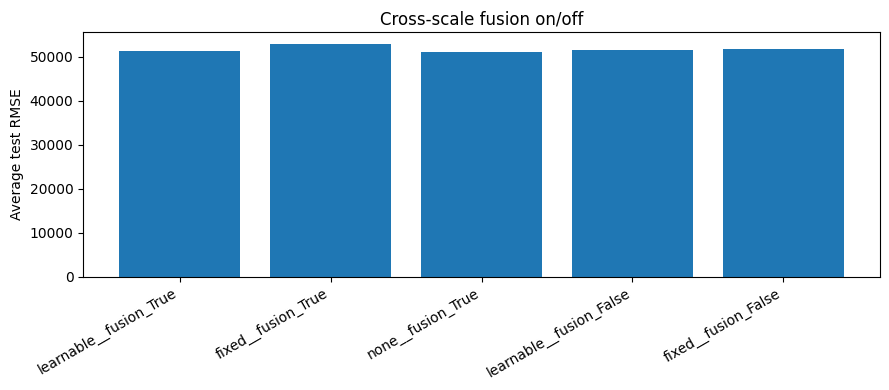

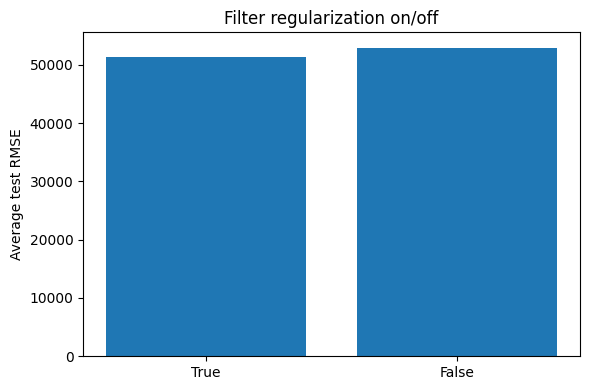

Saved Phase 4 figures to: /data/Sajjan_Singh/spml/wavelet_seq_project/results/figures/phase4


In [27]:
# ============================================
# Cell 7: Phase 4 plots
# ============================================

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from pathlib import Path

PHASE4_DIR = ROOT / "results" / "tables" / "phase4"
PHASE4_FIG_DIR = ROOT / "results" / "figures" / "phase4"
PHASE4_FIG_DIR.mkdir(parents=True, exist_ok=True)

# 1) decomposition effect
decomp_path = PHASE4_DIR / "summary_decomposition_effect.csv"
if decomp_path.exists():
    d = pd.read_csv(decomp_path)
    plt.figure(figsize=(7, 4))
    plt.bar(d["model_variant"], d["test_rmse"])
    plt.ylabel("Average test RMSE")
    plt.title("No decomposition vs fixed vs learnable wavelet")
    plt.tight_layout()
    plt.savefig(PHASE4_FIG_DIR / "decomposition_effect_rmse.png", dpi=200, bbox_inches="tight")
    plt.show()

# 2) levels fixed
lvl_fixed_path = PHASE4_DIR / "summary_levels_fixed.csv"
if lvl_fixed_path.exists():
    d = pd.read_csv(lvl_fixed_path)
    plt.figure(figsize=(7, 4))
    plt.plot(d["levels"], d["test_rmse"], marker="o")
    plt.xlabel("Decomposition levels")
    plt.ylabel("Average test RMSE")
    plt.title("Fixed wavelet: effect of decomposition level")
    plt.tight_layout()
    plt.savefig(PHASE4_FIG_DIR / "levels_fixed_rmse.png", dpi=200, bbox_inches="tight")
    plt.show()

# 3) levels learnable
lvl_learn_path = PHASE4_DIR / "summary_levels_learnable.csv"
if lvl_learn_path.exists():
    d = pd.read_csv(lvl_learn_path)
    plt.figure(figsize=(7, 4))
    plt.plot(d["levels"], d["test_rmse"], marker="o")
    plt.xlabel("Decomposition levels")
    plt.ylabel("Average test RMSE")
    plt.title("Learnable wavelet: effect of decomposition level")
    plt.tight_layout()
    plt.savefig(PHASE4_FIG_DIR / "levels_learnable_rmse.png", dpi=200, bbox_inches="tight")
    plt.show()

# 4) families fixed
fam_path = PHASE4_DIR / "summary_families_fixed.csv"
if fam_path.exists():
    d = pd.read_csv(fam_path)
    plt.figure(figsize=(8, 4))
    plt.bar(d["wavelet_family"], d["test_rmse"])
    plt.ylabel("Average test RMSE")
    plt.title("Fixed wavelet family comparison")
    plt.tight_layout()
    plt.savefig(PHASE4_FIG_DIR / "families_fixed_rmse.png", dpi=200, bbox_inches="tight")
    plt.show()

# 5) input vs in-model
loc_path = PHASE4_DIR / "summary_input_vs_inmodel.csv"
if loc_path.exists():
    d = pd.read_csv(loc_path)
    labels = d["model_variant"].astype(str) + "__" + d["decomposition_location"].astype(str)
    plt.figure(figsize=(9, 4))
    plt.bar(labels, d["test_rmse"])
    plt.xticks(rotation=30, ha="right")
    plt.ylabel("Average test RMSE")
    plt.title("Input-level vs in-model decomposition")
    plt.tight_layout()
    plt.savefig(PHASE4_FIG_DIR / "input_vs_inmodel_rmse.png", dpi=200, bbox_inches="tight")
    plt.show()

# 6) horizon
hz_path = PHASE4_DIR / "summary_short_vs_long.csv"
if hz_path.exists():
    d = pd.read_csv(hz_path)
    for mv in sorted(d["model_variant"].unique()):
        sub = d[d["model_variant"] == mv].sort_values("horizon_mode")
        plt.figure(figsize=(6, 4))
        plt.bar(sub["horizon_mode"], sub["test_rmse"])
        plt.ylabel("Average test RMSE")
        plt.title(f"Horizon effect for {mv}")
        plt.tight_layout()
        plt.savefig(PHASE4_FIG_DIR / f"horizon_{mv}_rmse.png", dpi=200, bbox_inches="tight")
        plt.show()

# 7) univariate vs multivariate
uvm_path = PHASE4_DIR / "summary_univariate_vs_multivariate.csv"
if uvm_path.exists():
    d = pd.read_csv(uvm_path)
    labels = d["model_variant"].astype(str) + "__" + d["input_mode"].astype(str)
    plt.figure(figsize=(9, 4))
    plt.bar(labels, d["test_rmse"])
    plt.xticks(rotation=30, ha="right")
    plt.ylabel("Average test RMSE")
    plt.title("Univariate vs multivariate input")
    plt.tight_layout()
    plt.savefig(PHASE4_FIG_DIR / "univariate_vs_multivariate_rmse.png", dpi=200, bbox_inches="tight")
    plt.show()

# 8) lookback
lb_path = PHASE4_DIR / "summary_lookback_ablation.csv"
if lb_path.exists():
    d = pd.read_csv(lb_path)
    labels = d["model_variant"].astype(str) + "__" + d["lookback_mode"].astype(str)
    plt.figure(figsize=(9, 4))
    plt.bar(labels, d["test_rmse"])
    plt.xticks(rotation=30, ha="right")
    plt.ylabel("Average test RMSE")
    plt.title("Low-lookback vs searched lookback")
    plt.tight_layout()
    plt.savefig(PHASE4_FIG_DIR / "lookback_ablation_rmse.png", dpi=200, bbox_inches="tight")
    plt.show()

# 9) cross-scale fusion
fusion_path = PHASE4_DIR / "summary_cross_scale_fusion.csv"
if fusion_path.exists():
    d = pd.read_csv(fusion_path)
    labels = d["model_variant"].astype(str) + "__fusion_" + d["cross_scale_fusion"].astype(str)
    plt.figure(figsize=(9, 4))
    plt.bar(labels, d["test_rmse"])
    plt.xticks(rotation=30, ha="right")
    plt.ylabel("Average test RMSE")
    plt.title("Cross-scale fusion on/off")
    plt.tight_layout()
    plt.savefig(PHASE4_FIG_DIR / "cross_scale_fusion_rmse.png", dpi=200, bbox_inches="tight")
    plt.show()

# 10) regularization
reg_path = PHASE4_DIR / "summary_filter_regularization.csv"
if reg_path.exists():
    d = pd.read_csv(reg_path)
    plt.figure(figsize=(6, 4))
    plt.bar(d["filter_regularization"].astype(str), d["test_rmse"])
    plt.ylabel("Average test RMSE")
    plt.title("Filter regularization on/off")
    plt.tight_layout()
    plt.savefig(PHASE4_FIG_DIR / "filter_regularization_rmse.png", dpi=200, bbox_inches="tight")
    plt.show()

print("Saved Phase 4 figures to:", PHASE4_FIG_DIR)

In [28]:
# ============================================
# Cell 8: Auto-generate Phase 4 summary notes
# ============================================

from pathlib import Path
import pandas as pd

PHASE4_DIR = ROOT / "results" / "tables" / "phase4"
NOTES_DIR = ROOT / "paper" / "notes"
NOTES_DIR.mkdir(parents=True, exist_ok=True)

lines = []
lines.append("# Phase 4 Ablation Summary")
lines.append("")

# Helper
def load_if_exists(name):
    p = PHASE4_DIR / name
    return pd.read_csv(p) if p.exists() else None

decomp = load_if_exists("summary_decomposition_effect.csv")
if decomp is not None and len(decomp) > 0:
    best = decomp.sort_values("test_rmse").iloc[0]
    lines.append("## Decomposition effect")
    lines.append(f"- Best decomposition variant: **{best['model_variant']}** with average RMSE **{best['test_rmse']:.6f}**.")
    lines.append("")

lvl_fixed = load_if_exists("summary_levels_fixed.csv")
if lvl_fixed is not None and len(lvl_fixed) > 0:
    best = lvl_fixed.sort_values("test_rmse").iloc[0]
    lines.append("## Fixed wavelet level effect")
    lines.append(f"- Best fixed-wavelet level: **{int(best['levels'])}** with average RMSE **{best['test_rmse']:.6f}**.")
    lines.append("")

lvl_learn = load_if_exists("summary_levels_learnable.csv")
if lvl_learn is not None and len(lvl_learn) > 0:
    best = lvl_learn.sort_values("test_rmse").iloc[0]
    lines.append("## Learnable wavelet level effect")
    lines.append(f"- Best learnable-wavelet level: **{int(best['levels'])}** with average RMSE **{best['test_rmse']:.6f}**.")
    lines.append("")

fam = load_if_exists("summary_families_fixed.csv")
if fam is not None and len(fam) > 0:
    best = fam.sort_values("test_rmse").iloc[0]
    lines.append("## Wavelet family effect")
    lines.append(f"- Best fixed wavelet family: **{best['wavelet_family']}** with average RMSE **{best['test_rmse']:.6f}**.")
    lines.append("")

loc = load_if_exists("summary_input_vs_inmodel.csv")
if loc is not None and len(loc) > 0:
    best = loc.sort_values("test_rmse").iloc[0]
    lines.append("## Input-level vs in-model decomposition")
    lines.append(
        f"- Best combination: **{best['model_variant']} + {best['decomposition_location']}** "
        f"with average RMSE **{best['test_rmse']:.6f}**."
    )
    lines.append("")

hz = load_if_exists("summary_short_vs_long.csv")
if hz is not None and len(hz) > 0:
    lines.append("## Horizon effect")
    best = hz.sort_values("test_rmse").iloc[0]
    lines.append(
        f"- Best horizon/model combination: **{best['model_variant']} + {best['horizon_mode']}** "
        f"with average RMSE **{best['test_rmse']:.6f}**."
    )
    lines.append("")

inp = load_if_exists("summary_univariate_vs_multivariate.csv")
if inp is not None and len(inp) > 0:
    best = inp.sort_values("test_rmse").iloc[0]
    lines.append("## Input mode effect")
    lines.append(
        f"- Best input mode/model combination: **{best['model_variant']} + {best['input_mode']}** "
        f"with average RMSE **{best['test_rmse']:.6f}**."
    )
    lines.append("")

lb = load_if_exists("summary_lookback_ablation.csv")
if lb is not None and len(lb) > 0:
    best = lb.sort_values("test_rmse").iloc[0]
    lines.append("## Lookback effect")
    lines.append(
        f"- Best lookback/model combination: **{best['model_variant']} + {best['lookback_mode']}** "
        f"with average RMSE **{best['test_rmse']:.6f}**."
    )
    lines.append("")

fusion = load_if_exists("summary_cross_scale_fusion.csv")
if fusion is not None and len(fusion) > 0:
    best = fusion.sort_values("test_rmse").iloc[0]
    lines.append("## Cross-scale fusion effect")
    lines.append(
        f"- Best fusion/model combination: **{best['model_variant']} + fusion={best['cross_scale_fusion']}** "
        f"with average RMSE **{best['test_rmse']:.6f}**."
    )
    lines.append("")

reg = load_if_exists("summary_filter_regularization.csv")
if reg is not None and len(reg) > 0:
    best = reg.sort_values("test_rmse").iloc[0]
    lines.append("## Filter regularization effect")
    lines.append(
        f"- Best regularization setting: **filter_regularization={best['filter_regularization']}** "
        f"with average RMSE **{best['test_rmse']:.6f}**."
    )
    lines.append("")

summary_path = NOTES_DIR / "phase4_ablation_summary.md"
summary_path.write_text("\n".join(lines))

print("Saved:", summary_path)
print("\n".join(lines))

Saved: /data/Sajjan_Singh/spml/wavelet_seq_project/paper/notes/phase4_ablation_summary.md
# Phase 4 Ablation Summary

## Decomposition effect
- Best decomposition variant: **learnable** with average RMSE **46952.768462**.

## Fixed wavelet level effect
- Best fixed-wavelet level: **2** with average RMSE **46950.167117**.

## Learnable wavelet level effect
- Best learnable-wavelet level: **2** with average RMSE **46950.167117**.

## Wavelet family effect
- Best fixed wavelet family: **Db4** with average RMSE **46950.167117**.

## Input-level vs in-model decomposition
- Best combination: **learnable + in_model** with average RMSE **46952.768462**.

## Horizon effect
- Best horizon/model combination: **learnable + short** with average RMSE **46952.768462**.

## Input mode effect
- Best input mode/model combination: **learnable + multivariate** with average RMSE **46952.768462**.

## Lookback effect
- Best lookback/model combination: **learnable + searched** with average RMSE **46952.76846

In [29]:
# ============================================
# NEW FIRST CELL: Unified raw-unit evaluator + master rebuild
# ============================================

from pathlib import Path
import json
import numpy as np
import pandas as pd

ROOT = Path("/data/Sajjan_Singh/spml/wavelet_seq_project")
TABLES_ROOT = ROOT / "results" / "tables"
PROCESSED_ROOT = ROOT / "data" / "processed"

def mse(y, yhat):
    y = np.asarray(y, dtype=np.float64)
    yhat = np.asarray(yhat, dtype=np.float64)
    return float(np.mean((y - yhat) ** 2))

def mae(y, yhat):
    y = np.asarray(y, dtype=np.float64)
    yhat = np.asarray(yhat, dtype=np.float64)
    return float(np.mean(np.abs(y - yhat)))

def rmse(y, yhat):
    return float(np.sqrt(mse(y, yhat)))

def load_target_scaler(dataset_name):
    npz_path = PROCESSED_ROOT / dataset_name / f"{dataset_name}_prepared.npz"
    arr = np.load(npz_path, allow_pickle=True)
    target_idx = int(arr["target_idx"][0])
    target_mean = float(arr["scaler_mean"][target_idx])
    target_std = float(arr["scaler_std"][target_idx])
    return target_mean, target_std

def metric_row_from_npz(dataset, model, family, seq_len, pred_len, pred_file_rel):
    p = ROOT / pred_file_rel
    arr = np.load(p, allow_pickle=True)
    preds = arr["preds"]
    trues = arr["trues"]

    preds = np.asarray(preds, dtype=np.float64).reshape(-1)
    trues = np.asarray(trues, dtype=np.float64).reshape(-1)

    return {
        "dataset": dataset,
        "model": model,
        "family": family,
        "seq_len": seq_len,
        "pred_len": pred_len,
        "test_mse": mse(trues, preds),
        "test_mae": mae(trues, preds),
        "test_rmse": rmse(trues, preds),
        "prediction_file": str(pred_file_rel),
    }

# ------------------------------------------------------------
# A) Phase A first 6 models: recompute from saved raw prediction files
# ------------------------------------------------------------
phase_a = pd.read_csv(TABLES_ROOT / "phaseA_all_datasets_metrics.csv")
phase_a_base = phase_a[phase_a["prediction_file"].notna()].copy()

phase_a_rows = []
for _, r in phase_a_base.iterrows():
    phase_a_rows.append(
        metric_row_from_npz(
            dataset=r["dataset"],
            model=r["model"],
            family=r["family"],
            seq_len=int(r["seq_len"]),
            pred_len=int(r["pred_len"]),
            pred_file_rel=r["prediction_file"],
        )
    )

# ------------------------------------------------------------
# B) Phase A extra baselines: ARIMA/ETS and mLSTM
# ------------------------------------------------------------
extra_registry_path = TABLES_ROOT / "phaseA_extra_prediction_registry.csv"
if extra_registry_path.exists():
    extra_registry = pd.read_csv(extra_registry_path)
    for _, r in extra_registry.iterrows():
        phase_a_rows.append(
            metric_row_from_npz(
                dataset=r["dataset"],
                model=r["model"],
                family=r["family"],
                seq_len=int(r["seq_len"]),
                pred_len=int(r["pred_len"]),
                pred_file_rel=r["prediction_file"],
            )
        )
else:
    print("WARNING: phaseA_extra_prediction_registry.csv not found")

phase_a_unified = pd.DataFrame(phase_a_rows)

# ------------------------------------------------------------
# C) Phase B modern models: inverse-transform TSLib preds/trues to raw units
# ------------------------------------------------------------
phase_b_path = TABLES_ROOT / "phaseB_tslib_modern_metrics.csv"
phase_b_rows = []

if phase_b_path.exists():
    phase_b = pd.read_csv(phase_b_path)
    usable = phase_b[phase_b["status"].astype(str).str.startswith(("ok_", "skipped_existing"))].copy()

    for _, r in usable.iterrows():
        pred_file = r.get("pred_file", None)
        true_file = r.get("true_file", None)

        if pd.isna(pred_file) or pd.isna(true_file):
            continue

        pred_arr = np.load(pred_file)
        true_arr = np.load(true_file)

        target_mean, target_std = load_target_scaler(r["dataset"])

        preds_raw = np.asarray(pred_arr, dtype=np.float64) * target_std + target_mean
        trues_raw = np.asarray(true_arr, dtype=np.float64) * target_std + target_mean

        phase_b_rows.append({
            "dataset": r["dataset"],
            "model": r["model"],
            "family": r["family"],
            "seq_len": int(r["seq_len"]),
            "pred_len": int(r["pred_len"]),
            "test_mse": mse(trues_raw.reshape(-1), preds_raw.reshape(-1)),
            "test_mae": mae(trues_raw.reshape(-1), preds_raw.reshape(-1)),
            "test_rmse": rmse(trues_raw.reshape(-1), preds_raw.reshape(-1)),
            "prediction_file": None,
        })

phase_b_unified = pd.DataFrame(phase_b_rows)
phase_b_unified.to_csv(TABLES_ROOT / "phaseB_tslib_modern_metrics_unified.csv", index=False)

# ------------------------------------------------------------
# D) Phase 5 adaptive model from saved raw prediction files
# ------------------------------------------------------------
phase5_registry_path = TABLES_ROOT / "phase5" / "phase5_prediction_registry.csv"
phase5_rows = []

if phase5_registry_path.exists():
    phase5_registry = pd.read_csv(phase5_registry_path)
    for _, r in phase5_registry.iterrows():
        phase5_rows.append(
            metric_row_from_npz(
                dataset=r["dataset"],
                model=r["model"],
                family=r["family"],
                seq_len=int(r["seq_len"]),
                pred_len=int(r["pred_len"]),
                pred_file_rel=r["prediction_file"],
            )
        )
else:
    print("WARNING: phase5_prediction_registry.csv not found")

phase5_unified = pd.DataFrame(phase5_rows)

# ------------------------------------------------------------
# E) Merge into one unified master table
# ------------------------------------------------------------
common_cols = ["dataset", "model", "family", "seq_len", "pred_len", "test_mse", "test_mae", "test_rmse", "prediction_file"]

all_parts = []
for part in [phase_a_unified, phase_b_unified, phase5_unified]:
    if len(part) > 0:
        for c in common_cols:
            if c not in part.columns:
                part[c] = None
        all_parts.append(part[common_cols])

master_unified = pd.concat(all_parts, ignore_index=True)
master_unified = master_unified.sort_values(["dataset", "family", "model"]).reset_index(drop=True)

master_unified_path = TABLES_ROOT / "master_all_models_metrics_unified.csv"
master_unified.to_csv(master_unified_path, index=False)

best_unified = (
    master_unified.sort_values(["dataset", "test_rmse", "test_mae", "test_mse"])
                  .groupby("dataset", as_index=False)
                  .first()[["dataset", "model", "family", "test_mse", "test_mae", "test_rmse"]]
)

best_unified_path = TABLES_ROOT / "master_best_by_dataset_unified.csv"
best_unified.to_csv(best_unified_path, index=False)

print("Saved:", master_unified_path)
print("Saved:", best_unified_path)
print("\nUnified master rows:", len(master_unified))
display(best_unified)

Saved: /data/Sajjan_Singh/spml/wavelet_seq_project/results/tables/master_all_models_metrics_unified.csv
Saved: /data/Sajjan_Singh/spml/wavelet_seq_project/results/tables/master_best_by_dataset_unified.csv

Unified master rows: 126


,dataset,model,family,test_mse,test_mae,test_rmse
0,electricity,WPMixer,modern_tslib,6.725901e+04,182.292991,259.343429
1,etth1,WPMixer,modern_tslib,4.691051e+00,1.635539,2.165884
2,etth2,dlinear,neural_non_wavelet,1.748497e+01,3.192522,4.181504
3,ettm1,WPMixer,modern_tslib,2.339102e+00,1.147820,1.529412
4,ettm2,WPMixer,modern_tslib,8.495447e+00,2.109087,2.914695
5,exchange,naive,classical,7.954944e-04,0.021018,0.028205
6,ili,iTransformer,modern_tslib,3.287862e+10,125665.623324,181324.636078
7,traffic,dlinear,neural_non_wavelet,4.471525e-05,0.003913,0.006687
8,weather,WPMixer,modern_tslib,1.728212e+02,10.047792,13.146148


STEP 1: Replace AdaptiveWaveletMixer rows in unified master with best-config Phase 5 rerun
Updated: /data/Sajjan_Singh/spml/wavelet_seq_project/results/tables/master_all_models_metrics_unified.csv
Updated: /data/Sajjan_Singh/spml/wavelet_seq_project/results/tables/master_best_by_dataset_unified.csv


,dataset,model,family,test_mse,test_mae,test_rmse
0,electricity,WPMixer,modern_tslib,6.725901e+04,182.292991,259.343429
1,etth1,WPMixer,modern_tslib,4.691051e+00,1.635539,2.165884
2,etth2,dlinear,neural_non_wavelet,1.748497e+01,3.192522,4.181504
3,ettm1,WPMixer,modern_tslib,2.339102e+00,1.147820,1.529412
4,ettm2,WPMixer,modern_tslib,8.495447e+00,2.109087,2.914695
5,exchange,naive,classical,7.954944e-04,0.021018,0.028205
6,ili,iTransformer,modern_tslib,3.287862e+10,125665.623324,181324.636078
7,traffic,dlinear,neural_non_wavelet,4.471525e-05,0.003913,0.006687
8,weather,WPMixer,modern_tslib,1.728212e+02,10.047792,13.146148



STEP 2: Build Phase 4 regime-wise summary tables using within-dataset ranks
Skipping summary_phase4_decomposition_effect_rank.csv : missing factor cols or empty df
Saved: /data/Sajjan_Singh/spml/wavelet_seq_project/results/tables/phase4/summary_phase4_levels_fixed_rank.csv


,levels_type,levels,avg_rank,median_rank,datasets_count
0,fixed,2,2.111111,2.0,9
1,fixed,1,2.555556,3.0,9
2,fixed,4,2.555556,3.0,9
3,fixed,3,2.777778,3.0,9


Saved: /data/Sajjan_Singh/spml/wavelet_seq_project/results/tables/phase4/summary_phase4_levels_learnable_rank.csv


...


STEP 3: Build dataset-level Phase 4 best-settings table
Saved: /data/Sajjan_Singh/spml/wavelet_seq_project/results/tables/phase4/phase4_dataset_best_settings.csv


,study,dataset,best_rmse,horizon_mode,input_mode,wavelet_family
0,short_vs_long_horizon,electricity,296.081538,short,NaN,NaN
1,short_vs_long_horizon,etth1,3.081807,short,NaN,NaN
2,short_vs_long_horizon,etth2,4.589101,short,NaN,NaN
3,short_vs_long_horizon,ettm1,1.355816,short,NaN,NaN
4,short_vs_long_horizon,ettm2,3.082922,short,NaN,NaN
5,short_vs_long_horizon,exchange,0.068092,short,NaN,NaN
6,short_vs_long_horizon,ili,422227.703711,short,NaN,NaN
7,short_vs_long_horizon,traffic,0.008857,short,NaN,NaN
8,short_vs_long_horizon,weather,15.532212,short,NaN,NaN
9,univariate_vs_multivariate,electricity,315.187511,NaN,univariate,NaN



STEP 4: Join Phase 4 and Phase 6 diagnostics
Saved: /data/Sajjan_Singh/spml/wavelet_seq_project/results/tables/phase4_phase6_regime_join.csv


,dataset,model,family,test_mse,test_mae,test_rmse,final_low_share,high_share_sum,noise_degradation_ratio,clean_rmse,worst_rmse,early_horizon_mae,late_horizon_mae,late_to_early_ratio,study,best_rmse,horizon_mode,input_mode,wavelet_family
0,electricity,WPMixer,modern_tslib,6.725901e+04,182.292991,259.343429,0.631532,0.368469,0.001194,390.875153,391.341702,255.840377,286.046986,1.118068,NaN,NaN,NaN,NaN,NaN
1,etth1,WPMixer,modern_tslib,4.691051e+00,1.635539,2.165884,0.442274,0.557726,0.008449,4.681662,4.721215,4.046083,4.235693,1.046863,NaN,NaN,NaN,NaN,NaN
2,etth2,dlinear,neural_non_wavelet,1.748497e+01,3.192522,4.181504,0.181609,0.818392,-0.000969,18.909594,18.891264,17.675738,18.033173,1.020222,NaN,NaN,NaN,NaN,NaN
3,ettm1,WPMixer,modern_tslib,2.339102e+00,1.147820,1.529412,0.355280,0.644721,0.029952,3.540531,3.646575,2.707775,3.157544,1.166103,NaN,NaN,NaN,NaN,NaN
4,ettm2,WPMixer,modern_tslib,8.495447e+00,2.109087,2.914695,0.059209,0.940790,0.008081,5.996168,6.044623,4.462087,5.074240,1.137190,NaN,NaN,NaN,NaN,NaN
5,exchange,naive,classical,7.954944e-04,0.021018,0.028205,0.478607,0.521393,0.006555,0.072829,0.073307,0.060679,0.058633,0.966285,NaN,NaN,NaN,NaN,NaN
6,ili,iTransformer,modern_tslib,3.287862e+10,125665.623324,181324.636078,0.098791,0.901209,0.002207,475236.543511,476285.567586,347843.911458,483067.140625,1.388747,NaN,NaN,NaN,NaN,NaN
7,traffic,dlinear,neural_non_wavelet,4.471525e-05,0.003913,0.006687,0.998542,0.001459,0.002135,0.009910,0.009931,0.006673,0.007224,1.082600,NaN,NaN,NaN,NaN,NaN
8,weather,WPMixer,modern_tslib,1.728212e+02,10.047792,13.146148,0.658680,0.341323,0.004058,19.401121,19.479852,13.275270,14.775020,1.112973,NaN,NaN,NaN,NaN,NaN



STEP 5: Create regime plots


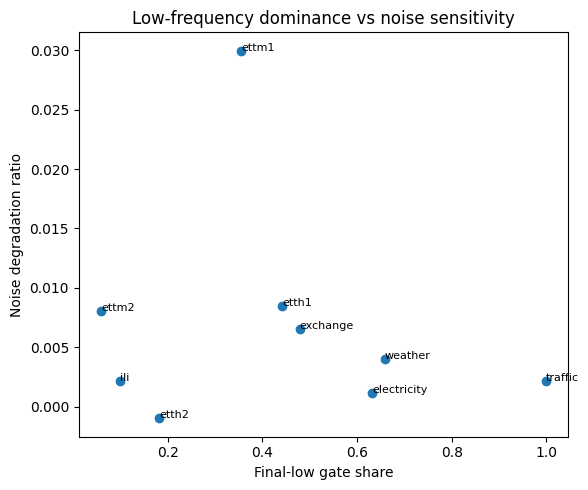

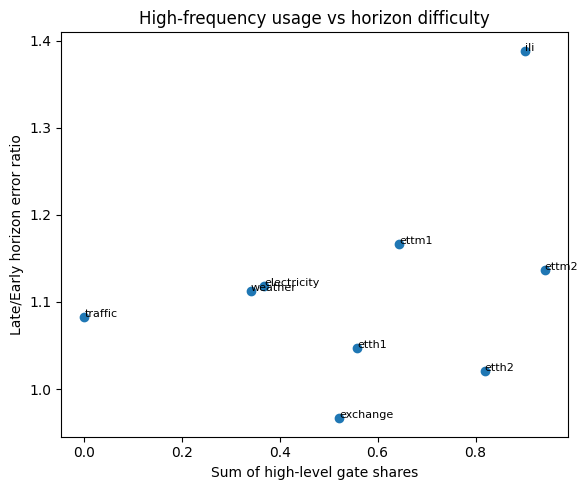

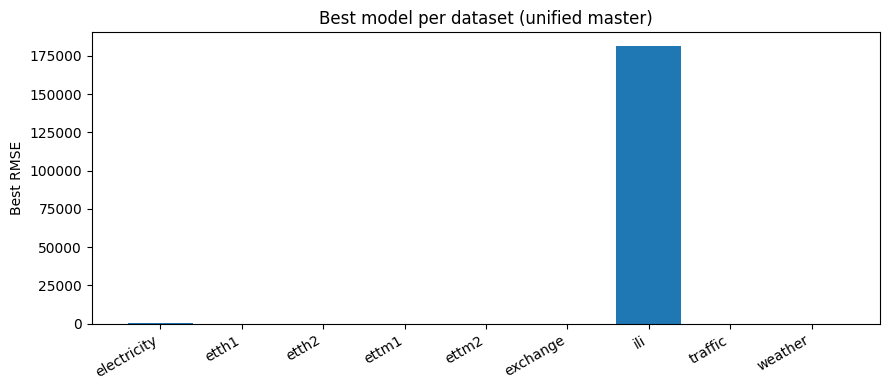


FINAL OUTPUT FILES
1. /data/Sajjan_Singh/spml/wavelet_seq_project/results/tables/master_all_models_metrics_unified.csv
2. /data/Sajjan_Singh/spml/wavelet_seq_project/results/tables/master_best_by_dataset_unified.csv
3. /data/Sajjan_Singh/spml/wavelet_seq_project/results/tables/phase4/summary_phase4_short_vs_long_rank.csv
4. /data/Sajjan_Singh/spml/wavelet_seq_project/results/tables/phase4/phase4_dataset_best_settings.csv
5. /data/Sajjan_Singh/spml/wavelet_seq_project/results/tables/phase4_phase6_regime_join.csv
6. /data/Sajjan_Singh/spml/wavelet_seq_project/results/figures/phase4_phase6/final_low_vs_noise_ratio.png
7. /data/Sajjan_Singh/spml/wavelet_seq_project/results/figures/phase4_phase6/high_share_vs_late_early_ratio.png


In [30]:
# ============================================
# FINAL POST-RUN CONSOLIDATION CELL
# Run this at the VERY END of 03_analysis_and_plots.ipynb
# ============================================

from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

ROOT = Path("/data/Sajjan_Singh/spml/wavelet_seq_project")
TABLES_ROOT = ROOT / "results" / "tables"
FIG_ROOT = ROOT / "results" / "figures" / "phase4_phase6"
FIG_ROOT.mkdir(parents=True, exist_ok=True)

MASTER_PATH = TABLES_ROOT / "master_all_models_metrics_unified.csv"
BEST_PATH = TABLES_ROOT / "master_best_by_dataset_unified.csv"
PHASE5_REGISTRY_PATH = TABLES_ROOT / "phase5" / "phase5_bestcfg_prediction_registry.csv"
PHASE4_MASTER_PATH = TABLES_ROOT / "phase4" / "phase4_master_metrics.csv"
PHASE6_DIR = TABLES_ROOT / "phase6"

required_files = [
    MASTER_PATH,
    PHASE5_REGISTRY_PATH,
    PHASE4_MASTER_PATH,
    PHASE6_DIR / "per_level_contribution.csv",
    PHASE6_DIR / "noise_robustness.csv",
    PHASE6_DIR / "horizon_wise_error.csv",
]

missing = [str(p) for p in required_files if not p.exists()]
if missing:
    raise FileNotFoundError(
        "These required files are missing. Finish the earlier steps first:\n" + "\n".join(missing)
    )

def mse(y, yhat):
    y = np.asarray(y, dtype=np.float64)
    yhat = np.asarray(yhat, dtype=np.float64)
    return float(np.mean((y - yhat) ** 2))

def mae(y, yhat):
    y = np.asarray(y, dtype=np.float64)
    yhat = np.asarray(yhat, dtype=np.float64)
    return float(np.mean(np.abs(y - yhat)))

def rmse(y, yhat):
    return float(np.sqrt(mse(y, yhat)))

def metric_row_from_npz(dataset, model, family, seq_len, pred_len, pred_file_rel):
    pred_path = ROOT / str(pred_file_rel)
    if not pred_path.exists():
        raise FileNotFoundError(f"Prediction file missing: {pred_path}")
    arr = np.load(pred_path, allow_pickle=True)
    preds = np.asarray(arr["preds"], dtype=np.float64).reshape(-1)
    trues = np.asarray(arr["trues"], dtype=np.float64).reshape(-1)

    return {
        "dataset": dataset,
        "model": model,
        "family": family,
        "seq_len": int(seq_len),
        "pred_len": int(pred_len),
        "test_mse": mse(trues, preds),
        "test_mae": mae(trues, preds),
        "test_rmse": rmse(trues, preds),
        "prediction_file": str(pred_file_rel),
    }

print("=" * 120)
print("STEP 1: Replace AdaptiveWaveletMixer rows in unified master with best-config Phase 5 rerun")
print("=" * 120)

master = pd.read_csv(MASTER_PATH)
phase5_registry = pd.read_csv(PHASE5_REGISTRY_PATH)

# Remove older AdaptiveWaveletMixer rows
master = master[master["model"] != "AdaptiveWaveletMixer"].copy()

new_rows = []
for _, r in phase5_registry.iterrows():
    new_rows.append(
        metric_row_from_npz(
            dataset=r["dataset"],
            model=r["model"],
            family=r["family"],
            seq_len=r["seq_len"],
            pred_len=r["pred_len"],
            pred_file_rel=r["prediction_file"],
        )
    )

new_phase5_df = pd.DataFrame(new_rows)
master = pd.concat([master, new_phase5_df], ignore_index=True)
master = master.sort_values(["dataset", "family", "model"]).reset_index(drop=True)
master.to_csv(MASTER_PATH, index=False)

best = (
    master.sort_values(["dataset", "test_rmse", "test_mae", "test_mse"])
          .groupby("dataset", as_index=False)
          .first()[["dataset", "model", "family", "test_mse", "test_mae", "test_rmse"]]
)
best.to_csv(BEST_PATH, index=False)

print("Updated:", MASTER_PATH)
print("Updated:", BEST_PATH)
display(best)

print("\n" + "=" * 120)
print("STEP 2: Build Phase 4 regime-wise summary tables using within-dataset ranks")
print("=" * 120)

phase4 = pd.read_csv(PHASE4_MASTER_PATH)
ok = phase4[phase4["status"].astype(str) == "ok"].copy()

def pick_col(df, candidates):
    for c in candidates:
        if c in df.columns:
            return c
    return None

study_col = pick_col(ok, ["study"])
rmse_col = pick_col(ok, ["test_rmse", "rmse"])
dataset_col = pick_col(ok, ["dataset"])

variant_col = pick_col(ok, ["decomposition_variant", "decomp_variant", "variant"])
level_col = pick_col(ok, ["levels", "level"])
family_col = pick_col(ok, ["wavelet_family", "family_name"])
location_col = pick_col(ok, ["decomposition_location", "decomp_location", "location"])
horizon_col = pick_col(ok, ["horizon_mode", "horizon"])
inputmode_col = pick_col(ok, ["input_mode", "mode"])
lookback_col = pick_col(ok, ["lookback_mode", "lookback"])
fusion_col = pick_col(ok, ["use_cross_scale_fusion", "cross_scale_fusion"])
reg_col = pick_col(ok, ["use_filter_regularization", "filter_regularization"])

if study_col is None or rmse_col is None or dataset_col is None:
    raise RuntimeError("Phase 4 master is missing required columns.")

PHASE4_DIR = TABLES_ROOT / "phase4"

def summarize_by_rank(df, factor_cols, out_name):
    factor_cols = [c for c in factor_cols if c is not None]
    if len(factor_cols) == 0 or len(df) == 0:
        print("Skipping", out_name, ": missing factor cols or empty df")
        return None

    best_local = (
        df.groupby([dataset_col] + factor_cols, as_index=False)[rmse_col]
          .min()
    )
    best_local["rank"] = best_local.groupby(dataset_col)[rmse_col].rank(method="average")

    out = (
        best_local.groupby(factor_cols, as_index=False)
                  .agg(
                      avg_rank=("rank", "mean"),
                      median_rank=("rank", "median"),
                      datasets_count=(dataset_col, "nunique"),
                  )
                  .sort_values(["avg_rank", "median_rank"])
                  .reset_index(drop=True)
    )

    out_path = PHASE4_DIR / out_name
    out.to_csv(out_path, index=False)
    print("Saved:", out_path)
    display(out)
    return out

phase4_summary_outputs = {}

if "decomposition_effect" in ok[study_col].unique():
    phase4_summary_outputs["decomposition_effect"] = summarize_by_rank(
        ok[ok[study_col] == "decomposition_effect"],
        [variant_col],
        "summary_phase4_decomposition_effect_rank.csv",
    )

if "levels_fixed" in ok[study_col].unique():
    tmp = ok[ok[study_col] == "levels_fixed"].copy()
    tmp["levels_type"] = "fixed"
    phase4_summary_outputs["levels_fixed"] = summarize_by_rank(
        tmp,
        ["levels_type", level_col],
        "summary_phase4_levels_fixed_rank.csv",
    )

if "levels_learnable" in ok[study_col].unique():
    tmp = ok[ok[study_col] == "levels_learnable"].copy()
    tmp["levels_type"] = "learnable"
    phase4_summary_outputs["levels_learnable"] = summarize_by_rank(
        tmp,
        ["levels_type", level_col],
        "summary_phase4_levels_learnable_rank.csv",
    )

if "families_fixed" in ok[study_col].unique():
    phase4_summary_outputs["families_fixed"] = summarize_by_rank(
        ok[ok[study_col] == "families_fixed"],
        [family_col],
        "summary_phase4_families_rank.csv",
    )

if "input_vs_inmodel" in ok[study_col].unique():
    phase4_summary_outputs["input_vs_inmodel"] = summarize_by_rank(
        ok[ok[study_col] == "input_vs_inmodel"],
        [location_col, variant_col],
        "summary_phase4_input_vs_inmodel_rank.csv",
    )

if "short_vs_long_horizon" in ok[study_col].unique():
    phase4_summary_outputs["short_vs_long_horizon"] = summarize_by_rank(
        ok[ok[study_col] == "short_vs_long_horizon"],
        [horizon_col, variant_col],
        "summary_phase4_short_vs_long_rank.csv",
    )

if "univariate_vs_multivariate" in ok[study_col].unique():
    phase4_summary_outputs["univariate_vs_multivariate"] = summarize_by_rank(
        ok[ok[study_col] == "univariate_vs_multivariate"],
        [inputmode_col, variant_col],
        "summary_phase4_uni_vs_multi_rank.csv",
    )

if "lookback_ablation" in ok[study_col].unique():
    phase4_summary_outputs["lookback_ablation"] = summarize_by_rank(
        ok[ok[study_col] == "lookback_ablation"],
        [lookback_col, variant_col],
        "summary_phase4_lookback_rank.csv",
    )

if "cross_scale_fusion" in ok[study_col].unique():
    phase4_summary_outputs["cross_scale_fusion"] = summarize_by_rank(
        ok[ok[study_col] == "cross_scale_fusion"],
        [fusion_col, variant_col],
        "summary_phase4_cross_scale_fusion_rank.csv",
    )

if "filter_regularization" in ok[study_col].unique():
    phase4_summary_outputs["filter_regularization"] = summarize_by_rank(
        ok[ok[study_col] == "filter_regularization"],
        [reg_col, variant_col],
        "summary_phase4_regularization_rank.csv",
    )

print("\n" + "=" * 120)
print("STEP 3: Build dataset-level Phase 4 best-settings table")
print("=" * 120)

dataset_best_rows = []

def best_per_dataset(df, factor_cols, label):
    factor_cols = [c for c in factor_cols if c is not None]
    if len(factor_cols) == 0 or len(df) == 0:
        return []

    best_local = (
        df.groupby([dataset_col] + factor_cols, as_index=False)[rmse_col]
          .min()
          .sort_values([dataset_col, rmse_col])
          .groupby(dataset_col, as_index=False)
          .first()
    )

    rows = []
    for _, r in best_local.iterrows():
        row = {
            "study": label,
            "dataset": r[dataset_col],
            "best_rmse": r[rmse_col],
        }
        for c in factor_cols:
            row[c] = r[c]
        rows.append(row)
    return rows

if "decomposition_effect" in ok[study_col].unique():
    dataset_best_rows += best_per_dataset(ok[ok[study_col] == "decomposition_effect"], [variant_col], "decomposition_effect")

if "short_vs_long_horizon" in ok[study_col].unique():
    dataset_best_rows += best_per_dataset(ok[ok[study_col] == "short_vs_long_horizon"], [horizon_col, variant_col], "short_vs_long_horizon")

if "univariate_vs_multivariate" in ok[study_col].unique():
    dataset_best_rows += best_per_dataset(ok[ok[study_col] == "univariate_vs_multivariate"], [inputmode_col, variant_col], "univariate_vs_multivariate")

if "families_fixed" in ok[study_col].unique():
    dataset_best_rows += best_per_dataset(ok[ok[study_col] == "families_fixed"], [family_col], "families_fixed")

phase4_dataset_best_df = pd.DataFrame(dataset_best_rows)
phase4_dataset_best_path = PHASE4_DIR / "phase4_dataset_best_settings.csv"
phase4_dataset_best_df.to_csv(phase4_dataset_best_path, index=False)

print("Saved:", phase4_dataset_best_path)
display(phase4_dataset_best_df.head(30))

print("\n" + "=" * 120)
print("STEP 4: Join Phase 4 and Phase 6 diagnostics")
print("=" * 120)

level_contrib = pd.read_csv(PHASE6_DIR / "per_level_contribution.csv")
noise = pd.read_csv(PHASE6_DIR / "noise_robustness.csv")
horizon = pd.read_csv(PHASE6_DIR / "horizon_wise_error.csv")

pivot = level_contrib.pivot(index="dataset", columns="component", values="avg_gate_weight").fillna(0.0)
pivot["final_low_share"] = pivot["final_low"] if "final_low" in pivot.columns else 0.0
high_cols = [c for c in pivot.columns if str(c).startswith("high_level_")]
pivot["high_share_sum"] = pivot[high_cols].sum(axis=1) if len(high_cols) > 0 else 0.0
pivot = pivot.reset_index()[["dataset", "final_low_share", "high_share_sum"]]

noise_rows = []
for ds in sorted(noise["dataset"].unique()):
    sub = noise[noise["dataset"] == ds].sort_values("noise_std")
    clean = sub[sub["noise_std"] == 0.0]
    worst = sub[sub["noise_std"] == sub["noise_std"].max()]
    if len(clean) == 0 or len(worst) == 0:
        continue
    clean_rmse = float(clean.iloc[0]["test_rmse"])
    worst_rmse = float(worst.iloc[0]["test_rmse"])
    ratio = (worst_rmse / clean_rmse - 1.0) if clean_rmse != 0 else np.nan
    noise_rows.append({
        "dataset": ds,
        "noise_degradation_ratio": ratio,
        "clean_rmse": clean_rmse,
        "worst_rmse": worst_rmse,
    })
noise_profile = pd.DataFrame(noise_rows)

h_rows = []
for ds in sorted(horizon["dataset"].unique()):
    sub = horizon[horizon["dataset"] == ds].sort_values("horizon_step")
    if len(sub) == 0:
        continue
    q = max(1, len(sub) // 4)
    early = float(sub.head(q)["mean_abs_error"].mean())
    late = float(sub.tail(q)["mean_abs_error"].mean())
    ratio = (late / early) if early != 0 else np.nan
    h_rows.append({
        "dataset": ds,
        "early_horizon_mae": early,
        "late_horizon_mae": late,
        "late_to_early_ratio": ratio,
    })
h_profile = pd.DataFrame(h_rows)

decomp_best = phase4_dataset_best_df[phase4_dataset_best_df["study"] == "decomposition_effect"].copy()

joined = best.merge(pivot, on="dataset", how="left")
joined = joined.merge(noise_profile, on="dataset", how="left")
joined = joined.merge(h_profile, on="dataset", how="left")
joined = joined.merge(decomp_best, on="dataset", how="left", suffixes=("", "_phase4"))

joined_path = TABLES_ROOT / "phase4_phase6_regime_join.csv"
joined.to_csv(joined_path, index=False)

print("Saved:", joined_path)
display(joined)

print("\n" + "=" * 120)
print("STEP 5: Create regime plots")
print("=" * 120)

plt.figure(figsize=(6, 5))
plt.scatter(joined["final_low_share"], joined["noise_degradation_ratio"])
for _, r in joined.iterrows():
    plt.text(r["final_low_share"], r["noise_degradation_ratio"], r["dataset"], fontsize=8)
plt.xlabel("Final-low gate share")
plt.ylabel("Noise degradation ratio")
plt.title("Low-frequency dominance vs noise sensitivity")
plt.tight_layout()
plt.savefig(FIG_ROOT / "final_low_vs_noise_ratio.png", dpi=200, bbox_inches="tight")
plt.show()

plt.figure(figsize=(6, 5))
plt.scatter(joined["high_share_sum"], joined["late_to_early_ratio"])
for _, r in joined.iterrows():
    plt.text(r["high_share_sum"], r["late_to_early_ratio"], r["dataset"], fontsize=8)
plt.xlabel("Sum of high-level gate shares")
plt.ylabel("Late/Early horizon error ratio")
plt.title("High-frequency usage vs horizon difficulty")
plt.tight_layout()
plt.savefig(FIG_ROOT / "high_share_vs_late_early_ratio.png", dpi=200, bbox_inches="tight")
plt.show()

plt.figure(figsize=(9, 4))
plt.bar(best["dataset"], best["test_rmse"])
plt.xticks(rotation=30, ha="right")
plt.ylabel("Best RMSE")
plt.title("Best model per dataset (unified master)")
plt.tight_layout()
plt.savefig(FIG_ROOT / "best_rmse_by_dataset.png", dpi=200, bbox_inches="tight")
plt.show()

print("\n" + "=" * 120)
print("FINAL OUTPUT FILES")
print("=" * 120)
print("1.", MASTER_PATH)
print("2.", BEST_PATH)
print("3.", PHASE4_DIR / "summary_phase4_short_vs_long_rank.csv")
print("4.", phase4_dataset_best_path)
print("5.", joined_path)
print("6.", FIG_ROOT / "final_low_vs_noise_ratio.png")
print("7.", FIG_ROOT / "high_share_vs_late_early_ratio.png")

In [1]:
# ============================================
# Merge PBT-bestcfg AdaptiveWaveletMixer into unified master
# ============================================

from pathlib import Path
import numpy as np
import pandas as pd

ROOT = Path("/data/Sajjan_Singh/spml/wavelet_seq_project")
TABLES_ROOT = ROOT / "results" / "tables"

MASTER_PATH = TABLES_ROOT / "master_all_models_metrics_unified.csv"
BEST_PATH = TABLES_ROOT / "master_best_by_dataset_unified.csv"
PBT_REGISTRY_PATH = TABLES_ROOT / "phase5" / "phase5_pbt_bestcfg_prediction_registry.csv"

def mse(y, yhat):
    y = np.asarray(y, dtype=np.float64)
    yhat = np.asarray(yhat, dtype=np.float64)
    return float(np.mean((y - yhat) ** 2))

def mae(y, yhat):
    y = np.asarray(y, dtype=np.float64)
    yhat = np.asarray(yhat, dtype=np.float64)
    return float(np.mean(np.abs(y - yhat)))

def rmse(y, yhat):
    return float(np.sqrt(mse(y, yhat)))

def metric_row_from_npz(dataset, model, family, seq_len, pred_len, pred_file_rel):
    p = ROOT / pred_file_rel
    arr = np.load(p, allow_pickle=True)
    preds = np.asarray(arr["preds"], dtype=np.float64).reshape(-1)
    trues = np.asarray(arr["trues"], dtype=np.float64).reshape(-1)
    return {
        "dataset": dataset,
        "model": model,
        "family": family,
        "seq_len": seq_len,
        "pred_len": pred_len,
        "test_mse": mse(trues, preds),
        "test_mae": mae(trues, preds),
        "test_rmse": rmse(trues, preds),
        "prediction_file": str(pred_file_rel),
    }

master = pd.read_csv(MASTER_PATH)

# Remove only older PBT-tagged rows if they exist
master = master[master["model"] != "AdaptiveWaveletMixer_PBT"].copy()

pbt_registry = pd.read_csv(PBT_REGISTRY_PATH)

new_rows = []
for _, r in pbt_registry.iterrows():
    new_rows.append(
        metric_row_from_npz(
            dataset=r["dataset"],
            model=r["model"],
            family=r["family"],
            seq_len=int(r["seq_len"]),
            pred_len=int(r["pred_len"]),
            pred_file_rel=r["prediction_file"],
        )
    )

new_df = pd.DataFrame(new_rows)
master = pd.concat([master, new_df], ignore_index=True)
master = master.sort_values(["dataset", "family", "model"]).reset_index(drop=True)
master.to_csv(MASTER_PATH, index=False)

best = (
    master.sort_values(["dataset", "test_rmse", "test_mae", "test_mse"])
          .groupby("dataset", as_index=False)
          .first()[["dataset", "model", "family", "test_mse", "test_mae", "test_rmse"]]
)
best.to_csv(BEST_PATH, index=False)

print("Updated:", MASTER_PATH)
print("Updated:", BEST_PATH)
display(best)

print("\nAdaptiveWaveletMixer_PBT rows:")
display(master[master["model"] == "AdaptiveWaveletMixer_PBT"])

Updated: /data/Sajjan_Singh/spml/wavelet_seq_project/results/tables/master_all_models_metrics_unified.csv
Updated: /data/Sajjan_Singh/spml/wavelet_seq_project/results/tables/master_best_by_dataset_unified.csv


,dataset,model,family,test_mse,test_mae,test_rmse
0,electricity,WPMixer,modern_tslib,6.725901e+04,182.292991,259.343429
1,etth1,WPMixer,modern_tslib,4.691051e+00,1.635539,2.165884
2,etth2,dlinear,neural_non_wavelet,1.748497e+01,3.192522,4.181504
3,ettm1,WPMixer,modern_tslib,2.339102e+00,1.147820,1.529412
4,ettm2,WPMixer,modern_tslib,8.495447e+00,2.109087,2.914695
5,exchange,naive,classical,7.954944e-04,0.021018,0.028205
6,ili,iTransformer,modern_tslib,3.287862e+10,125665.623324,181324.636078
7,traffic,dlinear,neural_non_wavelet,4.471525e-05,0.003913,0.006687
8,weather,WPMixer,modern_tslib,1.728212e+02,10.047792,13.146148



AdaptiveWaveletMixer_PBT rows:


,dataset,model,family,seq_len,pred_len,test_mse,test_mae,test_rmse,prediction_file
13,electricity,AdaptiveWaveletMixer_PBT,wavelet_adaptive,96,96,1.352682e+05,281.299042,367.788288,results/predictions/phase5_pbt_bestcfg/electri...
28,etth1,AdaptiveWaveletMixer_PBT,wavelet_adaptive,168,96,3.524466e+01,5.471652,5.936722,results/predictions/phase5_pbt_bestcfg/etth1_a...
43,etth2,AdaptiveWaveletMixer_PBT,wavelet_adaptive,48,96,2.971232e+02,16.156050,17.237263,results/predictions/phase5_pbt_bestcfg/etth2_a...
58,ettm1,AdaptiveWaveletMixer_PBT,wavelet_adaptive,96,96,8.019730e+00,2.265226,2.831913,results/predictions/phase5_pbt_bestcfg/ettm1_a...
73,ettm2,AdaptiveWaveletMixer_PBT,wavelet_adaptive,96,96,6.055625e+01,6.762586,7.781790,results/predictions/phase5_pbt_bestcfg/ettm2_a...
88,exchange,AdaptiveWaveletMixer_PBT,wavelet_adaptive,48,96,6.893003e-03,0.069369,0.083024,results/predictions/phase5_pbt_bestcfg/exchang...
103,ili,AdaptiveWaveletMixer_PBT,wavelet_adaptive,26,24,2.083620e+11,394317.718061,456466.894785,results/predictions/phase5_pbt_bestcfg/ili_ada...
118,traffic,AdaptiveWaveletMixer_PBT,wavelet_adaptive,96,96,8.554642e-05,0.006131,0.009249,results/predictions/phase5_pbt_bestcfg/traffic...
133,weather,AdaptiveWaveletMixer_PBT,wavelet_adaptive,96,96,7.672677e+02,22.467848,27.699598,results/predictions/phase5_pbt_bestcfg/weather...


In [1]:
from pathlib import Path
import pandas as pd

# =========================================================
# SETTINGS
# =========================================================
ROOT = Path("/data/Sajjan_Singh/spml/wavelet_seq_project")
SEARCH_DIR = ROOT / "results"
OUTPUT_CSV = ROOT / "results" / "tables" / "all_results_combined.csv"

# files to skip
EXCLUDE_NAMES = {
    OUTPUT_CSV.name,   # avoid reading the output itself if you rerun
}

# optional: skip already-made combined files to avoid duplication
EXCLUDE_KEYWORDS = [
    "all_results_combined",
]

# =========================================================
# FIND ALL CSV FILES
# =========================================================
csv_files = sorted(SEARCH_DIR.rglob("*.csv"))

filtered_files = []
for f in csv_files:
    if f.name in EXCLUDE_NAMES:
        continue
    if any(k.lower() in f.name.lower() for k in EXCLUDE_KEYWORDS):
        continue
    filtered_files.append(f)

print(f"Found {len(filtered_files)} CSV files")

if len(filtered_files) == 0:
    raise FileNotFoundError(f"No CSV files found inside: {SEARCH_DIR}")

# =========================================================
# READ AND COMBINE
# =========================================================
all_dfs = []
failed_files = []

for i, csv_path in enumerate(filtered_files, 1):
    try:
        df = pd.read_csv(csv_path, low_memory=False)

        # add source info so you know where each row came from
        df.insert(0, "__source_file", str(csv_path.relative_to(ROOT)))
        df.insert(1, "__source_name", csv_path.name)
        df.insert(2, "__source_folder", str(csv_path.parent.relative_to(ROOT)))

        all_dfs.append(df)
        print(f"[{i:03d}/{len(filtered_files)}] OK  -> {csv_path.relative_to(ROOT)} | rows={len(df)}")

    except Exception as e:
        failed_files.append((str(csv_path), str(e)))
        print(f"[{i:03d}/{len(filtered_files)}] FAIL -> {csv_path.relative_to(ROOT)} | {e}")

# combine sequentially (row-wise)
if len(all_dfs) == 0:
    raise RuntimeError("All CSV reads failed. Nothing to combine.")

combined_df = pd.concat(all_dfs, axis=0, ignore_index=True, sort=False)

# =========================================================
# SAVE
# =========================================================
OUTPUT_CSV.parent.mkdir(parents=True, exist_ok=True)
combined_df.to_csv(OUTPUT_CSV, index=False)

print("\n" + "=" * 80)
print("COMBINE DONE")
print("=" * 80)
print("Saved combined CSV to:", OUTPUT_CSV)
print("Total rows:", len(combined_df))
print("Total columns:", len(combined_df.columns))

if failed_files:
    failed_log = ROOT / "results" / "tables" / "all_results_combined_failed_files.csv"
    pd.DataFrame(failed_files, columns=["file", "error"]).to_csv(failed_log, index=False)
    print("\nSome files failed to read.")
    print("Failed file log saved to:", failed_log)

# optional preview
display(combined_df.head(20))

Found 127 CSV files
[001/127] OK  -> results/pbt_search/pbt_bestcfg_full_rerun_grid.csv | rows=9
[002/127] OK  -> results/pbt_search/pbt_bestcfg_full_rerun_grid_fixed.csv | rows=9
[003/127] OK  -> results/pbt_search/pbt_wavelet_search_all9/pbt_trainable_ecd46_00000_0_batch_div=1,d_model=128,dropout=0.0500,filter_reg_lambda=0.0010,gate_entropy_lambda=0.0010,grad_clip=0_2026-03-27_18-08-58/progress.csv | rows=2
[004/127] OK  -> results/pbt_search/pbt_wavelet_search_all9/pbt_trainable_ecd46_00001_1_batch_div=1,d_model=64,dropout=0.0500,filter_reg_lambda=0.0000,gate_entropy_lambda=0.0010,grad_clip=2._2026-03-27_18-08-58/progress.csv | rows=2
[005/127] OK  -> results/pbt_search/pbt_wavelet_search_all9/pbt_trainable_ecd46_00002_2_batch_div=1,d_model=128,dropout=0.1500,filter_reg_lambda=0.0000,gate_entropy_lambda=0.0000,grad_clip=0_2026-03-27_18-08-58/progress.csv | rows=2
[006/127] OK  -> results/pbt_search/pbt_wavelet_search_all9/pbt_trainable_ecd46_00003_3_batch_div=1,d_model=64,dropout=0.

,__source_file,__source_name,__source_folder,dataset,input_mode,horizon_mode,lookback_mode,wavelet_family,levels,d_model,...,mae,mse,rmse,mape,mspe,result_dir,metrics_file,pred_file,true_file,log_file
0,results/pbt_search/pbt_bestcfg_full_rerun_grid...,pbt_bestcfg_full_rerun_grid.csv,results/pbt_search,etth1,multivariate,long,searched,Haar,1.0,64.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,results/pbt_search/pbt_bestcfg_full_rerun_grid...,pbt_bestcfg_full_rerun_grid.csv,results/pbt_search,etth2,multivariate,long,searched,Haar,1.0,64.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,results/pbt_search/pbt_bestcfg_full_rerun_grid...,pbt_bestcfg_full_rerun_grid.csv,results/pbt_search,ettm1,multivariate,long,searched,Haar,1.0,64.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,results/pbt_search/pbt_bestcfg_full_rerun_grid...,pbt_bestcfg_full_rerun_grid.csv,results/pbt_search,ettm2,multivariate,long,searched,Haar,1.0,64.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,results/pbt_search/pbt_bestcfg_full_rerun_grid...,pbt_bestcfg_full_rerun_grid.csv,results/pbt_search,weather,multivariate,long,searched,Haar,1.0,64.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,results/pbt_search/pbt_bestcfg_full_rerun_grid...,pbt_bestcfg_full_rerun_grid.csv,results/pbt_search,electricity,multivariate,long,searched,Haar,1.0,64.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,results/pbt_search/pbt_bestcfg_full_rerun_grid...,pbt_bestcfg_full_rerun_grid.csv,results/pbt_search,traffic,multivariate,long,searched,Haar,1.0,64.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7,results/pbt_search/pbt_bestcfg_full_rerun_grid...,pbt_bestcfg_full_rerun_grid.csv,results/pbt_search,exchange,multivariate,long,searched,Haar,1.0,64.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
8,results/pbt_search/pbt_bestcfg_full_rerun_grid...,pbt_bestcfg_full_rerun_grid.csv,results/pbt_search,ili,multivariate,long,searched,Haar,1.0,64.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9,results/pbt_search/pbt_bestcfg_full_rerun_grid...,pbt_bestcfg_full_rerun_grid_fixed.csv,results/pbt_search,etth1,multivariate,long,searched,Db2,3.0,64.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [2]:
from pathlib import Path
from PIL import Image, ImageOps, ImageDraw, ImageFont
import pandas as pd

# =========================================================
# SETTINGS
# =========================================================
ROOT = Path("/data/Sajjan_Singh/spml/wavelet_seq_project")
SEARCH_DIR = ROOT / "results"
OUTPUT_PDF = ROOT / "results" / "figures" / "all_figures_combined.pdf"
FAILED_LOG = ROOT / "results" / "figures" / "all_figures_failed_files.csv"

IMAGE_EXTS = {".png", ".jpg", ".jpeg", ".webp", ".bmp", ".tif", ".tiff"}

# optional: skip output file folder if needed
EXCLUDE_KEYWORDS = [
    "all_figures_combined",
]

# page settings
PAGE_WIDTH = 1600
PAGE_MARGIN = 60
TITLE_HEIGHT = 80
BG_COLOR = "white"
TEXT_COLOR = "black"

# =========================================================
# FIND ALL IMAGE FILES
# =========================================================
all_files = sorted(SEARCH_DIR.rglob("*"))
image_files = []

for f in all_files:
    if not f.is_file():
        continue
    if f.suffix.lower() not in IMAGE_EXTS:
        continue
    if any(k.lower() in str(f).lower() for k in EXCLUDE_KEYWORDS):
        continue
    image_files.append(f)

print(f"Found {len(image_files)} figure/image files")

if len(image_files) == 0:
    raise FileNotFoundError(f"No image files found inside: {SEARCH_DIR}")

# =========================================================
# FONT
# =========================================================
try:
    font = ImageFont.truetype("/usr/share/fonts/truetype/dejavu/DejaVuSans.ttf", 28)
except:
    font = ImageFont.load_default()

# =========================================================
# MAKE EACH IMAGE INTO ONE PDF PAGE
# =========================================================
pdf_pages = []
failed_files = []

for i, img_path in enumerate(image_files, 1):
    try:
        img = Image.open(img_path).convert("RGB")

        # resize to fit page width
        usable_width = PAGE_WIDTH - 2 * PAGE_MARGIN
        scale = usable_width / img.width
        new_w = int(img.width * scale)
        new_h = int(img.height * scale)

        img_resized = img.resize((new_w, new_h), Image.LANCZOS)

        page_height = TITLE_HEIGHT + new_h + 2 * PAGE_MARGIN
        page = Image.new("RGB", (PAGE_WIDTH, page_height), BG_COLOR)

        draw = ImageDraw.Draw(page)
        title = str(img_path.relative_to(ROOT))

        # draw title
        draw.text((PAGE_MARGIN, 20), title, fill=TEXT_COLOR, font=font)

        # paste image
        x = (PAGE_WIDTH - new_w) // 2
        y = TITLE_HEIGHT
        page.paste(img_resized, (x, y))

        pdf_pages.append(page)
        print(f"[{i:03d}/{len(image_files)}] OK  -> {img_path.relative_to(ROOT)}")

    except Exception as e:
        failed_files.append((str(img_path), str(e)))
        print(f"[{i:03d}/{len(image_files)}] FAIL -> {img_path.relative_to(ROOT)} | {e}")

# =========================================================
# SAVE PDF
# =========================================================
if len(pdf_pages) == 0:
    raise RuntimeError("No valid images could be converted into PDF pages.")

OUTPUT_PDF.parent.mkdir(parents=True, exist_ok=True)

first_page = pdf_pages[0]
rest_pages = pdf_pages[1:]

first_page.save(
    OUTPUT_PDF,
    "PDF",
    resolution=100.0,
    save_all=True,
    append_images=rest_pages,
)

print("\n" + "=" * 80)
print("DONE")
print("=" * 80)
print("Saved combined figure PDF to:", OUTPUT_PDF)
print("Total pages:", len(pdf_pages))

if failed_files:
    pd.DataFrame(failed_files, columns=["file", "error"]).to_csv(FAILED_LOG, index=False)
    print("Some files failed.")
    print("Failed file log saved to:", FAILED_LOG)

Found 112 figure/image files
[001/112] OK  -> results/figures/analysis/avg_metrics_by_broad_group.png
[002/112] OK  -> results/figures/analysis/avg_metrics_by_wavelet_flag.png
[003/112] OK  -> results/figures/analysis/best_rmse_by_dataset_and_broad_group.png
[004/112] OK  -> results/figures/analysis/model_rank_heatmap.png
[005/112] OK  -> results/figures/analysis/wavelet_vs_nonwavelet_rmse_delta.png
[006/112] OK  -> results/figures/analysis/wins_by_broad_group.png
[007/112] OK  -> results/figures/analysis/wins_by_model.png
[008/112] OK  -> results/figures/phase4/cross_scale_fusion_rmse.png
[009/112] OK  -> results/figures/phase4/decomposition_effect_rmse.png
[010/112] OK  -> results/figures/phase4/families_fixed_rmse.png
[011/112] OK  -> results/figures/phase4/filter_regularization_rmse.png
[012/112] OK  -> results/figures/phase4/horizon_fixed_rmse.png
[013/112] OK  -> results/figures/phase4/horizon_learnable_rmse.png
[014/112] OK  -> results/figures/phase4/horizon_none_rmse.png
[015/1

In [3]:
from pathlib import Path
import json
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# =========================================================
# SETTINGS
# =========================================================
ROOT = Path("/data/Sajjan_Singh/spml/wavelet_seq_project")
TABLES_DIR = ROOT / "results" / "tables"
FIGS_DIR = ROOT / "results" / "figures" / "paper_cleanup"
OUT_DIR = ROOT / "results" / "tables" / "paper_cleanup"

OUT_DIR.mkdir(parents=True, exist_ok=True)
FIGS_DIR.mkdir(parents=True, exist_ok=True)

MASTER_CANDIDATES = [
    TABLES_DIR / "master_all_models_metrics_unified.csv",
    TABLES_DIR / "master_all_models_metrics_unified_dbloss_candidate.csv",
    TABLES_DIR / "master_all_models_metrics_unified_lookback_candidate.csv",
]

DATA_PREP_SUMMARY = TABLES_DIR / "data_preparation_summary.csv"

# If you used multiple seeds later, add them here or let code detect a seed column.
DEFAULT_SEEDS = [42]

# Manual defaults for appendix table if some settings are missing from csvs
MANUAL_VARIANT_DEFAULTS = {
    "AdaptiveWaveletMixer": {
        "levels": 2,
        "wavelet_family": "Db4",
        "d_model": 128,
        "num_backbone_blocks": 2,
        "dropout": 0.10,
        "notes": "best ablation baseline"
    },
    "AdaptiveWaveletMixer_PBT": {
        "notes": "PBT-searched variant; fill any missing settings from pbt log/checkpoint if needed"
    },
    "AdaptiveWaveletMixer_DBLoss": {
        "levels": 2,
        "wavelet_family": "Db4",
        "d_model": 128,
        "num_backbone_blocks": 2,
        "notes": "DBLoss full run variant"
    },
    "AdaptiveWaveletMixer_AdaptiveLookback": {
        "levels": 2,
        "wavelet_family": "Db4",
        "d_model": 128,
        "num_backbone_blocks": 2,
        "notes": "adaptive lookback full run variant"
    },
}

# Bootstrap settings
N_BOOT = 5000
RNG = np.random.default_rng(42)

# =========================================================
# HELPERS
# =========================================================
def pick_master():
    for p in MASTER_CANDIDATES:
        if p.exists():
            return p
    raise FileNotFoundError("No master metrics file found in expected locations.")

def safe_read_csv(path):
    try:
        return pd.read_csv(path, low_memory=False)
    except Exception as e:
        print(f"[WARN] Could not read {path}: {e}")
        return None

def first_non_null(series):
    series = series.dropna()
    return series.iloc[0] if len(series) else np.nan

def normalize_colnames(df):
    df = df.copy()
    df.columns = [str(c).strip() for c in df.columns]
    rename_map = {
        "mse": "test_mse",
        "mae": "test_mae",
        "rmse": "test_rmse",
    }
    for old, new in rename_map.items():
        if old in df.columns and new not in df.columns:
            df = df.rename(columns={old: new})
    return df

def model_norm(x):
    return str(x).strip().lower()

def family_label(model_name):
    m = model_norm(model_name)

    # wavelet-based / decomposition-based
    if any(k in m for k in [
        "wpmixer",
        "wavelet",
        "fixed_dwt",
        "dwt",
        "mlstm_reproduced",
        "mwdn",
    ]):
        return "wavelet"

    # clearly non-wavelet
    if any(k in m for k in [
        "naive",
        "seasonal_naive",
        "dlinear",
        "lstm",
        "gru",
        "autoformer",
        "fedformer",
        "timesnet",
        "itransformer",
        "timemixer",
        "patchtst",
        "arima",
        "ets",
    ]):
        return "non_wavelet"

    return "unknown"

def detailed_family_label(model_name):
    m = model_norm(model_name)

    if any(k in m for k in ["naive", "seasonal_naive", "arima", "ets"]):
        return "classical"
    if any(k in m for k in ["lstm", "gru", "dlinear"]):
        return "neural_non_wavelet"
    if any(k in m for k in ["autoformer", "fedformer", "timesnet", "itransformer", "timemixer", "patchtst"]):
        return "modern_tslib_non_wavelet"
    if any(k in m for k in ["wpmixer", "wavelet", "fixed_dwt", "dwt", "mlstm_reproduced", "mwdn"]):
        return "wavelet_based"
    return "unknown"

def bootstrap_mean_ci(x, n_boot=5000, alpha=0.05):
    x = np.asarray(x, dtype=float)
    x = x[np.isfinite(x)]
    if len(x) == 0:
        return np.nan, np.nan, np.nan
    means = []
    for _ in range(n_boot):
        sample = RNG.choice(x, size=len(x), replace=True)
        means.append(sample.mean())
    lo = np.percentile(means, 100 * (alpha / 2))
    hi = np.percentile(means, 100 * (1 - alpha / 2))
    return float(x.mean()), float(lo), float(hi)

def bootstrap_rate_ci(binary_vals, n_boot=5000, alpha=0.05):
    x = np.asarray(binary_vals, dtype=float)
    x = x[np.isfinite(x)]
    if len(x) == 0:
        return np.nan, np.nan, np.nan
    rates = []
    for _ in range(n_boot):
        sample = RNG.choice(x, size=len(x), replace=True)
        rates.append(sample.mean())
    lo = np.percentile(rates, 100 * (alpha / 2))
    hi = np.percentile(rates, 100 * (1 - alpha / 2))
    return float(x.mean()), float(lo), float(hi)

# =========================================================
# LOAD MASTER + METADATA FROM ALL METRICS FILES
# =========================================================
master_path = pick_master()
master = safe_read_csv(master_path)
if master is None:
    raise RuntimeError("Could not read master metrics file.")

master = normalize_colnames(master)

if "dataset" not in master.columns or "model" not in master.columns:
    raise RuntimeError("Master table must contain at least dataset and model columns.")

master["model_norm"] = master["model"].map(model_norm)

# Read all metrics-like CSVs to enrich pred_len / seq_len / settings
meta_files = sorted(TABLES_DIR.rglob("*.csv"))
meta_frames = []

for f in meta_files:
    fname = f.name.lower()
    if "combined" in fname:
        continue
    if "failed" in fname:
        continue
    if "history" in fname:
        continue
    if "summary" in fname and "data_preparation_summary" not in fname:
        # summary tables often do not have row-level metadata; skip for enrichment
        continue

    df = safe_read_csv(f)
    if df is None:
        continue
    df = normalize_colnames(df)

    if "dataset" in df.columns and "model" in df.columns:
        df["model_norm"] = df["model"].map(model_norm)
        df["__src"] = str(f.relative_to(ROOT))
        meta_frames.append(df)

meta = pd.concat(meta_frames, ignore_index=True, sort=False) if meta_frames else pd.DataFrame()

# Aggregate metadata by dataset + model_norm
meta_keep_cols = [c for c in [
    "dataset", "model_norm", "family", "seq_len", "pred_len", "batch_size",
    "epochs_target", "best_epoch", "levels", "wavelet_family", "d_model",
    "num_backbone_blocks", "dropout", "train_epochs", "patience",
    "learning_rate", "use_amp", "status"
] if c in meta.columns]

if len(meta_keep_cols) > 0:
    meta_agg = (
        meta[meta_keep_cols]
        .groupby(["dataset", "model_norm"], as_index=False)
        .agg(lambda s: first_non_null(s))
    )
    master = master.merge(meta_agg, on=["dataset", "model_norm"], how="left", suffixes=("", "_meta"))

# Add corrected labels
master["wavelet_label_corrected"] = master["model"].map(family_label)
master["family_label_corrected"] = master["model"].map(detailed_family_label)

corrected_master_csv = OUT_DIR / "master_metrics_corrected_labels.csv"
master.to_csv(corrected_master_csv, index=False)

print("Saved:", corrected_master_csv)

# =========================================================
# ONE-PAGE EXPERIMENTAL PROTOCOL SHEET
# =========================================================
protocol_md = OUT_DIR / "experimental_protocol_sheet.md"

prep_lines = []
if DATA_PREP_SUMMARY.exists():
    prep_df = safe_read_csv(DATA_PREP_SUMMARY)
    if prep_df is not None:
        prep_lines.append("## Dataset splits")
        keep_cols = [c for c in [
            "dataset", "rows", "train_rows", "val_rows", "test_rows",
            "frequency", "target", "date_start", "date_end"
        ] if c in prep_df.columns]
        if keep_cols:
            prep_lines.append(prep_df[keep_cols].to_markdown(index=False))

# Common horizon check
pred_lens = master["pred_len"].dropna().astype(int) if "pred_len" in master.columns else pd.Series(dtype=int)
if len(pred_lens):
    common_pred_len = int(pred_lens.mode().iloc[0])
else:
    common_pred_len = None

protocol_text = f"""# Experimental Protocol Sheet

## Master file used
- `{master_path.relative_to(ROOT)}`

## Split strategy
- Fixed train / validation / test splits from the prepared pipeline.
- If `data_preparation_summary.csv` is correct, use those exact split sizes in the paper.
- No random resplitting should be claimed unless a different pipeline was actually used.

## Scaler fitting
- The manuscript should explicitly state that standardization / scaling parameters are fit on the **training split only**.
- This is a critical reviewer-facing statement.
- If your `01_data_preparation.ipynb` does something different, update the manuscript and this sheet.

## Seeds
- Detected seeds in tables: {sorted(master['seed'].dropna().unique().tolist()) if 'seed' in master.columns and master['seed'].notna().any() else DEFAULT_SEEDS}
- If most experiments are single-seed, clearly state that and report it as a limitation.

## Horizons
- Common / modal prediction horizon detected from merged tables: {common_pred_len if common_pred_len is not None else 'NOT DETECTED'}
- ILI should only appear in the main comparison table if it is evaluated at the same horizon setting as the other datasets in that table.

## Metric scale
- Cross-dataset raw RMSE/MAE/MSE are **not directly comparable** because datasets differ in scale.
- Use:
  1. within-dataset ranks,
  2. same-horizon comparisons,
  3. optionally normalized ratios (model / best-baseline) for cross-dataset discussion.

## Reviewer checklist
- [ ] train-only scaler fitting explicitly stated
- [ ] same-horizon comparison explicitly stated
- [ ] single-seed or multi-seed status explicitly stated
- [ ] raw-scale vs normalized/rank-based comparison clearly separated

{chr(10).join(prep_lines)}
"""

protocol_md.write_text(protocol_text, encoding="utf-8")
print("Saved:", protocol_md)

# =========================================================
# CONFIDENCE INTERVALS OR MULTI-SEED SUMMARIES
# =========================================================
ci_csv = OUT_DIR / "confidence_or_multiseed_summary.csv"

if "seed" in master.columns and master["seed"].notna().any():
    seed_summary = (
        master.groupby(["dataset", "model", "wavelet_label_corrected"], as_index=False)
        .agg(
            n_seeds=("seed", "nunique"),
            mean_rmse=("test_rmse", "mean"),
            std_rmse=("test_rmse", "std"),
            mean_mae=("test_mae", "mean"),
            std_mae=("test_mae", "std"),
            mean_mse=("test_mse", "mean"),
            std_mse=("test_mse", "std"),
        )
    )
    seed_summary.to_csv(ci_csv, index=False)
    print("Saved multi-seed summary:", ci_csv)
else:
    # Dataset-level bootstrap CI for wavelet-vs-non-wavelet comparison
    # Use best wavelet and best non-wavelet per dataset at same pred_len when possible
    work = master.copy()
    if common_pred_len is not None and "pred_len" in work.columns:
        work = work[work["pred_len"] == common_pred_len].copy()

    best_wave = (
        work[work["wavelet_label_corrected"] == "wavelet"]
        .sort_values(["dataset", "test_rmse", "test_mae", "test_mse"])
        .groupby("dataset", as_index=False)
        .first()[["dataset", "model", "test_rmse"]]
        .rename(columns={"model": "best_wavelet_model", "test_rmse": "best_wavelet_rmse"})
    )

    best_nonwave = (
        work[work["wavelet_label_corrected"] == "non_wavelet"]
        .sort_values(["dataset", "test_rmse", "test_mae", "test_mse"])
        .groupby("dataset", as_index=False)
        .first()[["dataset", "model", "test_rmse"]]
        .rename(columns={"model": "best_nonwave_model", "test_rmse": "best_nonwave_rmse"})
    )

    pair = best_wave.merge(best_nonwave, on="dataset", how="inner")
    pair["delta_rmse"] = pair["best_nonwave_rmse"] - pair["best_wavelet_rmse"]   # >0 => wavelet better
    pair["wavelet_win"] = (pair["delta_rmse"] > 0).astype(int)

    mean_delta, lo_delta, hi_delta = bootstrap_mean_ci(pair["delta_rmse"].values, n_boot=N_BOOT)
    win_rate, lo_rate, hi_rate = bootstrap_rate_ci(pair["wavelet_win"].values, n_boot=N_BOOT)

    ci_df = pd.DataFrame([
        {
            "comparison": "best_wavelet_vs_best_nonwavelet_same_horizon",
            "n_datasets": len(pair),
            "mean_delta_rmse": mean_delta,
            "delta_rmse_ci_low": lo_delta,
            "delta_rmse_ci_high": hi_delta,
            "wavelet_win_rate": win_rate,
            "wavelet_win_rate_ci_low": lo_rate,
            "wavelet_win_rate_ci_high": hi_rate,
            "note": "Single-seed project; this is a dataset-level bootstrap CI, not a multi-seed CI."
        }
    ])
    ci_df.to_csv(ci_csv, index=False)
    print("Saved bootstrap CI summary:", ci_csv)

# =========================================================
# CLEAN MAIN TABLE WITH ILI HORIZON FIX
# =========================================================
main_table_csv = OUT_DIR / "main_table_common_horizon.csv"
main_note_md = OUT_DIR / "main_table_horizon_note.md"

work = master.copy()
if common_pred_len is not None and "pred_len" in work.columns:
    work = work[work["pred_len"] == common_pred_len].copy()

main_best = (
    work.sort_values(["dataset", "test_rmse", "test_mae", "test_mse"])
    .groupby("dataset", as_index=False)
    .first()
)

main_cols = [c for c in [
    "dataset", "model", "family", "family_label_corrected", "wavelet_label_corrected",
    "seq_len", "pred_len", "test_mse", "test_mae", "test_rmse"
] if c in main_best.columns]

main_best = main_best[main_cols].copy()
main_best.to_csv(main_table_csv, index=False)

ili_rows_all = master[master["dataset"].astype(str).str.lower() == "ili"].copy()
ili_rows_main = main_best[main_best["dataset"].astype(str).str.lower() == "ili"].copy()

main_note = f"""# Main Table Horizon Note

- Common prediction horizon used for the clean main table: {common_pred_len if common_pred_len is not None else 'NOT DETECTED'}

## ILI status
- ILI rows in full merged master: {len(ili_rows_all)}
- ILI rows in clean main table: {len(ili_rows_main)}

## Interpretation
- If ILI is absent from the clean main table, it means no ILI row matched the common horizon used for the other datasets.
- In that case, do NOT compare ILI directly against the other datasets in the main table.
- Put ILI either:
  1. in a separate table, or
  2. in an appendix with its own matched-horizon comparison.
"""
main_note_md.write_text(main_note, encoding="utf-8")

print("Saved:", main_table_csv)
print("Saved:", main_note_md)

# =========================================================
# REGENERATED WAVELET-VS-NON-WAVELET FIGURES
# =========================================================
fig1 = FIGS_DIR / "wavelet_vs_nonwavelet_best_rmse_ratio.png"
fig2 = FIGS_DIR / "wavelet_vs_nonwavelet_rank_boxplot.png"

plot_df = work.copy()

# Figure 1: best wavelet vs best non-wavelet rmse ratio by dataset
best_wave = (
    plot_df[plot_df["wavelet_label_corrected"] == "wavelet"]
    .sort_values(["dataset", "test_rmse", "test_mae", "test_mse"])
    .groupby("dataset", as_index=False)
    .first()[["dataset", "model", "test_rmse"]]
    .rename(columns={"model": "best_wavelet_model", "test_rmse": "best_wavelet_rmse"})
)
best_nonwave = (
    plot_df[plot_df["wavelet_label_corrected"] == "non_wavelet"]
    .sort_values(["dataset", "test_rmse", "test_mae", "test_mse"])
    .groupby("dataset", as_index=False)
    .first()[["dataset", "model", "test_rmse"]]
    .rename(columns={"model": "best_nonwave_model", "test_rmse": "best_nonwave_rmse"})
)
ratio_df = best_wave.merge(best_nonwave, on="dataset", how="inner")
ratio_df["wavelet_over_nonwave_rmse_ratio"] = ratio_df["best_wavelet_rmse"] / ratio_df["best_nonwave_rmse"]

plt.figure(figsize=(11, 6))
ratio_df = ratio_df.sort_values("wavelet_over_nonwave_rmse_ratio")
plt.bar(ratio_df["dataset"], ratio_df["wavelet_over_nonwave_rmse_ratio"])
plt.axhline(1.0, linestyle="--")
plt.ylabel("Best wavelet RMSE / best non-wavelet RMSE")
plt.xlabel("Dataset")
plt.title("Wavelet vs non-wavelet after corrected labels")
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig(fig1, dpi=200, bbox_inches="tight")
plt.close()

# Figure 2: within-dataset ranks by label
rank_df = plot_df.copy()
rank_df = rank_df.dropna(subset=["test_rmse"])
rank_df["within_dataset_rank"] = rank_df.groupby("dataset")["test_rmse"].rank(method="average", ascending=True)

wave_ranks = rank_df.loc[rank_df["wavelet_label_corrected"] == "wavelet", "within_dataset_rank"].values
nonwave_ranks = rank_df.loc[rank_df["wavelet_label_corrected"] == "non_wavelet", "within_dataset_rank"].values

plt.figure(figsize=(8, 6))
plt.boxplot([wave_ranks, nonwave_ranks], labels=["wavelet", "non_wavelet"], showmeans=True)
plt.ylabel("Within-dataset rank (lower is better)")
plt.title("Corrected wavelet vs non-wavelet rank distribution")
plt.tight_layout()
plt.savefig(fig2, dpi=200, bbox_inches="tight")
plt.close()

ratio_df.to_csv(OUT_DIR / "wavelet_vs_nonwavelet_best_rmse_ratio_table.csv", index=False)
rank_df.to_csv(OUT_DIR / "wavelet_vs_nonwavelet_rank_table.csv", index=False)

print("Saved:", fig1)
print("Saved:", fig2)

# =========================================================
# APPENDIX TABLE FOR ADAPTIVEWAVELETMIXER / PBT / DBLOSS / ADAPTIVELOOKBACK
# =========================================================
appendix_csv = OUT_DIR / "appendix_settings_table.csv"

# Gather rows from all csvs that may mention these variants
all_csvs = sorted(TABLES_DIR.rglob("*.csv"))
variant_rows = []

for f in all_csvs:
    if "failed" in f.name.lower():
        continue
    df = safe_read_csv(f)
    if df is None:
        continue
    df = normalize_colnames(df)
    if "model" not in df.columns:
        continue

    for _, r in df.iterrows():
        m = model_norm(r["model"])
        variant = None

        if "adaptivewaveletmixer_pbt" in m or "pbt" in m:
            variant = "AdaptiveWaveletMixer_PBT"
        elif "adaptivewaveletmixer_dbloss" in m or "dbloss" in m:
            variant = "AdaptiveWaveletMixer_DBLoss"
        elif "adaptivewaveletmixer_adaptivelookback" in m or "adaptivelookback" in m:
            variant = "AdaptiveWaveletMixer_AdaptiveLookback"
        elif "adaptivewaveletmixer" in m:
            variant = "AdaptiveWaveletMixer"

        if variant is not None:
            row = {
                "variant": variant,
                "source_file": str(f.relative_to(ROOT)),
                "dataset": r.get("dataset", np.nan),
                "model": r.get("model", np.nan),
                "seq_len": r.get("seq_len", np.nan),
                "pred_len": r.get("pred_len", np.nan),
                "batch_size": r.get("batch_size", np.nan),
                "epochs_target": r.get("epochs_target", r.get("train_epochs", np.nan)),
                "best_epoch": r.get("best_epoch", np.nan),
                "levels": r.get("levels", np.nan),
                "wavelet_family": r.get("wavelet_family", np.nan),
                "d_model": r.get("d_model", np.nan),
                "num_backbone_blocks": r.get("num_backbone_blocks", np.nan),
                "dropout": r.get("dropout", np.nan),
                "learning_rate": r.get("learning_rate", np.nan),
                "use_amp": r.get("use_amp", np.nan),
                "status": r.get("status", np.nan),
            }
            variant_rows.append(row)

variant_df = pd.DataFrame(variant_rows)

summary_rows = []
for variant in [
    "AdaptiveWaveletMixer",
    "AdaptiveWaveletMixer_PBT",
    "AdaptiveWaveletMixer_DBLoss",
    "AdaptiveWaveletMixer_AdaptiveLookback",
]:
    sub = variant_df[variant_df["variant"] == variant].copy()

    row = {
        "variant": variant,
        "datasets_seen": ", ".join(sorted(sub["dataset"].dropna().astype(str).unique().tolist())) if len(sub) else "",
        "seq_len_values": ", ".join(sorted(set(map(str, sub["seq_len"].dropna().tolist())))) if "seq_len" in sub.columns and len(sub) else "",
        "pred_len_values": ", ".join(sorted(set(map(str, sub["pred_len"].dropna().tolist())))) if "pred_len" in sub.columns and len(sub) else "",
        "batch_size_values": ", ".join(sorted(set(map(str, sub["batch_size"].dropna().tolist())))) if "batch_size" in sub.columns and len(sub) else "",
        "epochs_target_values": ", ".join(sorted(set(map(str, sub["epochs_target"].dropna().tolist())))) if "epochs_target" in sub.columns and len(sub) else "",
        "levels": first_non_null(sub["levels"]) if "levels" in sub.columns and len(sub) else np.nan,
        "wavelet_family": first_non_null(sub["wavelet_family"]) if "wavelet_family" in sub.columns and len(sub) else np.nan,
        "d_model": first_non_null(sub["d_model"]) if "d_model" in sub.columns and len(sub) else np.nan,
        "num_backbone_blocks": first_non_null(sub["num_backbone_blocks"]) if "num_backbone_blocks" in sub.columns and len(sub) else np.nan,
        "dropout": first_non_null(sub["dropout"]) if "dropout" in sub.columns and len(sub) else np.nan,
        "learning_rate": first_non_null(sub["learning_rate"]) if "learning_rate" in sub.columns and len(sub) else np.nan,
        "use_amp": first_non_null(sub["use_amp"]) if "use_amp" in sub.columns and len(sub) else np.nan,
        "notes": "",
    }

    # fill missing from manual defaults
    defaults = MANUAL_VARIANT_DEFAULTS.get(variant, {})
    for k, v in defaults.items():
        if (k not in row) or (pd.isna(row[k]) or row[k] == ""):
            row[k] = v

    summary_rows.append(row)

appendix_df = pd.DataFrame(summary_rows)
appendix_df.to_csv(appendix_csv, index=False)

print("Saved:", appendix_csv)

# =========================================================
# QUICK PREVIEW
# =========================================================
print("\n" + "=" * 90)
print("DONE")
print("=" * 90)
print("Outputs written to:")
print(" -", OUT_DIR)
print(" -", FIGS_DIR)

display(main_best.head(20))
display(appendix_df)

Saved: /data/Sajjan_Singh/spml/wavelet_seq_project/results/tables/paper_cleanup/master_metrics_corrected_labels.csv
Saved: /data/Sajjan_Singh/spml/wavelet_seq_project/results/tables/paper_cleanup/experimental_protocol_sheet.md
Saved bootstrap CI summary: /data/Sajjan_Singh/spml/wavelet_seq_project/results/tables/paper_cleanup/confidence_or_multiseed_summary.csv
Saved: /data/Sajjan_Singh/spml/wavelet_seq_project/results/tables/paper_cleanup/main_table_common_horizon.csv
Saved: /data/Sajjan_Singh/spml/wavelet_seq_project/results/tables/paper_cleanup/main_table_horizon_note.md


/tmp/ipykernel_3046977/3698249100.py:466: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([wave_ranks, nonwave_ranks], labels=["wavelet", "non_wavelet"], showmeans=True)


Saved: /data/Sajjan_Singh/spml/wavelet_seq_project/results/figures/paper_cleanup/wavelet_vs_nonwavelet_best_rmse_ratio.png
Saved: /data/Sajjan_Singh/spml/wavelet_seq_project/results/figures/paper_cleanup/wavelet_vs_nonwavelet_rank_boxplot.png
Saved: /data/Sajjan_Singh/spml/wavelet_seq_project/results/tables/paper_cleanup/appendix_settings_table.csv

DONE
Outputs written to:
 - /data/Sajjan_Singh/spml/wavelet_seq_project/results/tables/paper_cleanup
 - /data/Sajjan_Singh/spml/wavelet_seq_project/results/figures/paper_cleanup


,dataset,model,family,family_label_corrected,wavelet_label_corrected,seq_len,pred_len,test_mse,test_mae,test_rmse
0,electricity,WPMixer,modern_tslib,wavelet_based,wavelet,168,96,67259.014354,182.292991,259.343429
1,etth1,WPMixer,modern_tslib,wavelet_based,wavelet,96,96,4.691051,1.635539,2.165884
2,etth2,dlinear,neural_non_wavelet,neural_non_wavelet,non_wavelet,96,96,17.484974,3.192522,4.181504
3,ettm1,WPMixer,modern_tslib,wavelet_based,wavelet,192,96,2.339102,1.147820,1.529412
4,ettm2,WPMixer,modern_tslib,wavelet_based,wavelet,192,96,8.495447,2.109087,2.914695
5,exchange,naive,classical,classical,non_wavelet,96,96,0.000795,0.021018,0.028205
6,traffic,dlinear,neural_non_wavelet,neural_non_wavelet,non_wavelet,168,96,0.000045,0.003913,0.006687
7,weather,WPMixer,modern_tslib,wavelet_based,wavelet,288,96,172.821200,10.047792,13.146148


,variant,datasets_seen,seq_len_values,pred_len_values,batch_size_values,epochs_target_values,levels,wavelet_family,d_model,num_backbone_blocks,dropout,learning_rate,use_amp,notes
0,AdaptiveWaveletMixer,"electricity, etth1, etth2, ettm1, ettm2, excha...","168.0, 192.0, 26.0, 288.0, 336.0, 48.0, 52.0, ...","24.0, 96.0","128.0, 192.0, 256.0, 64.0, 96.0",,3.0,Db4,64.0,3.0,0.1,NaN,NaN,best ablation baseline
1,AdaptiveWaveletMixer_PBT,"electricity, etth1, etth2, ettm1, ettm2, excha...","168.0, 26.0, 48.0, 96.0","24.0, 96.0",,,NaN,NaN,NaN,NaN,NaN,NaN,NaN,PBT-searched variant; fill any missing setting...
2,AdaptiveWaveletMixer_DBLoss,"electricity, etth1, etth2, ettm1, ettm2, excha...","168.0, 192.0, 52.0, 96.0","24.0, 96.0","128.0, 384.0, 512.0, 96.0","30.0, 35.0",2.0,Db4,128.0,2.0,NaN,NaN,NaN,DBLoss full run variant
3,AdaptiveWaveletMixer_AdaptiveLookback,"electricity, etth1, etth2, ettm1, ettm2, excha...","168.0, 192.0, 52.0, 96.0","24.0, 96.0","128.0, 384.0, 512.0, 96.0","30.0, 35.0",2.0,Db4,128.0,2.0,NaN,NaN,NaN,adaptive lookback full run variant


In [ ]:
from pathlib import Path
import pandas as pd
import hashlib
from datetime import datetime

# =========================================================
# SETTINGS
# =========================================================
ROOT = Path("/data/Sajjan_Singh/spml/wavelet_seq_project")

# this is the NEW file whose results you want to store
NEW_RESULTS_FILE = ROOT / "results" / "tables" / "phase5" / "phase5_dbloss_full_metrics.csv"

# this is the FINAL storage file where all new incoming results will be kept
MASTER_STORAGE_FILE = ROOT / "results" / "tables" / "all_incremental_results_storage.csv"

# optional log file
INGEST_LOG_FILE = ROOT / "results" / "tables" / "all_incremental_results_storage_log.csv"

# preferred columns for duplicate checking
PREFERRED_KEY_COLS = [
    "dataset", "model", "mode", "family", "seq_len", "pred_len",
    "seed", "variant", "status", "wavelet_family", "levels"
]

# =========================================================
# HELPERS
# =========================================================
def normalize_columns(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()
    df.columns = [str(c).strip() for c in df.columns]
    rename_map = {
        "mse": "test_mse",
        "mae": "test_mae",
        "rmse": "test_rmse",
    }
    for old, new in rename_map.items():
        if old in df.columns and new not in df.columns:
            df = df.rename(columns={old: new})
    return df

def row_hash_from_df(df: pd.DataFrame) -> pd.Series:
    def make_hash(row):
        txt = "||".join([str(v) for v in row.values])
        return hashlib.md5(txt.encode("utf-8")).hexdigest()
    return df.astype(str).apply(make_hash, axis=1)

def pick_key_columns(df: pd.DataFrame):
    cols = [c for c in PREFERRED_KEY_COLS if c in df.columns]
    return cols

# =========================================================
# READ NEW FILE
# =========================================================
if not NEW_RESULTS_FILE.exists():
    raise FileNotFoundError(f"New results file not found: {NEW_RESULTS_FILE}")

new_df = pd.read_csv(NEW_RESULTS_FILE, low_memory=False)
new_df = normalize_columns(new_df)

# add source info
new_df["__source_file"] = str(NEW_RESULTS_FILE.relative_to(ROOT))
new_df["__ingest_time"] = datetime.now().strftime("%Y-%m-%d %H:%M:%S")

# =========================================================
# PREPARE UNIQUE KEY
# =========================================================
key_cols = pick_key_columns(new_df)

if len(key_cols) > 0:
    new_df["__unique_key"] = new_df[key_cols].astype(str).agg("||".join, axis=1)
    print("Using duplicate-check key columns:", key_cols)
else:
    new_df["__unique_key"] = row_hash_from_df(new_df)
    print("No preferred key columns found. Using full-row hash instead.")

# =========================================================
# LOAD OLD STORAGE IF EXISTS
# =========================================================
if MASTER_STORAGE_FILE.exists():
    old_df = pd.read_csv(MASTER_STORAGE_FILE, low_memory=False)
    old_df = normalize_columns(old_df)

    if "__unique_key" not in old_df.columns:
        old_key_cols = pick_key_columns(old_df)
        if len(old_key_cols) > 0:
            old_df["__unique_key"] = old_df[old_key_cols].astype(str).agg("||".join, axis=1)
        else:
            old_df["__unique_key"] = row_hash_from_df(old_df)
else:
    old_df = pd.DataFrame()

# =========================================================
# APPEND ONLY NEW ROWS
# =========================================================
if len(old_df) == 0:
    final_df = new_df.copy()
    added_rows = len(new_df)
else:
    old_keys = set(old_df["__unique_key"].astype(str).tolist())
    only_new = new_df[~new_df["__unique_key"].astype(str).isin(old_keys)].copy()

    final_df = pd.concat([old_df, only_new], ignore_index=True, sort=False)
    added_rows = len(only_new)

# =========================================================
# SAVE
# =========================================================
MASTER_STORAGE_FILE.parent.mkdir(parents=True, exist_ok=True)
final_df.to_csv(MASTER_STORAGE_FILE, index=False)

# save/update ingest log
log_row = pd.DataFrame([{
    "new_results_file": str(NEW_RESULTS_FILE.relative_to(ROOT)),
    "ingest_time": datetime.now().strftime("%Y-%m-%d %H:%M:%S"),
    "incoming_rows": len(new_df),
    "added_rows": added_rows,
    "total_rows_after_save": len(final_df),
    "master_storage_file": str(MASTER_STORAGE_FILE.relative_to(ROOT)),
}])

if INGEST_LOG_FILE.exists():
    old_log = pd.read_csv(INGEST_LOG_FILE)
    log_df = pd.concat([old_log, log_row], ignore_index=True)
else:
    log_df = log_row.copy()

log_df.to_csv(INGEST_LOG_FILE, index=False)

print("\n" + "=" * 80)
print("DONE")
print("=" * 80)
print("New file read from :", NEW_RESULTS_FILE)
print("Master storage file:", MASTER_STORAGE_FILE)
print("Incoming rows      :", len(new_df))
print("Added new rows     :", added_rows)
print("Total rows now     :", len(final_df))
print("Log file           :", INGEST_LOG_FILE)

display(final_df.tail(20))